In [1]:
import pandas as pd
import pickle
import json
from matplotlib import pyplot as plt
import torch
import numpy as np
import os
import itertools
import seaborn as sns
import warnings
from sklearn.metrics import RocCurveDisplay
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)


# DEFINE DATASET NAMES + FUNCTIONS

In [15]:
parameters_for_analysis={'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},


                          'tb21_22_2984_pats_22_vars_relapse_without_dr_reg':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                        

                         'tb21_22_2984_pats_22_vars_relapse_1_year':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,365][:],
                             'labels':[1]}, 

                         'tb21_22_2984_pats_22_vars_relapse_half_years':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,182,365,np.inf],
                             'labels':[1,2,3]}, 
                         
                         
                         'tb21_22_2840_pats_23_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2840_pats_23_vars_relapse':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},
        

                         'tb21_22_2798_pats_24_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},   

                          'tb21_22_2798_pats_24_vars_relapse':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 


                         'tb21_1405_pats_40_vars_result_at_end_of_treatment':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb21_1405_pats_40_vars_relapse':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb22_1499_pats_31_vars_result_at_end_of_treatment':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb22_1499_pats_31_vars_relapse':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         
                         }

'''
 'tb21_1405_pats_40_vars_relapse_MGIT_LJ_disc':{
    'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
    'result_cat':'RELAPSE'},
'''
###===================
def load_merged_data_of_lab_vars():
    #load patient IDs who are considered in this  analysis
    pat_id_df=pd.read_csv('../data/patients_in_analysis.csv.gz',index_col=0)
    # get all pat ids
    all_ids=pat_id_df['USUBJID'].to_list()

    fname='merged_df.csv.gz'
    
    fn=os.path.join('../data/',fname)
    merged_df=pd.read_csv(fn,low_memory=False,index_col=0)

    return merged_df

###===================
def return_race_dict():
    data=load_merged_data_of_lab_vars()
    race_df=data.drop_duplicates(subset=['USUBJID'])[['USUBJID','STUDYID','RACE']]
    race_df.loc[race_df['STUDYID']=='TB-1022','RACE']='BLACK'
    race_dict=race_df.set_index('USUBJID')['RACE'].to_dict()

    return race_dict

##=========================================
## SCALE TRAINING AND TESTING DATA WITH A STANDARD SCALER TRAINED ON THE TRAINING DATA
def scale_by_training_data(X_train, X_test):
    from sklearn.preprocessing import StandardScaler

    ## Standardise non-binary numerical columns ==> select numerical columns and drop columns already scaled
    numerical_cols=X_train.select_dtypes(exclude=['object'])
    non_binary_num_cols = []

    for col in numerical_cols.columns:
        unique_values = np.sort(numerical_cols[col].unique())
        if np.array_equal(unique_values, np.array([0, 1]))==False:
            non_binary_num_cols.append(col)


    if len(non_binary_num_cols)>0:

        #print((X_train==np.inf).any())
        std_scaler = StandardScaler()
        std_scaler.fit(X_train.loc[:,non_binary_num_cols])
        X_train.loc[:,non_binary_num_cols]=std_scaler.transform(X_train.loc[:,non_binary_num_cols])
        X_test.loc[:,non_binary_num_cols]=std_scaler.transform(X_test.loc[:,non_binary_num_cols])

        #X_train.loc[:,non_binary_num_cols]=(StandardScaler().fit_transform(X_train.loc[:,non_binary_num_cols]))

        '''        
        ## As DAY colum,n also gets standardised, transform the training_days number as well, in order to susbet the
        #  data to training-testing set
        std_scaler = StandardScaler()
        std_scaler.fit(X.loc[:, 'DAY'].values.reshape(-1, 1))
        std_training_days = std_scaler.transform([[training_days]])
        '''

    return (X_train, X_test)


##=========================================
## 
def backward_fill_and_extract_vars_at_baseline(X_subset,columns_to_drop):

    ## Extract columns selected for input 
    final_cols=X_subset.drop(columns=columns_to_drop).columns.tolist()
    
    ## Drop visits (==rows), where there are missing data in the selected variable columns
    a=X_subset[['DAY']+final_cols].dropna(how='any',subset=final_cols,axis=0)

    #print(a.columns)
    #print(a.head())
    
    ## Extract the first day of study, where the patient has no missing information in the input variables
    ## ==> this way we can check which was the first visit where all of the selected variables have non-missing measurements 
    #. ==> To impute missing variables at earlier visits, backward fill the missing variable's first valid value
    #. ==> The upper limit where a backward fill is acceptable is 31 days.
    first_complete_day_df=a.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[0],:])
    
    pats_with_miss_vars=first_complete_day_df[(first_complete_day_df['DAY']>-10) &((first_complete_day_df['DAY']<31))].index
    
    X_subset_=X_subset.copy()

    ## Loop over patients who have missing data in their early visits, and backward fill missing data
    for pat in pats_with_miss_vars[:]:
        pat_df=X_subset[X_subset['USUBJID']==pat]
    
        ## Get columns which have NaNs in the final columns containing input variables
        nan_cols_bool=pat_df.loc[:,['DAY']+final_cols].sort_values('DAY').isna().any(axis=0)
        nan_cols=nan_cols_bool[nan_cols_bool.values].index.tolist()#+ ['dr_reg_study_drugs_cumul']
    
        ## backward fill those columns with the first observed value + insert backward filled data into the X_subset dataframe
        interp_df=pat_df[nan_cols].interpolate('bfill')
        X_subset_.loc[interp_df.index,nan_cols] = interp_df.values
    
    ## Get all the visits before DAY 5 of the study and drop those visits, where despite of the backward filling, there are still NaNs
    c=X_subset_[['DAY']+final_cols].sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[(x['DAY']<5),:]).dropna(how='any',subset=final_cols,axis=0)#['USUBJID'].unique().shape
    
    ## If there are multiple early visits (usually in the week prior to therapy start, and then on the first 1-5 days), take the earliest timepoint as the baseline
    #. + drop drug regimen data columns, as theoretically no drugs have been taken yet
    #  + drop cumulate adverse events columns, as there was no therapy 
    X_subset_baseline=c.drop(columns=['USUBJID']).groupby('USUBJID',as_index=True).apply(lambda x: x.loc[(x.index[0]),:]).drop(columns=c.columns[c.columns.str.contains('dr_reg|drugs_cumul|cumul_toxgrade')])#.dropna(how='any',subset=final_cols,axis=0)#['DAY']
    #X_subset_baseline['index']=np.nan
    
    return X_subset_baseline.reset_index()#.drop(columns='')


##=========================================
## SPLIT TRAINING AND TESTING DATA IN A STRATIFIED MANNER
#  - Standardise non-binary numerical columns with a standard scaler trained on the training dataset
#  - If training_data_type=='last_therapy_day', just keep the information from the last therapy day
                                                                                     
def create_std_training_testing_data(X,y,pat_ids_,test_size_ratio,rand_state,training_data_type,columns_to_drop,period_end_day):

    
    ## STRATIFY ON OUTCOME LABEL & STUDYID 
    ##. ==> WITHIN STUDY ROC-AUC CALCULATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
    pat_ids_=X['USUBJID'].unique().tolist()
    df_=y.loc[pat_ids_].reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    y_for_strat=df_[outcome_label].astype(str) + "_" + df_['STUDYID']#.astype(str)
    
    X_train_pat_ids, X_test_pat_ids, _, _ = train_test_split(pat_ids_, y_for_strat, test_size=test_size_ratio, stratify=y_for_strat,random_state=rand_state)


    period_end_ind=period_end_days.index(period_end_day)

    if training_data_type=='last_therapy_day':
        periods_for_anal=period_end_days[period_end_ind:(period_end_ind+1)]

    if training_data_type=='all_days_in_period':
        periods_for_anal=period_end_days[:(period_end_ind+1)]

    
    x_train_l,x_test_l=[],[]

    for period_end_day_ in periods_for_anal:
        #print('period_end_day_',period_end_day_)
    
        if period_end_day_=='baseline':
            X_=backward_fill_and_extract_vars_at_baseline(X,columns_to_drop)
    
        if period_end_day_!='baseline':
            ## Drop columns that are not necessary for training 
            if len(columns_to_drop)>0:
                if 'DAY' in columns_to_drop:
                    columns_to_drop_wo_day=[x for x in columns_to_drop if x!='DAY']
                else:
                    columns_to_drop_wo_day=columns_to_drop
        
                X_=X.drop(columns=columns_to_drop_wo_day)   

        ## Ad the period name as a prefix for tha columns
        if training_data_type=='all_days_in_period':
            X_.columns=[f'{period_end_day_}_{col}' if col not in ['DAY','USUBJID','AGE','SEX','RACE'] else col for col in X_.columns ]

            ## Subset dataset to the period
            if isinstance(period_end_day_,int):
                X_=X_[(X_['DAY']<=period_end_day_)].copy()

            #print(X_['DAY'].max())
        
        ## Split into training-testing data        
        X_train=X_.loc[X_['USUBJID'].isin(X_train_pat_ids),:]
        X_test=X_.loc[X_['USUBJID'].isin(X_test_pat_ids),:]
    
             
        ## Just take the last therapy day inormation from patient
        #if training_data_type=='last_therapy_day':
            
        X_train=X_train.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        X_test=X_test.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        
        x_train_l.append(X_train)
        x_test_l.append(X_test)

    ## Concat dataeets of periods into one dataframe
    X_train = pd.concat(x_train_l,axis=1)
    X_test= pd.concat(x_test_l,axis=1)

    #print(X_train.shape)

    ## If there are any columns with anns, drop them
    X_train=X_train.dropna(how='any',axis=0)
    X_test=X_test.dropna(how='any',axis=0) 

    
    #print('after nan drop',X_train.shape)
    ## There will eb duplicated columns (USUBJID, DAYm ...) ==> drop them
    X_train = X_train.loc[:,~X_train.columns.duplicated()]
    X_test = X_test.loc[:,~X_test.columns.duplicated()]


    #print('after X.columns.duplicated()',X_train.shape)

    ## Some static variables have the same values at every period (i.e.m age, race, ...)
    ## ==> keep onlt the first instance of these columns
    static_cols_train=X_train.T.duplicated(keep='first')[X_train.T.duplicated(keep='first')].index.tolist()
    static_cols_test=X_test.T.duplicated(keep='first')[X_test.T.duplicated(keep='first')].index.tolist()

    ## Some drugs were stopped after a given period ==> their cumulative dose doesn't change in later periods, they get flagged as a static column
    #  ==> keep these drug regimen columns despite possibly having same values as their earlier period counterparts
    static_cols_train = [col for col in static_cols_train if 'dr_reg' not in col]
    static_cols_test = [col for col in static_cols_test if 'dr_reg' not in col]
    
    X_train=X_train.drop(columns=static_cols_train)
    X_test=X_test.drop(columns=static_cols_train)


    #print("after (~X_train.T.duplicated(keep='first')",X_train.shape)


    #X_train, X_test=scale_by_training_data(X_train, X_test)

    ## Subset y to training and testing set 
    # - If training_data_type=='last_therapy_day', this means one label per patient (i.e. Each patient has one row input)
    # - If training_data_type=='full', this means num_of_input_rows label per patient (i.e. Each patient has 'n' rows of input)
    X_train_pat_ids=X_train['USUBJID'].values.tolist()
    X_test_pat_ids=X_test['USUBJID'].values.tolist()

    #print('X_train_pat_ids',X_train_pat_ids)
    
    y_train=y.loc[X_train_pat_ids]
    y_test=y.loc[X_test_pat_ids]


    ## Drop 'DAY'  and USUBJID if still in columns
    if 'USUBJID' in X_train.columns:
        final_cols_to_drop=['DAY','USUBJID']
    else:
        final_cols_to_drop=['DAY']
    
    X_train=X_train.drop(columns=final_cols_to_drop)
    X_test=X_test.drop(columns=final_cols_to_drop)


    
    ## Add STUDYID information to index for y_test and y_train
    y_test_=y_test.reset_index()
    y_test_['STUDYID']=y_test_['USUBJID'].str.split('/',expand=True)[0].values
    y_test_=y_test_.set_index(['USUBJID','STUDYID'])
    
    y_train_=y_train.reset_index()
    y_train_['STUDYID']=y_train_['USUBJID'].str.split('/',expand=True)[0].values
    y_train_=y_train_.set_index(['USUBJID','STUDYID'])

    
    return X_train,X_test,y_train_,y_test_,X_train_pat_ids,X_test_pat_ids
        

 

###=========================================
### FUNCTION FOR TRAINING THE ML MODELS & CALCULATING CV ROC-AUC SCORES
def init_model(model_name,X_train,y_train_data,
                                k_folds,random_state,
                                outcome_label,
                                model_params,
                                weight_by_label_freq,
                                train_params) :

    from sklearn.model_selection import cross_val_score,RepeatedKFold,cross_validate,GridSearchCV
    from sklearn.linear_model import Lasso,LogisticRegressionCV,LogisticRegression
    from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.svm import SVC
    from sklearn.neighbors import KNeighborsClassifier

    
    
    if weight_by_label_freq==True:
        target_label_freq=y_train_data[outcome_label].value_counts(normalize=True)
        
        target_label_freq=target_label_freq.sort_index(ascending=False)

        label_weights_dict={label:1/x for label,x in zip(target_label_freq.index.tolist(),
                                                         target_label_freq.values.tolist())}

        rf_label_weight='balanced' 
        gb_label_weight=y_train_data[outcome_label].map(label_weights_dict).values
        #print(gb_label_weight)
        #print('label_weights_dict',label_weights_dict)

    if weight_by_label_freq==False:

        if train_params['label_weights'] is not None:
            rf_label_weight={label:x for label,x in enumerate(train_params['label_weights'])}
            gb_label_weight=y_train_data[outcome_label].map(rf_label_weight).values
            label_weights_dict=rf_label_weight

            #print('label_weights_dict',rf_label_weight)

        if train_params['label_weights'] is None:
            rf_label_weight=None   
            gb_label_weight=None
            label_weights_dict=None
    
        

    if 'RandomForest' in model_name:

        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        
        '''
        rfCV=RandomForestClassifier(n_estimators=200, max_features='sqrt',random_state=random_state,
                                     class_weight=label_weights)
        params={'n_estimators':[300,500],'max_features':['log2', 'sqrt'],'max_depth':[3,5,7],}

        grid=GridSearchCV(rfCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)
        print(model_name,'parameter grid search...')

        '''
                                    
        model=RandomForestClassifier(class_weight=rf_label_weight,random_state=random_state,
                                     **model_params)
        
        #model=RandomForestClassifier(n_estimators=500, max_features='sqrt',random_state=random_state,
        #                             class_weight=label_weights)
        #model.fit(X_train, y_train_data)
        #feature_names=model.feature_names_in_
        #feature_importances=model.feature_importances_

        
    elif 'GradientBoost' in model_name:
        
        label_weights=gb_label_weight
        label_weight_param_name='sample_weight'
        '''
        gbCV=GradientBoostingClassifier(n_estimators=200, subsample=0.9,max_features='sqrt',random_state=random_state,\
                                        learning_rate=0.1)
        params={'n_estimators':[300,500],'max_features':['log2', 'sqrt'],'learning_rate':[0.1,0.3,0.5],}

        print(model_name,'parameter grid search...')                        
        grid=GridSearchCV(gbCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data,sample_weight=label_weights)

        model=GradientBoostingClassifier(n_estimators=grid.best_params_['n_estimators'], subsample=0.9,
                                         max_features=grid.best_params_['max_features'],random_state=random_state,\
                                         learning_rate=grid.best_params_['learning_rate']) 
        '''                                                 
        
        model=GradientBoostingClassifier(random_state=random_state,**model_params)
        
        #model.fit(X_train, y_train_data,label_weights=gb_label_weight)
        #feature_names=model.feature_names_in_
        #feature_importances=model.feature_importances_

        
    elif 'XGBoost' in model_name:
        
        label_weights=gb_label_weight
        label_weight_param_name='sample_weight'
        
        '''
        xgbCV=XGBClassifier(n_estimators=200, max_depth=7, eta=0.1, subsample=1.0, colsample_bytree=0.8,\
                           random_state=random_state)
        params={'n_estimators':[250,500],'max_depth':[3,5,7],'eta':[0.1,0.3,0.5],}

        print(model_name,'parameter grid search...')                        
        grid=GridSearchCV(xgbCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)    
        grid.fit(X_train,y_train_data,sample_weight=label_weights)

        model=XGBClassifier(n_estimators=grid.best_params_['n_estimators'], max_depth=grid.best_params_['max_depth'],
                            eta=grid.best_params_['eta'], subsample=1.0, colsample_bytree=0.8,\
                            random_state=random_state)
        '''
        model=XGBClassifier(random_state=random_state,**model_params,colsample_bytree=0.8)
        #model.fit(X_train, y_train_data,sample_weight=label_weights)
        #feature_names=X_train.columns.tolist()
        #feature_importances=model.feature_importances_

        
    elif 'LogisticRegression' in model_name:
        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        
        model=LogisticRegression(penalty='elasticnet',solver='saga',class_weight=label_weights,max_iter=1000,**model_params)
        #model.fit(X_train, y_train_data)
        #feature_names=X_train.columns.tolist()
        #feature_importances=np.abs(model.coef_)

    
    elif 'SVC' in model_name:
        
        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        '''
        svc=SVC(kernel='rbf',gamma='scale', C=1.0,class_weight=rf_label_weight)
        params={'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2]}
        #f1_macro_scorer=make_scorer(f1_score, average='macro')

        grid=GridSearchCV(svc,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)

        model=SVC(kernel='rbf',gamma='scale', C=grid.best_params_['C'],class_weight=rf_label_weight)
        '''
        model=SVC(gamma='scale',class_weight=rf_label_weight,**model_params)
        #model.fit(X_train, y_train_data)
        #feature_importances=np.abs(model.coef_)

        
    elif 'KNN' in model_name:
        
        label_weights=None
        label_weight_param_name=None
        '''
        knn=KNeighborsClassifier(n_neighbors=2)
        params={'n_neighbors':[2,5,10,25,50,100]}
        #f1_macro_scorer=make_scorer(f1_score, average='macro')

        grid=GridSearchCV(knn,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)
        model=KNeighborsClassifier(n_neighbors=grid.best_params_['n_neighbors'])
        '''
        model=KNeighborsClassifier(**model_params)
        #model.fit(X_train, y_train_data)
        #feature_importances=np.abs(model.coef_)   
        
    return model,label_weights,label_weights_dict

##=========================================
def compute_roc_auc(x, outcome_label):
    from sklearn.metrics import roc_auc_score
    """Computes the ROC-AUC score for binary or multiclass classification."""
    
    if isinstance(x,pd.DataFrame):
        y_true = x[outcome_label].values 
    if isinstance(x,pd.Series):    
        y_true = x.to_frame()[outcome_label].values  # True labels
    
    # Extract probability predictions for each class
    n_classes = len(np.unique(y_true))
    #print('x\n',x)
    y_score = x[[f'pred_class_{i}' for i in range(n_classes)]].values  # Extract correct class probabilities
    #print('np.sum(y_score,axis=1)',np.sum(y_score,axis=1))
    
    y_score /= y_score.sum(axis=1, keepdims=True)  
    
    if n_classes == 2:
        # **Binary Classification**
        return roc_auc_score(y_true, y_score[:, 1])  # Only use positive class
    else:
        # **Multiclass Classification**
        #per_class_auc = roc_auc_score(y_true, y_score, average=None, multi_class="ovr") 
        #print('Per class AUC:',per_class_auc)
        return roc_auc_score(y_true, y_score, average="macro", multi_class="ovo")  # Use OVO method




##=========================================
def run_cv(X,y,k_folds,model_name,weight_by_label_freq,random_state,outcome_label,model_params,train_params):
    
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import roc_auc_score
    from sklearn.model_selection import cross_validate
    pd.options.mode.chained_assignment = None
    
    
    pat_ids=y.index.get_level_values('USUBJID').unique()
    y_unique=y.reset_index().drop_duplicates(subset='USUBJID').set_index('USUBJID',drop=True)
    #print('y_unique',y_unique.loc[pat_ids,:])
   
    
    # Initialize a StratifiedKFold splitter
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

    # Initialize lists to store the evaluation scores
    train_roc_auc_scores_all,test_roc_auc_scores_all=[],[]
    train_roc_auc_scores_per_study,test_roc_auc_scores_per_study=[],[]
    
    cv_roc_auc_scores={}

    ## STRATIFY ON OUTCOME LABEL & STUDYID 
    ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
    df_=y.reset_index().drop_duplicates(subset='USUBJID')#.set_index('USUBJID',drop=True)
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    df_=df_.set_index('USUBJID')
    y_for_strat=df_[outcome_label].astype(str) + "_" + df_['STUDYID']#.astype(str)

    pat_ids=df_.index
    n_of_classes=len(y[outcome_label].unique())

    # Loop through each fold
    #for train_index, test_index in skf.split(pat_ids, y_unique.loc[pat_ids,outcome_label]):
    for train_index, test_index in skf.split(pat_ids, y_for_strat.loc[pat_ids]):
        
        train_pat_ids=pat_ids[train_index]
        test_pat_ids=pat_ids[test_index]
        
        #print('train test index set',set(train_pat_ids)&set(test_pat_ids))
        
        train_mask=y.index.get_level_values('USUBJID').isin(train_pat_ids)
        test_mask=y.index.get_level_values('USUBJID').isin(test_pat_ids)
        
        
        # Split the data and standardise them by the training data's distribution
        #X_train_fold, X_test_fold = scale_by_training_data(X.loc[train_mask,:], X.loc[test_mask,:])
        X_train_fold, X_test_fold = X.loc[train_mask,:], X.loc[test_mask,:]
        y_train_fold,y_test_fold=y.loc[train_mask,:],y.loc[test_mask,:]

        
        ## Init model
        model,label_weights,_=init_model(model_name,X_train_fold,y_train_fold,
                                         k_folds,random_state,outcome_label,
                                         model_params,
                                         weight_by_label_freq,
                                         train_params) 
        
        ## Fit model
        if model_name in ['XGBoost','GradientBoost']:
            model.fit(X_train_fold, y_train_fold.values.ravel(),sample_weight=label_weights)
        else:
            model.fit(X_train_fold, y_train_fold.values.ravel())
                

        # Predict probabilities on the training and test data
        train_probabilities = model.predict_proba(X_train_fold)#[:, 1]
        test_probabilities = model.predict_proba(X_test_fold)#[:, 1]

        # Ensure probabilities are formatted correctly for multiclass
        if isinstance(train_probabilities, list):  
            train_probabilities = np.column_stack(train_probabilities)
            test_probabilities = np.column_stack(test_probabilities)

        # **Fix for 1D case**
        if train_probabilities.ndim == 1:
            train_probabilities = train_probabilities.reshape(-1, 1)
            test_probabilities = test_probabilities.reshape(-1, 1)

        #print('test_probabilities',test_probabilities.shape,test_probabilities)
        #print('y_train_fold',y_train_fold)

        # Store predictions in multiple columns (pred_class_0, pred_class_1, ...)
        for class_idx in range(train_probabilities.shape[1]):
            y_train_fold[f'pred_class_{class_idx}'] = train_probabilities[:, class_idx]
            y_test_fold[f'pred_class_{class_idx}'] = test_probabilities[:, class_idx]

               
        
        ## If patients come from multiple studies, calculate the ROC-AUC score within the studies as well
        if len(y.index.get_level_values('STUDYID').unique())>1:
            #y_train_fold['pred']=train_probabilities
            #y_test_fold['pred']=test_probabilities
            
            #train_roc_auc_per_study=y_train_fold.groupby('STUDYID').apply(lambda x:roc_auc_score(x[outcome_label],x['pred'],average="macro",multi_class='ovo'))
            #test_roc_auc_per_study=y_test_fold.groupby('STUDYID').apply(lambda x:roc_auc_score(x[outcome_label],x['pred'],average="macro",multi_class='ovo'))

            train_roc_auc_per_study = y_train_fold.groupby('STUDYID').apply(lambda x: compute_roc_auc(x, outcome_label))
            test_roc_auc_per_study = y_test_fold.groupby('STUDYID').apply(lambda x: compute_roc_auc(x, outcome_label))
            
            train_roc_auc_scores_per_study.append(train_roc_auc_per_study)
            test_roc_auc_scores_per_study.append(test_roc_auc_per_study)
            
      
        # Calculate ROC AUC scores for all prediction across all studies
        #train_roc_auc=roc_auc_score(y_train_fold[outcome_label], train_probabilities)
        #test_roc_auc=roc_auc_score(y_test_fold[outcome_label], test_probabilities)

        #print('y_train_fold',y_train_fold)
        #print('y_test_fold',y_test_fold)

        #train_roc_auc = y_train_fold.apply(lambda x: compute_roc_auc(x, outcome_label))
        #test_roc_auc = y_test_fold.apply(lambda x: compute_roc_auc(x, outcome_label))
        train_roc_auc = compute_roc_auc(y_train_fold, outcome_label)
        test_roc_auc = compute_roc_auc(y_test_fold, outcome_label)

        #print('train_roc_auc',train_roc_auc)
        #print('test_roc_auc',test_roc_auc)

        # Append the scores to the lists
        train_roc_auc_scores_all.append(train_roc_auc)
        test_roc_auc_scores_all.append(test_roc_auc)
        

    ## Add ROC-AUC values calculated across all studies to the result dictionary
    cv_roc_auc_scores['train_score']=train_roc_auc_scores_all
    cv_roc_auc_scores['test_score']=test_roc_auc_scores_all

    ## If multiple studies, join the per-study ROC-AUC scores into one dataframe containing scores per CV-fold 
    if len(y.index.get_level_values('STUDYID').unique())>1:
        
        train_roc_auc_per_study_df=pd.concat(train_roc_auc_scores_per_study,axis=1)
        test_roc_auc_per_study_df=pd.concat(test_roc_auc_scores_per_study,axis=1)
        
        cv_roc_auc_scores['train_score_per_study']=train_roc_auc_per_study_df
        cv_roc_auc_scores['test_score_per_study']=test_roc_auc_per_study_df
    
    return cv_roc_auc_scores 





##=========================================
## RUN CV OF GIVEN MODEL & TRAIN FINAL MODEL AFTERWARDS
def run_parameter_search(model_name,X_train,y_train_data,
                                k_folds,random_state,
                                outcome_label,
                                param_search_dict,
                                weight_by_label_freq,
                                train_params):
    from tqdm.auto import tqdm
    
    param_search_results={}
        
    ### RUN CV WITH DIFFERENT PARAMETER SETS & SAVE THE CV-RESULTS INTO A DICT
    parameter_combinations = list(itertools.product(*param_search_dict[model_name].values()))
    parameter_sets=[{key: value for key, value in zip(param_search_dict[model_name].keys(), combination)} for combination in parameter_combinations]

    #for n, model_params in enumerate(parameter_sets):
    for n, model_params in enumerate(tqdm(parameter_sets[:], desc="Processing", unit="parameter_set")):

        ## Create string of the parameters
        pairs=[f"{key}:{value}" for key, value in model_params.items()]
        param_set_string='-'.join(pairs)
  
        #print(f'Running CV of {model_name} model with parameters:{param_set_string}')
        random_state_=random_state #+n
              
        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,y_train_data,k_folds,
                                 model_name,weight_by_label_freq,
                                 random_state_,outcome_label,
                                 model_params,
                                train_params)
        
        ## SAVE RESULT OF CV WITH GIVEN PARAMETER SET
        param_search_results[param_set_string]=cv_roc_auc_scores

        
    return param_search_results



##=========================================
def extract_best_model_params(param_search_results,metric_func,num_of_top_models_per_cv,
                              average_models_across_splits=False):
    
    def is_float(s):
        try:
            a=float(s)
            return True
        except ValueError:
            return False
    
    
    ## Init dictionary to hold the best results for each CV-repetition
    best_cv_rep_results={}
    
    ## Loop through all thr CV-repeats and extract the CV-scores of the validation splits
    for cv_rep_num in param_search_results['param_search_results'].keys():
        
        cv_rep_param_search_results = param_search_results['param_search_results'][cv_rep_num]

        ## Construct a dataframe with the parmeter sets and the corresponding mean or median of the validation ROC-AUC of model trained with parameter set
        param_roc_auc_df=pd.DataFrame.from_dict({param_set_string:cv_rep_param_search_results[param_set_string]['test_score'] for param_set_string in cv_rep_param_search_results.keys()})
        best_model_params = np.mean(param_roc_auc_df,axis=0).sort_values(ascending=False).index[:num_of_top_models_per_cv]

        best_params_dict={}
        for n,best_param_set in enumerate(best_model_params):
            
            ## Convert the best parameter-set to a dictionary
            best_model_params={key_val_pair.split(':')[0]:key_val_pair.split(':')[1] for key_val_pair in best_param_set.split('-')}
            best_params_dict[n]=best_model_params
            #print('best_model_params',best_model_params)
    
        
        #best_model_params={key:float(value) if is_float(value) else value for key,value in best_model_params.items() }
        #print('best_model_params',best_model_params)
        
        best_cv_rep_results[cv_rep_num]=best_params_dict
        
        #print(f'Best CV-score {best_score} in CV-rep {cv_rep_num}, best params: {best_model_params}')
    
    ## AVERAGE THE PARAMETERS OF THE BEST MODELS ACROSS ALL SPLITS
    if average_models_across_splits==True:
        raise ValueError('Not correctly implemented!')

        
        ## Initialize dictionary for averaging the parameters of the best parameter-sets/CV-repeat
        best_model_params_avg={}
        
        ## Average the parameters values across the different CV-splits, and save them into a dictionary
        n = len(best_cv_rep_results)
        for param_name in best_cv_rep_results[[*best_cv_rep_results][0]].keys():
            
            if is_float(best_cv_rep_results[[*best_cv_rep_results][0]][param_name])==True:
            
                best_model_params_avg[param_name] = sum(best_cv_rep_results[cv_rep_num][param_name] for cv_rep_num in best_cv_rep_results.keys()) / n
    
                if best_model_params_avg[param_name]>1:
                    best_model_params_avg[param_name]=int(best_model_params_avg[param_name])
                    
            if is_float(best_cv_rep_results[[*best_cv_rep_results][0]][param_name])==False:
                best_model_params_avg[param_name]= list(set(best_cv_rep_results[cv_rep_num][param_name] for cv_rep_num in best_cv_rep_results.keys()))[0]
        
        return best_model_params_avg
    
    ## TAKE THE PARAMETERS OF THE BEST MODELOF GIVEN SPLIT
    if average_models_across_splits==False:

        for cv_rep_num in best_cv_rep_results.keys():

            for n in range(len(best_cv_rep_results[cv_rep_num].keys())):
                
                best_model_params=best_cv_rep_results[cv_rep_num][n]
           

                ## If parameter is float and larger than 1, convert it to integer, as scklearn will throw an error
                #for param_name in best_cv_rep_results[[*best_cv_rep_results][0]].keys():
                for param_name in best_model_params.keys():

                    #print(best_model_params[param_name],type(best_model_params[param_name]),'is float',is_float(best_model_params[param_name]))
                    if is_float(best_model_params[param_name])==True and np.float(best_model_params[param_name])>1:
                        best_model_params[param_name]=int(best_model_params[param_name])
                    
                    if is_float(best_model_params[param_name])==True and np.float(best_model_params[param_name])<=1:
                        best_model_params[param_name]=np.float(best_model_params[param_name])

                best_cv_rep_results[cv_rep_num][n]=best_model_params
        
        return best_cv_rep_results


##=========================================
## RUN CV OF GIVEN MODEL & TRAIN FINAL MODEL AFTERWARDS
def calc_roc_auc_score_of_model(model_name,X_train,y_train_data,
                                k_folds,random_state,
                                outcome_label,
                                model_params,
                                weight_by_label_freq,
                               train_params):
        
    ### RUN CV & TRAIN MODEL AFTERWARDS
    if model_name in ['XGBoost','GradientBoost']:
        
        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,y_train_data,k_folds,
                                 model_name,weight_by_label_freq,
                                 random_state,outcome_label,
                                 model_params,
                                 train_params)
        
        ## INITIALIZE MODEL & TRAIN 
        model,label_weights,label_weights_dict=init_model(model_name,X_train,y_train_data,
                                                          k_folds,random_state,outcome_label,
                                                          model_params,
                                                          weight_by_label_freq,
                                                          train_params) 
        
        #X_train,_ = scale_by_training_data(X_train, X_train)
        model.fit(X_train, y_train_data,sample_weight=label_weights)
        
    else:
        
        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,y_train_data,k_folds,
                                 model_name,weight_by_label_freq,
                                 random_state,outcome_label,
                                 model_params,
                                 train_params)
        
        ## INITIALIZE MODEL & TRAIN 
        model,label_weights,label_weights_dict=init_model(model_name,X_train,y_train_data,
                                                          k_folds,random_state,outcome_label,
                                                          model_params,
                                                          weight_by_label_freq,
                                                          train_params) 

        #X_train,_ = scale_by_training_data(X_train, X_train)
        model.fit(X_train, y_train_data)
        
    return model,cv_roc_auc_scores,label_weights_dict



##=========================================
## Setup function for calculating elapsed time
def print_elapsed_time(start,stop):
    # Calculate the elapsed time in seconds
    elapsed_seconds = stop - start
    
    # Convert elapsed time to hours and minutes
    elapsed_minutes, elapsed_seconds = divmod(int(elapsed_seconds), 60)
    elapsed_hours, elapsed_minutes = divmod(elapsed_minutes, 60)
    
    # Print the result in the desired format
    print(f"Elapsed time:{elapsed_hours} hours:{elapsed_minutes} minutes")
    
    
    
##=========================================  
'''
def draw_pca_biplot(score,coeff,y,loading_rel_length_thr,legend_title,labels=None):
    from adjustText import adjust_text
    
    fig,ax=plt.subplots(1,1,figsize=(15,10))
    xs = score[:,0]
    ys = score[:,1]
    
    
    load_vect_lengths=np.sqrt(coeff[:,0]**2 + coeff[:, 1]**2)
    norm_load_vect_lengths=load_vect_lengths/np.max(load_vect_lengths)

    coeff_filt=coeff[norm_load_vect_lengths>loading_rel_length_thr]
    labels=[x.split('_STD_NUM_RESULT')[0] for x in labels]
    labels=[x.split('dr_reg_')[-1] for x in labels]
    labels_filt=np.array(labels)[norm_load_vect_lengths>loading_rel_length_thr]
    
    n = coeff_filt.shape[0]
    
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    scatter=ax.scatter(xs * scalex,ys * scaley, c = y,s=4)
    
    # produce a legend with the unique colors from the scatter
    h=scatter.legend_elements()[0]
    l=[id2label[int(x.split('{')[-1].split('}')[0])] for x in scatter.legend_elements()[1]]
    legend1 = ax.legend(handles=h,labels=l,loc="best", title=legend_title)
    ax.add_artist(legend1)
    
    for i in range(n):
        ax.arrow(0, 0, coeff_filt[i,0], coeff_filt[i,1],color = 'r',alpha = 0.5)
        if labels is None:
            ax.text(coeff_filt[i,0]* 1.15, coeff_filt[i,1] * 1.15, "Var"+str(i+1), color = 'g', ha = 'center', va = 'center')
        else:
            ax.text(coeff_filt[i,0]* 1.2, coeff_filt[i,1] * 1.2, labels_filt[i], color = 'g', ha = 'center', va = 'center')
    #plt.xlim(-1,1)
    #plt.ylim(-1,1)
    ax.set_xlabel("PC{}".format(1))
    ax.set_ylabel("PC{}".format(2))
    plt.grid()   
    
 '''   
##=========================================  
def draw_pca_biplot(score, coeff, y, loading_rel_length_thr, legend_title, labels=None):
    from adjustText import adjust_text
    
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    xs = score[:, 0]
    ys = score[:, 1]
    
    load_vect_lengths = np.sqrt(coeff[:, 0]**2 + coeff[:, 1]**2)
    norm_load_vect_lengths = load_vect_lengths / np.max(load_vect_lengths)

    coeff_filt = coeff[norm_load_vect_lengths > loading_rel_length_thr]
    labels = [x.split('_STD_NUM_RESULT')[0] for x in labels]
    labels = [x.split('dr_reg_')[-1] for x in labels]
    labels_filt = np.array(labels)[norm_load_vect_lengths > loading_rel_length_thr]
    
    n = coeff_filt.shape[0]
    
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())
    scatter = ax.scatter(xs * scalex, ys * scaley, c=y, s=4)
    
    # produce a legend with the unique colors from the scatter
    h = scatter.legend_elements()[0]
    l = [id2label[int(x.split('{')[-1].split('}')[0])] for x in scatter.legend_elements()[1]]
    legend1 = ax.legend(handles=h, labels=l, loc="best", title=legend_title)
    ax.add_artist(legend1)
    
    for i in range(n):
        ax.arrow(0, 0, coeff_filt[i, 0], coeff_filt[i, 1], color='r', alpha=0.5)
    
    texts = []
    for i in range(n):
        if labels is None:
            texts.append(ax.text(coeff_filt[i, 0] * 1.15, coeff_filt[i, 1] * 1.15, "Var"+str(i+1), color='g', ha='center', va='center'))
        else:
            texts.append(ax.text(coeff_filt[i, 0] * 1.15, coeff_filt[i, 1] * 1.15, labels_filt[i], color='g', ha='center', va='center'))
    
    adjust_text(texts, arrowprops=dict(arrowstyle="->", color='b', lw=0.5))
    
    ax.set_xlabel("PC{}".format(1))
    ax.set_ylabel("PC{}".format(2))
    plt.grid()   



##=========================================  
## Select variables from temporal-type data types, where enough patients (==num_of_pats * temp_col_threshold) have entries for that variable
#  - Temporal variables: 
#  (ae: adverse events,ce: clinical events, mh: medical history, cm: concomitant medication, cmind: indication for concomitant medication)
def select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold): 
    variables_per_patient_all=pd.read_csv('../data/all_pat_variables_with_reliable_therapy_data.csv.gz',index_col=0)
    
    vars_per_pat=variables_per_patient_all.loc[X_subset['USUBJID'].unique(),:]
    a=vars_per_pat.loc[:,vars_per_pat.columns.str.startswith(temp_data_name)].sum()
    temp_cols_with_suff_data=a[a>len(X_subset['USUBJID'].unique())*temp_col_threshold].index.tolist()

    return temp_cols_with_suff_data


##=========================================  
## For patients, who stopped therapy earlier than the scheduled duration of the study, the cumulative drug doses are set to 0 for those days, 
#. where the drugs weren't taken anymore. This originates from the way the drug regimen was extracted in step s4. 
#  To remedy this problem, forward fill the last cumulative dose for those days.
def ffill_dr_reg_cumul_cols(X_subset):
    
    ## Extract dr_reg cumulative columns + DAY and USUBJID
    dr_reg_ffill_cols=['DAY','USUBJID']+X_subset.columns[X_subset.columns.str.startswith('dr_reg')].tolist()

    ## 1. Replace the 0s with NaNs==> first therapy day & days where wasn't taken anymore are becoming NaNs
    ## 2. Forward fill ==> only the days without drug threapy get filled with last cumulative dose
    ## 3. Fill NaNs with 0==> fill the first day of therapy with a 0, indicating no drugs were taken yet
    dr_reg_ffill=X_subset.loc[:,dr_reg_ffill_cols].groupby('USUBJID',as_index=False).apply(lambda x: x.sort_values(by='DAY').replace(0, np.nan).ffill().fillna(0))

    ## Merge the original data with the ffilled drug regimen data
    X_subset_ffill=pd.merge(X_subset.loc[:,~X_subset.columns.str.contains('dr_reg')],\
                            dr_reg_ffill.loc[:,dr_reg_ffill_cols],on=['DAY','USUBJID'],how='outer')

    return X_subset_ffill




##========================================= 
### 1. COLLECT PATIENTS, WHO ONLY HAVE FAVOURABLE OUTCOMES AT END OF TREATMENT & AT ALL FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

### 2. COLLECT PATIENTS, WHO HAVE FAVOURABLE OUTCOME AT END OF TREATMENT, BUT HAVE AT LEAST ONE UNFAVOURABLE OUTCOME AT ANY OF THE FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

def extract_21_22_relapse_pats():

    ### ====== LOAD ALL PATIENTS DATA =======
    fn='../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_preproc_data_with_imp.csv.gz'
    X_subset=pd.read_csv(fn,index_col=0)
    X_subset=X_subset.rename(columns=lambda x: x.replace('<', 'lower than'))
    X_subset=X_subset.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    
    #### ================================ FAVOURABLE PATIENTS ========== ############
    
    ### COLLECT PATIENTS, WHO ONLY HAVE FAVOURABLE OUTCOMES AT END OF TREATMENT & AT ALL FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

   
    
    df_=outcome_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    df_=df_.set_index('USUBJID')
    df_=df_.loc[X_subset['USUBJID'].unique()]
    
    pats_with_fav=[]
    for study,d in df_[df_['STUDYID'].isin(['TB-1022','TB-1021'])].groupby('STUDYID'):
        if study=='TB-1021':
            out_cols=['RESULT_AT_END_OF_TREATMENT','RESULT_AT_12_MONTHS','RESULT_AT_18_MONTHS']#,'RESULT_AT_24_MONTHS']
            pats_with_fav.extend(d.loc[(d[out_cols]=='FAVOURABLE').all(axis=1),:].index.tolist())
            
        if study=='TB-1022':
            out_cols=['RESULT_AT_END_OF_TREATMENT','RESULT_AT_18_MONTHS','RESULT_AT_24_MONTHS','UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']
            pats_with_fav.extend(d.loc[(d[out_cols]=='FAVOURABLE').all(axis=1),:].index.tolist())
    
    len(pats_with_fav)
    
    
    #### ================================ UNFAVOURABLE PATIENTS ========== ############
    
    ### COLLECT PATIENTS, WHO HAVE FAVOURABLE OUTCOME AT END OF TREATMENT, BUT HAVE AT LEAST ONE UNFAVOURABLE OUTCOME AT ANY OF THE FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS
    
    pats_with_unfav=[]
    
    for study,d in df_[df_['STUDYID'].isin(['TB-1022','TB-1021'])].groupby('STUDYID'):
        if study=='TB-1021':
            out_cols=['RESULT_AT_12_MONTHS','RESULT_AT_18_MONTHS']#,'RESULT_AT_24_MONTHS']
    
            pats_=d.loc[(d['RESULT_AT_END_OF_TREATMENT']=='FAVOURABLE')&(d[out_cols]=='UNFAVOURABLE').any(axis=1),:].index.tolist()
            pats_with_unfav.extend(pats_)
            
        if study=='TB-1022':
            out_cols=['RESULT_AT_18_MONTHS','RESULT_AT_24_MONTHS']#,'UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']
            
            pats_=d.loc[(d['RESULT_AT_END_OF_TREATMENT']=='FAVOURABLE')&\
                  (d[out_cols]=='UNFAVOURABLE').any(axis=1)&\
                  (d['UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']!='FAVOURABLE')&\
                  (~d['UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS'].isna())\
                    ,:].index.tolist()
            
            pats_with_unfav.extend(pats_)
    
    
    ## USING THE RAW DISPOSITION EVENTS DATAFRAME (ds) &  PREPROCESSED de DATAFRAME (day of disposition events extracted/patient),
    #. EXTRACT PATIENT IDS:
    #  ==> WHO HAVE DOCUMENTED RELAPSE OR TREATMENT FAILURE (
    #. ==> WHOSE RELAPSE OR TREATMENT FAILURE IS AFTER THE LAST DAY OF THE INITIAL THERAPY
    
    
    #####=========  1. Read the dataframes
    ds=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/ds.csv',low_memory=False)
    ds=ds.loc[ds['USUBJID'].isin(X_subset['USUBJID'].unique())]
    
    de=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv',low_memory=True) 
    de=de.set_index('USUBJID')
    
    
    
    #####=========  2. Extract Patients, whose relapse is after the last day available in the initital dataset (==relapse is after initital therapy completion)
    
    # 3 patients didn't have an exact day of relapse==> either 'YES' or 'FOLLOW-UP PHASE' was extracted during preprocessing
    #. => drop these rows temporarily, as they are string values, this way the other RELAPSE days can be converted to float
    de_=de[(~de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))&(~de['REINFECTION'].isin(['YES','FOLLOW-UP PHASE']))]
    de_['RELAPSE']=de_['RELAPSE'].astype(float)
    
    ds_rel=(ds.loc[ds['USUBJID'].isin(pats_with_unfav)].groupby('USUBJID').apply(lambda x: x.loc[(x['DSDECOD'].str.contains('RELAPSE'))|((x['DSTERM'].str.contains('RELAPSE')))]))
    #print(ds_rel['DSDECOD'].value_counts(dropna=False))
    
    
    # Extract the last day available in the concatenated clinical & drug regimen dataset ==> this day will be assumed to be the completion day of the initial therapy
    ## N.B.: For TB-1021
    max_days=X_subset.loc[X_subset['USUBJID'].isin(pats_with_unfav),:].groupby('USUBJID').apply(lambda x: x['DAY'].max())
    
    ## Subset de to the unfavourable patient ids
    com_idx=list(set(de_.index)&set(pats_with_unfav))
    de_=de_.loc[(com_idx)]
    
    comm_idx=list(set(de_.index)&set(max_days.index))
    
    ## Add the last day values to the de dataframe
    de_=pd.concat([max_days,de_.loc[comm_idx,:]],axis=1)
    
    ## Add ARMS to the de dataframe
    arms=X_subset.groupby('USUBJID').apply(lambda x:x['ARM'].unique()[0])
    de_['ARM']=arms.loc[de_.index]
    
    ## Column 0 contains tha last days coming from the clinical data
    # => For TB-1021: Last day of therapy (==COMPLETION CONTINUATION PHASE) is available for some patients
    # => Take the maximum of the last day of therapy coming frok clinical data & COMPLETION CONTINUATION PHASE in these cases, as clinical data is sparse
    de_['last_therapy_day']=de_[[0,'COMPLETION CONTINUATION PHASE']].max(axis=1)
    de_.loc[~de_['COMPLETION CONTINUATION PHASE'].isna(),'last_therapy_day']=de_.loc[~de_['COMPLETION CONTINUATION PHASE'].isna(),'COMPLETION CONTINUATION PHASE'].values
    
    
    ## Extract those patients, where relapse was observed after the completion of the initial therapy
    relapse_after_obs_period=de_[(de_['last_therapy_day']<de_['RELAPSE'])]
    
    ## For TB-1021 Study: for the 4 month arms, the continuation phae goes up until 6 months (patients taking placebo after month 4)
    #. => Extract those relapses, that occurred after completion of the 4 month therapy, but before the the end of the 6 month study observation period
    #. => 
    relapse_during_obs_period=de_[(de_['last_therapy_day']>=de_['RELAPSE'])\
                                &(de_['RELAPSE']>100)\
                                &(de_['ARM'].str.contains(r'2MHRZ/2MHR|2EMRZ/2MR'))]
    
    
    #####=========  3. Extracting the IDs of the 3 patients, where the relapse data as either missing, (2 TB-1022 patients), 
    #.                 or it can be imputed from the treatment restart day (TB-1021/2003995)
    idx=de[(de.index.isin(pats_with_unfav))\
        &(de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))].index

    
    print('set(idx)&set(de_.index)',set(idx)&set(de_.index))
    
    pats_with_sparse_relapse_data=pd.DataFrame({'RELAPSE':[238,np.nan,np.nan],
                                                  'ARM':arms.loc[idx],
                                                 'last_therapy_day':de_.loc[idx,'last_therapy_day'].values,
                                                  'STUDYID':de[(de.index.isin(pats_with_unfav))\
                                                                &(de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))]['STUDYID'].tolist()},
                                                 index=idx)
    #pats_with_sparse_relapse_data['last_therapy_day']=de_.loc[set(idx)&set(de_.index)],
    
    #####========= 4. Concatenate all relapse patients into 1 dataframe
    #print('relapse_during_obs_period',relapse_during_obs_period)
    pats_with_relapse_df=pd.concat([relapse_after_obs_period[['RELAPSE','STUDYID','ARM','last_therapy_day']],\
                               relapse_during_obs_period[['RELAPSE','STUDYID','ARM','last_therapy_day']],\
                               pats_with_sparse_relapse_data[['RELAPSE','STUDYID','ARM','last_therapy_day']]],axis=0)
    
    pats_with_relapse_df.columns=['RELAPSE_DAY','STUDYID','ARM','last_therapy_day']
    pats_with_relapse_df['RELAPSE']=1


    ## Create dataframe for favourable patients
    max_days_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['DAY'].max())
    arms_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0])
    study_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0])
    
    pats_wo_relapse_df = pd.DataFrame({'RELAPSE':0},index=pats_with_fav)
    pats_wo_relapse_df['last_therapy_day'] = max_days_fav.loc[pats_wo_relapse_df.index].values
    pats_wo_relapse_df['ARM'] = arms_fav.loc[pats_wo_relapse_df.index].values
    pats_wo_relapse_df['STUDYID'] = study_fav.loc[pats_wo_relapse_df.index].values
    
    pats_relapse_df = pd.concat([pats_with_relapse_df,pats_wo_relapse_df],axis=0)

    pats_relapse_df.index.name='USUBJID'

    pats_relapse_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=(pats_relapse_df['RELAPSE_DAY'] - pats_relapse_df['last_therapy_day']).values

    return pats_relapse_df#,relapse_during_obs_period,relapse_after_obs_period,pats_with_sparse_relapse_data,max_days

##========================================= 
def extract_last_init_therapy_day_from_drug_regimen(pat_ids):

    ## Load drug regimen data, containing the daily taken doses
    dr_reg=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',index_col=0)
    dr_reg=dr_reg[dr_reg['USUBJID'].isin(pat_ids)]

    ## Extract colnames containing the drug names
    drug_cols=[c.split('_cumulative_dose')[0] for c in dr_reg.columns if '_cumulative_dose' in c]

    ## IF drug was not taken anymore, the daily dose is set to 0. Drop all drug columns which have only zeroes (meaning patient didn't take them),
    #. replace 0s with NaNs, and drop all rows, which only have NaNs in the drug column 
    #. ==> The last day where drug was applied is the last day of initial therapy
    last_init_therapy_days=dr_reg.loc[:,['DAY','USUBJID']+drug_cols].groupby('USUBJID').apply(lambda x:x.replace(0,np.nan).dropna(subset=drug_cols,how='all',axis=0)['DAY'].max())

    
    ### PATIENTS WITH TREATMENT GAPS: DRUG REGIMEN DATA ALSO CONTAINS RETREATMENTS FOLLOWING THE INITIAL TREATMENT IN THE DATAFRAME ==> EXTRACT LAST DAY OF INIT. THERAPY
    ## Extract patients, who had treatment gaps 
    #  ==> not all days are consecutive in the patient's drug regimen dataframe, 
    #  ==> if difference of 'DAY' value between two consecutive rows is larger than 1==> therapy gap & retreatment
    # IMPORTANT: For some patients, treatment went on well into the follow-up period (>250 days), without a treatment gap! 
    #.           For these patients, consider the very last day as last day of treatment, not the last day of the originally scheduled continuation period
    day_diffs=dr_reg.loc[:,['DAY','USUBJID']].groupby('USUBJID').apply(lambda x:x['DAY'].diff().max()).sort_values(ascending=False)
    pats_with_treatment_gaps=day_diffs[day_diffs>1].index.tolist()


    if len(pats_with_treatment_gaps)>0:

        ## For patients with treatment gaps, extract the first day after the treatment gap
        print(dr_reg.loc[dr_reg['USUBJID'].isin(pats_with_treatment_gaps),['DAY','USUBJID']].groupby('USUBJID',as_index=True).apply(lambda x:\
                                                                                                                       x.loc[x['DAY'].diff()>1,'DAY']))
        retreat_start_day=dr_reg.loc[dr_reg['USUBJID'].isin(pats_with_treatment_gaps),['DAY','USUBJID']].groupby('USUBJID',as_index=True).apply(lambda x:\
                                                                                                                       x.loc[x['DAY'].diff()>1,'DAY']).sort_values(ascending=False)
        retreat_start_day = retreat_start_day.reset_index().drop(columns=['level_1']).set_index('USUBJID')
    
        ## Using the retreat_start_day, extract the last day of the initial therapy for patients with therapy gaps
        last_init_day_of_pats_with_retreatment=dr_reg.loc[dr_reg['USUBJID'].isin(pats_with_treatment_gaps), ['DAY', 'USUBJID']].groupby('USUBJID', as_index=True).apply(
                                                            lambda x: x.loc[x['DAY'] < retreat_start_day.loc[x['USUBJID'].unique()[0]].values[0], 'DAY'].max()
                                                            ).sort_values(ascending=False)
    
        
        ## Replace the last day values of patients with treatment gaps with the extracted last day values
        last_init_therapy_days.loc[last_init_day_of_pats_with_retreatment.index]=last_init_day_of_pats_with_retreatment.values

    return last_init_therapy_days

##========================================= 
def subset_pats_with_therapy_in_period(period_num,period_end_days):
    
    ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
    #if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE': 
        
    ## Drop patients whose last therapy day was before the previous period_end_day 
    #  i.e. period_end_day=125, keep patients having last therapy day later than 93 +5 days (some leeway)
    if period_num==1:
        pat_ids_=last_init_ther_days[~(last_init_ther_days<=period_end_days[period_num])].index.tolist()
    
    if period_num>1:
        pat_ids_=last_init_ther_days[~(last_init_ther_days<=period_end_days[period_num-1]+5)].index.tolist()

    ## If perios is baseline, keep all the patients
    if period_num==0:
        pat_ids_=last_init_ther_days.dropna().index.tolist()
    
    
    ## SUBSET TO PATIENTS WHO WERE HAD THEIR RELAPSE AFTER THE END OF PERIOD & PATIENTS WITHOUT RELAPSE 
    ## (RELAPSE DAY IS NAN + 2 PATIENTS WITH RELAPSE IN FOLLOW-UP PERIOD, BUT UNKNOWN EXACT RELAPSE DAY)
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE': 
        
        if isinstance(period_end_day,int):#!='all':
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>period_end_day)\
                                            |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist() #
    
        if period_end_day=='all':
            print(period_end_days[period_num-1])
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>182)\
                                            |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist() #

        if period_end_day=='baseline':
            pat_ids__ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>0)\
                                             |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist()
        
        ## CONSIDER ONLY PATIENTS WHO RECEIVED THERAPY SINCE THE LAST PERIOD
        pat_ids_=list(set(pat_ids_)&set(pat_ids__))

    return pat_ids_

####======================================================================
## Calculate cumulatie toxicity grade of adverse events \
## + ## Calculate the rolling average number of visits, the clinical event was observed
def calucate_cumul_adverse_clinical_events(X_subset,period_end_day):
    
    cols_to_keep=select_temporal_cols_with_suff_pat_data('ae',X_subset,0.04)
    cols_to_keep
    
    # List of strings you want to match (e.g., from 'USUBJID' list)
    USUBJID = X_subset['USUBJID'].unique()
    
    # Read only specific columns
    cols_to_keep_=['USUBJID','DAY','STUDYID'] + cols_to_keep
    
    # Use `chunksize` to read the file in chunks and filter rows for patients in dataset
    filtered_rows = []
    
    fn=os.path.join('../data','out_ae_standardised_temporal.csv.gz')
    
    for chunk in pd.read_csv(fn, usecols=cols_to_keep_, chunksize=10000):
        # Filter rows where 'USUBJID' column contains values from the `USUBJID` list
        filtered_chunk = chunk[chunk['USUBJID'].isin(USUBJID)]
        filtered_rows.append(filtered_chunk)
    
    # Concatenate the filtered chunks into a single DataFrame
    ae_df = pd.concat(filtered_rows, ignore_index=True)

    ## Sort by patient ID and study day
    ae_df=ae_df.sort_values(['USUBJID','DAY'])

    ## Subset to period considered, if period is numeric. 
    ## If not numeric (baseline or all day), consider all data points
    if isinstance(period_end_day, str)==False:
        ae_df=ae_df[ae_df['DAY']<=period_end_day]



    ## Calculate the cumulative toxicity grade over the days for each patient
    ae_cum_df = ae_df.sort_values(['USUBJID','DAY']).groupby(['USUBJID','STUDYID']).apply(lambda x: x.loc[:,x.columns.str.startswith('ae_')].fillna(0).cumsum())
    ae_cum_df['DAY']=ae_df['DAY'].values

    ## Set patient ID and Day as index + rename the columns to reflect the variable's nature
    ae_cum_df=ae_cum_df.reset_index().drop(columns=['STUDYID','level_2']).set_index(['USUBJID','DAY'])
    ae_cum_df.columns=[f'{col}_cumul_toxgrade' for col in ae_cum_df.columns]

    ## Sort main dataframe by patient and study day and set them as index
    ## ==> Prepare to merge the cumulative AE dataframe on the patient IDs and days of the main dataframe
    X_subset__ = X_subset.sort_values(['USUBJID','DAY']).set_index(['USUBJID','DAY'])

    ## MERGE main dataframe with the cumulative AE tox.grade dataframe
    ## ==> how='left' means, only those days and patients rows are merged to the X_subset__ dataframe, which were exisitng in the ae_cum_df as well
    c=pd.merge(X_subset__, ae_cum_df, how="left", on=['USUBJID','DAY'])
    
    ## Forward fill the cumulative AE variables to fill up the enevtaul gaps
    ## + fill the remaining NaNs with 0==> for these visits or prior visits to them, no AE events were recorded
    c.loc[:,c.columns.str.endswith('_cumul_toxgrade')]=c.groupby('USUBJID',as_index=False).apply(lambda x:x.loc[:,c.columns.str.endswith('_cumul_toxgrade')].ffill()).fillna(0).values


    #### CE COLUMNS
    ## DEPRECATED  -Calculate cumulative sum of the CE variables
    ## ==> The cumulative vairable will reflect on how many visits the clinical event was recorded for the patient 
    #c.loc[:,c.columns.str.startswith('ce_')] = c.groupby('USUBJID',as_index=False).apply(lambda x:x.loc[:,c.columns.str.startswith('ce_')].cumsum()).values
    #c.columns=[coln.replace('STD_CAT_ORDINAL_RESULT','cumul_visit') if coln.startswith('ce_') else coln for coln in c.columns]

    ## Calculate the rolling average number of visits, the clinical event was observed
    ## ==> This will normalise between patients who have less visits
    c.loc[:,c.columns.str.startswith('ce_')] = c.groupby('USUBJID',as_index=False).apply(lambda x:x.loc[:,c.columns.str.startswith('ce_')].cumsum().div(np.arange(1,len(x)+1),axis=0)).values
    c.columns=[coln.replace('STD_CAT_ORDINAL_RESULT','avg_visits_obs') if coln.startswith('ce_') else coln for coln in c.columns]
    c.loc[:,c.columns.str.endswith('avg_visits_obs')]=c.loc[:,c.columns.str.endswith('avg_visits_obs')].replace([np.inf, -np.inf], np.nan)
    
    ae_cumul_colnames=c.columns[c.columns.str.endswith('cumul_toxgrade')].tolist()

    return c.reset_index(),ae_cumul_colnames


####======================================================================
## CONVERT THE CONTINUOUS RELAPSE DAYS VARIABLES TO CATEGORICAL BASED ON PREDEFINED TIME INTERVALS
##. i.e. early relapse:1 (<365 days after therapy end) vs. no relapse+ late relapse
def cut_relapse_days_to_interval_categories(pats_relapse_df,data_param_key):

    bins=parameters_for_analysis[data_param_key]['bins']
    labels=parameters_for_analysis[data_param_key]['labels']

    ## Drop 2 patients, whose relapse day information is missing
    pats_to_drop=pats_relapse_df.loc[(~pats_relapse_df['RELAPSE']==1)&(pats_relapse_df['RELAPSE_DAY'].isna()),:].index.tolist()

    ## Drop a handful patients who had a relapse label during therapy phase
    pats_to_drop_=pats_relapse_df.loc[pats_relapse_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']<0,:].index.tolist()
    #print(len(pats_to_drop),len(pats_to_drop_))

    pats_to_drop=pats_to_drop_ + pats_to_drop
    
    pats_relapse_df=pats_relapse_df.drop(index=pats_to_drop)

    ## Cut the intervals
    pats_relapse_df['RELAPSE'] = pd.cut(pats_relapse_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'],bins=bins,labels=labels).astype(str)

    #print(pats_relapse_df['RELAPSE'].value_counts())

    ## For non relapssing patients, set 0 as label
    pats_relapse_df.loc[pats_relapse_df['RELAPSE']=='nan','RELAPSE']=0
    pats_relapse_df['RELAPSE']=pats_relapse_df['RELAPSE'].astype(int)

    return pats_relapse_df



####======================================================================
def replace_drug_cumul_columns_with_weight_norm_cumul_columns(X):
    
    ## Load dataframe with weight normalised cumulative drug doses applied
    dr_reg=pd.read_csv('../data/out_temporal_pat_regimens_weight_norm_1018_20_21_22_30.csv.gz',low_memory=False,index_col=0)

    ## Extract the weight normalised cumul. colnames
    weight_norm_cols=['USUBJID','DAY'] + dr_reg.columns[dr_reg.columns.str.endswith('_cumulative_dose_weight_norm')].tolist()

    ## Extract the absolute cumul. colnames from X, that should be replaced
    abs_cumul_cols=[col for col in  X.columns[X.columns.str.endswith('_cumulative_dose')] if 'placebo' not in col]

    ## Merge on DAY and USUBJID
    X_ = pd.merge(X,dr_reg[weight_norm_cols],how='left',on=['USUBJID','DAY'])

    ## Forward and backfill the weight norm columns for days, where the drug was not applied
    X_[weight_norm_cols] = X_.groupby('USUBJID').apply(lambda x: x.sort_values('DAY')[weight_norm_cols].ffill().bfill()).values

    ## Drop the columns with absolute cumul doses
    X_=X_.drop(columns=abs_cumul_cols)

    return X_


###======================================================================
## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
#. end of the "data_param_key" variable
def load_and_modify_preprocessed_data(data_param_key):
    
    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))

    if 'MGIT_LJ_disc' in data_param_key:
        X['mb_MGIT_LJ_discordant']=0
        X.loc[(X['mb_MGIT_STD_RESULT']==1)&(X['mb_LJ-culture_STD_RESULT']==0),'mb_MGIT_LJ_discordant']=1
        X__=X.sort_values(by=['USUBJID','DAY']).copy()
        X__['mb_MGIT_LJ_discordant'] = X__.groupby('USUBJID').apply(lambda x:x.sort_values('DAY')['mb_MGIT_LJ_discordant'].cumsum()).values
        X=X__.loc[X.index,:].copy()

    
    if 'RACE' not in X.columns:
        X['RACE']=X['USUBJID'].map(race_dict)
        X = pd.concat([X.drop(columns=['RACE']),pd.get_dummies(X['RACE'],dtype=int,prefix='RACE')],axis=1)
        race_colnames=X.columns[X.columns.str.contains('RACE_')].tolist()
    
    X['vs_BMI_STD_NUM_RESULT'] = (X['vs_Weight_STD_NUM_RESULT']/(X['vs_Height_STD_NUM_RESULT']/100)**2).values
    X['ARM']=X['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin (4 month)',
                             'Control-arm regimen (6 month regimen)':'Control (6 month)'},regex=False)

    ## Replace extreme Hyperkalemia values with mean (probably false measurements)
    mean_K=X.loc[X['lb_Blood Potassium_STD_NUM_RESULT']<=12,'lb_Blood Potassium_STD_NUM_RESULT'].mean()
    X.loc[X['lb_Blood Potassium_STD_NUM_RESULT']>12,'lb_Blood Potassium_STD_NUM_RESULT']=mean_K

    ## Replace absolute cumulative doses with weight-normalised cumulative doses
    if 'weight_norm' in data_param_key:
        X = replace_drug_cumul_columns_with_weight_norm_cumul_columns(X)

    ## Keep only microbiological variables
    if 'mb_only' in data_param_key:
        X = X.loc[:,X.columns.str.contains(r'mb_|USUBJID|STUDYID|index|\bARM\b|\bDAY\b',regex=True)]

    ## Drop microbiological variables
    if 'without_mb' in data_param_key:
        X = X.loc[:,~X.columns.str.startswith('mb_')]
    
    ## Drop drug regimen variables, except for drug adherence (dr_cumul_dose)
    if 'without_dr_reg' in data_param_key:
        X = X.loc[:,~X.columns.str.endswith('cumulative_dose')]
    

    '''
    ## SPLIT THE CUMULATIVE DOSES OF THE PATIENTS BETWEEN THE ARMS ==> CONTROLLING FOR THE DIFFERENT NUMBER OF SCHEDULED DOSES BETWEEN ARMS
    arm_cumul_colnames=[f"{arm}_drugs_cumul" for arm in X['ARM'].unique()]
    X[arm_cumul_colnames]=0
    
    for arm in X['ARM'].unique():
        X.loc[X['ARM']==arm,f"{arm}_drugs_cumul"]=X.loc[X["ARM"]==arm,'dr_reg_study_drugs_cumul'].values
    
    X=X.drop(columns=['dr_reg_study_drugs_cumul'])
    '''

    return X

In [ ]:
pats_with_relapse_df.loc[:,'RELAPSE'].value_counts(normalize=True)

In [ ]:
last_init_ther_days

In [ ]:
#relapse_during_obs_period,
#pats_with_sparse_relapse_data

plt.hist(pats_relapse_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].dropna(),bins=50);
plt.xlabel('Study day of relapse',fontsize=12)
plt.grid()

In [ ]:
a=(pats_relapse_df['RELAPSE_DAY'] - pats_relapse_df['last_therapy_day']).dropna()[(pats_relapse_df['RELAPSE_DAY'] - pats_relapse_df['last_therapy_day']).dropna()<0].index

plot_df=pats_relapse_df.loc[~pats_relapse_df.index.isin(a),:]
plot_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=(plot_df['RELAPSE_DAY'] - plot_df['last_therapy_day']).values

fig=plt.figure(figsize=(7,5))
#plt.hist((plot_df['RELAPSE_DAY'] - plot_df['last_therapy_day']).dropna(),bins=50);
sns.histplot(data=plot_df,x='DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE',hue='ARM',multiple='dodge',kde=True)#,cut=0)
plt.xlabel('Days between therapy end and relapse',fontsize=12,fontweight='bold')
plt.grid()

fig=plt.figure(figsize=(7,5))
#sns.scatterplot(data=plot_df,x='RELAPSE_DAY',y='last_therapy_day',hue='ARM')
sns.histplot(data=plot_df,x='RELAPSE_DAY',hue='ARM',multiple='dodge',kde=True)#,cut=0)
plt.xlabel('RELAPSE_DAY',fontsize=12,fontweight='bold')
plt.grid()
#plt.legend()


fig=plt.figure(figsize=(7,5))
sns.scatterplot(data=plot_df,x='RELAPSE_DAY',y='DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE',hue='ARM')
#sns.histplot(data=plot_df,x='RELAPSE_DAY',hue='ARM',multiple='dodge',kde=True)#,cut=0)
#plt.xlabel('RELAPSE_DAY',fontsize=12,fontweight='bold')
plt.grid()
#plt.legend()

In [ ]:
pd.crosstab(plot_df['ARM'],plot_df['RELAPSE'])#*100


In [ ]:
pats_relapse_df['RELAPSE_DAY'].hist(bins=50)
last_init_ther_days.loc[a]

In [ ]:
pats_relapse_df[pats_relapse_df['last_therapy_day'].isna()]

# PLOT PCAs OF DATA

In [ ]:
import umap
from sklearn.decomposition import PCA


outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)

## Set up prediction labels
id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}

### EXTRACT METADATA OF PATIENTS AND ADD THEM AS COLORING VARIABLES TO THE UMAP PLOT
## Define columns to use for UMAP colouring
col_columns=['STUDYID','AGE','SEX','RACE','ARM']


training_data_types=['full','last_therapy_day']
columns_to_drop=['ARM','STUDYID','DAY','index']
temp_cols_to_drop=['ae','ce','mh','cm'] #

therapy_day_thr=80
period_end_days=[31,62,93,125,160,'all']


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:2]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
    
    ## Load concatenated patient data
    fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,low_memory=False,index_col=0)
    
    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    X=X.loc[X['DAY']>-10,:].copy()
    
    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    #pat_ids=X['USUBJID'].unique().tolist()
    
    for period_end_day in period_end_days[:]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))].copy()


        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)


        ## Extract value for each patient from the concatenated patient data (multiple timepoints/patient ==> use drop_duplicates to get the unique values)
        meta_df=data_conc.groupby('USUBJID').apply(lambda x: x[col_columns].drop_duplicates()).reset_index().drop(columns=['level_1']).set_index('USUBJID')

        ## Max day during therapy
        max_days_df=data_conc.groupby('USUBJID').apply(lambda x: x['DAY'].max())

        for training_data_type in training_data_types[:]:

            if training_data_type=='last_therapy_day':
                X_full=X_subset.loc[X_subset['USUBJID'].isin(pat_ids),:].sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:]).drop(columns=['USUBJID'])
                col_columns_=col_columns


            if training_data_type=='full':
                X_full=X_subset.loc[X_subset['USUBJID'].isin(pat_ids),:].set_index('USUBJID').copy()
                weeks=np.ceil(X_full['DAY']/7)
                col_columns_=col_columns + ['WEEK']


            if len(columns_to_drop)>0:
                columns_to_drop_=columns_to_drop + X_full.columns[X_full.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
                X_full=X_full.drop(columns=columns_to_drop_)


            #print(X_full.columns)
            X_full_, _=scale_by_training_data(X_full, X_full.copy())
            #X_full_= X_full.copy()


            # Perform UMAP
            umap_reducer=umap.UMAP()

            pca_reducer = PCA(n_components=2)
            pca_embedding=pca_reducer.fit_transform(X_full_)

            umap_embedding=umap_reducer.fit_transform(X_full_)
            umap_df=pd.DataFrame(umap_embedding, columns=['PCA1', 'PCA2'],index=X_full_.index.tolist())

            umap_df[outcome_label]=target_df.loc[umap_df.index].values
            umap_df[col_columns]=meta_df.loc[umap_df.index.tolist(),col_columns].values

            umap_df['Last_therapy_day']=max_days_df.loc[umap_df.index.tolist()].values
            umap_df[col_columns+['Last_therapy_day']]=umap_df[col_columns+['Last_therapy_day']].fillna('NaN')


            if training_data_type=='full':
                umap_df['WEEK']=weeks


            umap_col_cols=[outcome_label,'Last_therapy_day'] + col_columns_

            ncols=3
            nrows=int(np.ceil(len(umap_col_cols)/ncols))
            fig=plt.figure(figsize=(ncols*8,nrows*6))

            suptitle=f"PCA - {period_end_day} days\n {data_param_key} - {training_data_type} {X_full.shape[1]} vars" 
            fig.suptitle(suptitle,fontweight='bold',fontsize=20,y=0.96)

            for n,col in enumerate(umap_col_cols): 
                ax=fig.add_subplot(nrows,ncols,n+1)
                sns.scatterplot(data=umap_df,x='PCA1',y='PCA2',ax=ax,hue=col,s=10)
                ax.set_title(col,fontweight='bold')


            ## Plot PCA biplot
            draw_pca_biplot(pca_embedding[:,0:2],
                           np.transpose(pca_reducer.components_[0:2, :]),
                           y=umap_df[outcome_label].replace(label2id).values,
                           loading_rel_length_thr=0.3,
                           legend_title=outcome_label,
                           labels=X_full_.columns.tolist())

            ax=plt.gca()
            title=f"PCA BIPLOT - {period_end_day} days\n {data_param_key} - {training_data_type} {X_full.shape[1]} vars" 
            ax.set_title(title,fontweight='bold',fontsize=12)


        

# TRAIN ML MODELS

## Define training parameters

In [3]:
from sklearn.model_selection import train_test_split
import warnings
from tqdm import tqdm


outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)
outcome_df=outcome_df.rename(columns={'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS':'UNFAVOUR_CAT_AT_18_MONTHS'})


model_names=['XGBoost','GradientBoost','RandomForest','LogisticRegression','SVC']#,'KNN']
model_names=['XGBoost','GradientBoost','RandomForest','LogisticRegression'][:]
model_names=['XGBoost','LogisticRegression'][:]

training_data_types=['all_days_in_period','last_therapy_day']
columns_to_drop=['ARM','STUDYID','DAY','index']

temp_cols_to_drop=['ae','mh','cm','ce'][:-1]

## Return a dictionary containing the race of the patients
race_dict=return_race_dict()

## Set up prediction labels
id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}

#={'UNFAVOUR_CAT_AT_18_MONTHS':'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS'}

## Drop patients who have their last data at an earlier timepoint than threshold
therapy_day_thr=80

period_end_days=['baseline',31,62,93,125,160,'all']

## Define training parameters
train_params={'num_cv_repeats':25,
                'k_folds':5,             
              'weight_by_label_freq':True,
               'label_weights':[1,1],## [index_0: weight for label 0 (negative),index_1: weight for label 1 (positive)], only
                                     ## only considered if weight_by_label_freq=False !
              'random_state':42,
              'test_size_ratio':0.2,
              'label2id':label2id}


## Load dataframe containing the last day of drug regimen for each patient
last_initial_therapy_day_df=pd.read_csv('../data/out_last_initial_therapy_day_list_1018_20_21_22_30.csv.gz',index_col=0)
last_initial_therapy_day_df=last_initial_therapy_day_df.set_index('USUBJID')

## Laod pats with relapse df
pats_with_relapse_df=extract_21_22_relapse_pats()

/tmp/ipykernel_106321/4024054811.py:1085: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  de_['RELAPSE']=de_['RELAPSE'].astype(float)


set(idx)&set(de_.index) {'TB-1022/42083', 'TB-1022/43330', 'TB-1021/2003995'}


## Check distribution of variables between FAVOURABLE/UNFAVOURABLE

In [ ]:
### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    #X['RACE']

In [ ]:
X.columns[X.columns.str.startswith('ce')]

In [ ]:
def load_merged_data_of_lab_vars():
    #load patient IDs who are considered in this  analysis
    pat_id_df=pd.read_csv('../data/patients_in_analysis.csv.gz',index_col=0)
    # get all pat ids
    all_ids=pat_id_df['USUBJID'].to_list()

    fname='merged_df.csv.gz'
    
    fn=os.path.join('../data/',fname)
    merged_df=pd.read_csv(fn,low_memory=False,index_col=0)

    return merged_df

data=load_merged_data_of_lab_vars()

In [ ]:
re_cols=df.columns[df.columns.str.startswith('re_')].tolist()
re_cols=df.columns[df.columns.str.startswith('su_')].tolist()
re_cols=df.columns[df.columns.str.startswith('ce_')].tolist()
re_cols=df.columns[df.columns.str.startswith('mb_')].tolist()
for re_col in re_cols:
    dd=df.loc[(df['USUBJID'].isin(X['USUBJID'].unique()))\
            &(df['DAY'].isin(X['DAY'].unique()))\
            &(~df[re_col].isna()),'USUBJID'].unique()
    if dd.shape[0]>1000:
        print(re_col,dd.shape)

re_cols=df.columns[df.columns.str.startswith('re_')].tolist()
re_cols=['re_Cavitation_STD_CAT_RESULT','ce_SWEAT_STD_CAT_ORDINAL_RESULT'][1:]
re_cols_=['USUBJID','DAY'] + re_cols

df.loc[(df['USUBJID'].isin(X['USUBJID'].unique()))\
        &(df['DAY'].isin(X['DAY'].unique())),re_cols_].dropna(how='any',subset=re_cols,axis=0)['ce_SWEAT_STD_CAT_ORDINAL_RESULT'].value_counts()

In [ ]:
X['vs_Height_STD_NUM_RESULT']

In [ ]:

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    #pat_ids=X['USUBJID'].unique().tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]

    pats_with_fav,pats_with_relapse,pats_with_relapse_df=

    pats_split_by_outcome=target_df.reset_index().groupby('RESULT_AT_END_OF_TREATMENT').apply(lambda x:x['USUBJID'].values).to_dict()#.loc[target_df[
    unfav_df=X.loc[X['USUBJID'].isin(pats_split_by_outcome['UNFAVOURABLE']),:]
    fav_df=X.loc[(X['USUBJID'].isin(pats_split_by_outcome['FAVOURABLE']))&\
                  (X['STUDYID']!='TB-1018'),:]
    
    
    unfav_last_day=unfav_df.groupby('USUBJID').apply(lambda x: x.loc[x['DAY'].idxmax(),['STUDYID','DAY','ARM','vs_Weight_STD_NUM_RESULT','AGE']])
    unfav_last_day['outcome']='Unfavourable'
    fav_last_day=fav_df.groupby('USUBJID').apply(lambda x: x.loc[x['DAY'].idxmax(),['STUDYID','DAY','ARM','vs_Weight_STD_NUM_RESULT','AGE']])
    fav_last_day['outcome']='Favourable'
    plot_df=pd.concat([fav_last_day,unfav_last_day])
    
    for var in ['DAY','vs_Weight_STD_NUM_RESULT','AGE']:
        #sns.histplot(data=plot_df,x='DAY',hue='outcome',bins=30,stat='density')#,ax=axes[0])
        g = sns.FacetGrid(plot_df, row="outcome",col='STUDYID',hue="ARM",height=3.5, aspect=1.5,sharey=False)
        g.map(sns.histplot, var,stat='count')
        #g.map(sns.kdeplot, var,cut=0)
        g.add_legend()
        g.fig.suptitle('-'.join([data_param_key,var]),fontweight='bold',y=1.1)


In [ ]:

## Select variables from temporal-type data types, where enough patients (==num_of_pats * temp_col_threshold) have entries for that variable
#  - Temporal variables: 
#  (ae: adverse events,ce: clinical events, mh: medical history, cm: concomitant medication, cmind: indication for concomitant medication)
def select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold): 
    variables_per_patient_all=pd.read_csv('../data/all_pat_variables_with_reliable_therapy_data.csv.gz',index_col=0)
    
    vars_per_pat=variables_per_patient_all.loc[X_subset['USUBJID'].unique(),:]
    a=vars_per_pat.loc[:,vars_per_pat.columns.str.startswith(temp_data_name)].sum()
    temp_cols_with_suff_data=a[a>len(X_subset['USUBJID'].unique())*temp_col_threshold].index.tolist()

    return temp_cols_with_suff_data

temp_col_threshold=0.05
for temp_data_name in temporal_data_names:
    print(select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold))
#print(vars_per_pat.loc[:,vars_per_pat.columns.str.startswith('mh')].sum()

In [17]:
X.loc[:,X.columns.str.contains(r'mb_|USUBJID|\bARM\b|\bDAY\b',regex=True)]

,USUBJID,DAY,ARM,mb_ZN-smear_STD_RESULT,mb_LJ-culture_STD_RESULT,mb_LJ-culture_CULTURE_STATUS,mh_STAB TO LEFT ARM
0,TB-1021/1084727,-1.0,2EMRZ/2MR,1.0,1.0,1.0,0.0
1,TB-1021/1084727,1.0,2EMRZ/2MR,1.0,0.0,1.0,0.0
2,TB-1021/1084727,8.0,2EMRZ/2MR,1.0,1.0,1.0,0.0
3,TB-1021/1084727,15.0,2EMRZ/2MR,1.0,1.0,1.0,0.0
4,TB-1021/1084727,22.0,2EMRZ/2MR,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...
37608,TB-1021/2466232,1.0,2EMRZ/2MR,1.0,1.0,1.0,0.0
37609,TB-1021/1041599,1.0,2MHRZ/2MHR,1.0,0.0,1.0,0.0
37610,TB-1021/1893470,1.0,2MHRZ/2MHR,1.0,1.0,1.0,0.0
37611,TB-1021/2529741,1.0,2MHRZ/2MHR,1.0,1.0,1.0,0.0


## Run parameter search for models

In [18]:
import time    
start=time.time()
import warnings
warnings.filterwarnings("ignore")


    
param_search_dict={'RandomForest':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'max_depth':[3,5,7,9]},
                   
                  'GradientBoost':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'learning_rate':[0.1,0.3,0.5,0.8]},
                  
                  'XGBoost':{'n_estimators':[300,500,700],
                             'max_depth':[3,5,7,9],
                             'eta':[0.1,0.3,0.5,0.8],
                             #'subsample':[1.0,0.9,0.8,0.7],
                             #'tree_method':['exact'],
                             #"device": ["cpu"],
                              #'n_jobs':[1]
                            },
                   
                  'LogisticRegression':{#'l1_ratio':[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
                                       'l1_ratio':[1]
                                          },
                   
                  'SVC':{'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2],
                        'kernel':['rbf','poly']},
                   
                  'KNN':{'n_neighbors':[2,5,10,25,50,100]},
                  }   




### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][4:5]:
    print('===========\n',data_param_key,'\n')

    ## Create dictionary to save the final patient IDS for analysis for each period
    final_pat_ids_for_analysis={}
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X = load_and_modify_preprocessed_data(data_param_key)
        

    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats()

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]

        ## Create new prediction labels (or even multilabels) in the "RELAPSE" column based on the relapse day intervals defined in "bins" 
        if 'bins' in parameters_for_analysis[data_param_key].keys():
            pats_with_relapse_df = cut_relapse_days_to_interval_categories(pats_with_relapse_df,data_param_key)
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    
    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)


    
    for period_end_day in period_end_days[:]:  

        final_pat_ids_for_analysis[period_end_day]={}
        
        period_num = period_end_days.index(period_end_day)

        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        print(len(pat_ids_))
        
    

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        ## Drop patients, whose therapy ended before the period_end_day & keep clinical data up until last day of period
        if isinstance(period_end_day,int):

            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=period_end_day)].copy()

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()

        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        ## Add cumulative adverse events columns 
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                             + race_colnames #\
                             #+ ae_cumul_colnames #\
                            #+ arm_cumul_colnames \
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)

        
        for n, model_name in enumerate(tqdm(model_names[:], total=len(model_names[:]),position=0, leave=True,unit="model")):
            print('\n=====================')
            print(model_name)

            training_results={}
            training_results['train_params']=train_params
            training_results['param_search_results']={}

            for training_data_type in training_data_types[1:]:



                for cv_repeat_num in range(train_params['num_cv_repeats']):
                    rand_state=train_params['random_state'] + cv_repeat_num

                    print(f'++++++++++++++++++ \n{data_param_key} - Model: {model_name} - Period: {period_end_day} days  - data for training: {training_data_type} - CV:{cv_repeat_num+1}\n+++++++++++++++++')

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

                        ## If colunm name is in the temp_cols_to_keep list, don't drop it
                        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]


                    ## Forward fill cumulative drug regimen columns,with last cumulative dose for days, where drug was not taken anymore
                    #X_subset_=ffill_dr_reg_cumul_cols(X_subset)


                    ## Drop rows, where the variables columns selcted for analysis contains NaNs
                    if period_end_day!='baseline':
                        cols_for_anal=X_subset.drop(columns=columns_to_drop_).columns
                        X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
                        
                        ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                        X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                        columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))

                    ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                    if period_end_day=='baseline':
                        X_subset_=X_subset.copy()

                    #final_pat_ids_for_analysis[period_end_day]=X_subset_['USUBJID'].unique().tolist()
                    print(pd.crosstab(df_.loc[df_['USUBJID'].isin(X_subset_['USUBJID'].unique()),'STUDYID'],df_.loc[df_['USUBJID'].isin(X_subset_['USUBJID'].unique()),outcome_label]))
                    
                
                
                    ## Split into train-test data
                    X_train,X_test,y_train,y_test,_,_ = create_std_training_testing_data(X_subset_,
                                                                                         y,
                                                                                         pat_ids_,
                                                                                          train_params['test_size_ratio'],
                                                                                          rand_state,training_data_type,
                                                                                          columns_to_drop_,
                                                                                          period_end_day)

                    X_train, X_test=scale_by_training_data(X_train, X_test)

                    ## Save train-test ids to be consistent with CV-splits in the LLM models later
                    final_pat_ids_for_analysis[period_end_day][cv_repeat_num]={}
                    final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']=X_train.index.tolist()
                    final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids']=X_test.index.tolist()
                    
                    #df_=y.reset_index()#
                    #print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))    
                    
                    #print(X_train.columns)
                    
                    print(f'Running training with {training_data_type} model: {X_train.shape[1]} vars')
                    print(f"Num of CV-repeat:{cv_repeat_num+1}")
                    #training_results['param_search_results'][f'cv_rep_{cv_repeat_num}']={}
                    
                
                    ## RUN PARAMETER SEARCH
                    param_search_results = run_parameter_search(model_name,
                                                                X_train,
                                                                y_train,
                                                                train_params['k_folds'],
                                                                train_params['random_state'],
                                                                outcome_label,
                                                                param_search_dict,
                                                                train_params['weight_by_label_freq'],
                                                                train_params,)
                    
                    

                    training_results['param_search_results'][f'cv_rep_{cv_repeat_num}']=param_search_results
                    

                
                
                
                ## Save training results
                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_param_search_results.pickle'
                with open(fn, 'wb') as handle:
                    pickle.dump(training_results, handle)
                
                           
        ## SAVE DICTIONARY OF FINAL PATIENT IDS                    
        fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
        with open(fn, 'wb') as handle:
            pickle.dump(final_pat_ids_for_analysis, handle)
        
        
loop_time=time.time()
print('Training duration:')
print_elapsed_time(start,loop_time) 
                
                    
                

 tb21_22_2984_pats_22_vars_relapse_without_dr_reg 

set(idx)&set(de_.index) {'TB-1022/42083', 'TB-1022/43330', 'TB-1021/2003995'}
USUBJID                
TB-1021/1006663  160352    320.0
TB-1021/1007305  60674     440.0
TB-1021/1015079  451602    382.0
TB-1021/1020617  528727    261.0
TB-1021/1028897  168718    393.0
                           ...  
TB-1021/2892159  440084    256.0
TB-1021/2931146  43577     365.0
TB-1021/2940160  35676     522.0
TB-1021/2964983  404760    490.0
TB-1021/3026076  235794    299.0
Name: DAY, Length: 89, dtype: float64
2399


  0%|          | 0/2 [00:00<?, ?model/s]


XGBoost
++++++++++++++++++ 
tb21_22_2984_pats_22_vars_relapse_without_dr_reg - Model: XGBoost - Period: baseline days  - data for training: last_therapy_day - CV:1
+++++++++++++++++
RELAPSE     0    1
STUDYID           
TB-1021  1061  140
TB-1022  1082  116
Running training with last_therapy_day model: 34 vars
Num of CV-repeat:1


Processing:   0%|          | 0/48 [00:00<?, ?parameter_set/s]

++++++++++++++++++ 
tb21_22_2984_pats_22_vars_relapse_without_dr_reg - Model: XGBoost - Period: baseline days  - data for training: last_therapy_day - CV:2
+++++++++++++++++
RELAPSE     0    1
STUDYID           
TB-1021  1061  140
TB-1022  1082  116
Running training with last_therapy_day model: 34 vars
Num of CV-repeat:2


...

Processing:   0%|          | 0/1 [00:00<?, ?parameter_set/s]

++++++++++++++++++ 
tb21_22_2984_pats_22_vars_relapse_without_dr_reg - Model: LogisticRegression - Period: all days  - data for training: last_therapy_day - CV:25
+++++++++++++++++
RELAPSE     0    1
STUDYID           
TB-1021  1061  124
TB-1022   535   34
Running training with last_therapy_day model: 35 vars
Num of CV-repeat:25


Processing:   0%|          | 0/1 [00:00<?, ?parameter_set/s]

100%|██████████| 2/2 [15:44<00:00, 472.35s/model]

Training duration:
Elapsed time:2 hours:16 minutes


## Inspecting parameter seach results

In [ ]:

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    
    print('===========\n',data_param_key,'\n')

    
    for period_end_day in period_end_days[:]:

        for training_data_type in training_data_types[1:]:
        
            for model_name in model_names[:1]:
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_param_search_results.pickle'
                with open(fn, 'rb') as handle:
                    param_search_results=pickle.load(handle)
                
                ncols=3
                nrows=int(np.ceil(train_params['num_cv_repeats']/ncols))
                fig=plt.figure(figsize=(ncols*8,nrows*6))
                fig.suptitle(f'{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}\nROC-AUC of internal validation for all parameter combinations',fontweight='bold',fontsize=18)
                
                for cv_repeat_num in range(train_params['num_cv_repeats']):
                
                    d=pd.DataFrame.from_dict({param:param_search_results['param_search_results'][f'cv_rep_{cv_repeat_num}'][param]['test_score'] for param in param_search_results['param_search_results'][f'cv_rep_{cv_repeat_num}'].keys()})
                    np.mean(d,axis=0).sort_values(ascending=False).index[:5]
                    d.index=[f'Internal train-valid split {ind+1}' for ind in d.index]
                    ax=fig.add_subplot(nrows,ncols,cv_repeat_num+1)
                    ax.set_title(f'External train-test split - {cv_repeat_num+1}',fontweight='bold')
                    sns.kdeplot(d.T,ax=ax,cut=0)#,legend=True)
                    #sns.histplot(d.T,ax=ax)#,legend=True)
                    
                
                    #d.T.mean(axis=1).sort_values(ascending=False).hist(bins=30)

## Run training & save results 

In [21]:
import time    
start=time.time()
import warnings
warnings.filterwarnings("ignore")

#columns_to_drop=['ARM','STUDYID','DAY','index']

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][4:5]:
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X = load_and_modify_preprocessed_data(data_param_key)


    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats()

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]

        ## Create new prediction labels (or even multilabels) in the "RELAPSE" column based on the relapse day intervals defined in "bins" 
        if 'bins' in parameters_for_analysis[data_param_key].keys():
            pats_with_relapse_df = cut_relapse_days_to_interval_categories(pats_with_relapse_df,data_param_key)
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

    
    
    for period_end_day in period_end_days[:]:                
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)


        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        print(f'++++++++++++++++++ \n Period: {period_end_day} days \n +++++++++++++++++')
        ## Drop patients, whose therapy ended before the period_end_day & keep clinical data up until last day of period
        if isinstance(period_end_day,int):

            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=period_end_day)].copy()

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames #\
                            #+ ae_cumul_colnames
                            #+ arm_cumul_colnames \
                            
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
        
        for n, model_name in enumerate(tqdm(model_names[:1], desc="Processing", unit="model")):
            print('\n=====================')
            print(model_name)

            training_results={}
            training_results['train_params']=train_params
            training_results['cv_results']={}

            for training_data_type in training_data_types[1:]:

                ## LOAD RESULTS OF PARAMETER SEARCH AND EXTRACT THE PARAMETERS OF THE BEST MODEL
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_param_search_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_param_search_results.pickle'
                with open(fn, 'rb') as handle:
                    param_search_results=pickle.load(handle)
                
                
                ## Take the mean of the best parameteres selected for each CV-split as best parameters for the final model
                metric_func=np.mean
                num_of_top_models_per_cv=1
                if model_name=='LogisticRegression':
                    num_of_top_models_per_cv = min(1,len(param_search_dict[model_name]['l1_ratio']))
                best_model_params_across_cvs=extract_best_model_params(param_search_results,metric_func,num_of_top_models_per_cv,
                                                                       average_models_across_splits=False)

                for cv_repeat_num in range(train_params['num_cv_repeats']):
                    rand_state=train_params['random_state'] + cv_repeat_num

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

                        ## If colunm name is in the temp_cols_to_keep list, don't drop it
                        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

                    ## Drop rows, where the variables columns selcted for analysis contains NaNs
                    if period_end_day!='baseline':
                        cols_for_anal=X_subset.drop(columns=columns_to_drop_).columns
                        X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
                        
                        ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                        X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                        columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))

                    ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                    if period_end_day=='baseline':
                        X_subset_=X_subset.copy()

                    print(pd.crosstab(df_.loc[df_['USUBJID'].isin(X_subset_['USUBJID'].unique()),'STUDYID'],df_.loc[df_['USUBJID'].isin(X_subset_['USUBJID'].unique()),outcome_label]))


                    X_train,X_test,y_train,y_test,\
                                    X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day)
                    X_train, X_test=scale_by_training_data(X_train, X_test)
                    #print(X_train.columns.tolist())
                    #df_=y_train.reset_index()#
                    #print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))    
                    
                    print(f'Running training with {training_data_type} model: {X_train.shape[1]} vars')
                    print(f"Num of CV-repeat:{cv_repeat_num+1}")
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']={}

                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['X_train_pat_ids']=X_train_pat_ids
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['X_test_pat_ids']=X_test_pat_ids
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['rand_state']=rand_state
                    #training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['y_train_indices']=y_train.index.tolist()
                    #training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['y_test_indices']=y_test.index.tolist()

                    
                    #print(best_model_params)
                    
                    top_model_params_in_cv = best_model_params_across_cvs[f'cv_rep_{cv_repeat_num}']
                    
                    ## RUN CV & TRAIN FINAL MODEL WITH MODEL PARAMETERS SELECTED IN PREVIOUS STEP

                    #for n in range(num_of_top_models_per_cv):
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['model']={}
                    for n in tqdm(range(num_of_top_models_per_cv),desc="Processing", unit="model"):
     
                       

                        #print(f'training best model no. {n+1}')   
                        ## If LR, set l1_ratio to 1 to run L1-penalisation , if XGBoost, extract best performing parameter configuration
                        if model_name=='LogisticRegression':
                            best_model_params={'l1_ratio':1.0}
                        
                        if model_name!='LogisticRegression':
                            best_model_params=top_model_params_in_cv[n]
                            
                        #print(best_model_params)
                        model,cv_roc_auc_scores,label_weights_dict = calc_roc_auc_score_of_model(model_name,
                                                                                                 X_train,
                                                                                                 y_train,
                                                                                                 train_params['k_folds'],
                                                                                                 train_params['random_state'],
                                                                                                 outcome_label,
                                                                                                 best_model_params,
                                                                                                 train_params['weight_by_label_freq'],
                                                                                                 train_params)
                        
                        ## Save the best model's ROC-AUC scores as CV validation ROC-AUC
                        #. + Savel 'label_weights_dict' ==> it depends on the train-test split, so label_weights_dict is the same for all
                        #. num_of_top_models_per_cv models
                        if n==0:
                            training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']=cv_roc_auc_scores 
                            training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['label_weights_dict']=label_weights_dict
                            
                        
                        training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['model'][n]=model


                ## Save training results
                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'wb') as handle:
                    pickle.dump(training_results, handle)
        
loop_time=time.time()
print('Training duration:')
print_elapsed_time(start,loop_time) 
                    
        

 tb21_22_2984_pats_22_vars_relapse_without_dr_reg 

set(idx)&set(de_.index) {'TB-1022/42083', 'TB-1022/43330', 'TB-1021/2003995'}
RELAPSE     0    1
STUDYID           
TB-1021  1061  140
TB-1022  1085  116
USUBJID                
TB-1021/1006663  160352    320.0
TB-1021/1007305  60674     440.0
TB-1021/1015079  451602    382.0
TB-1021/1020617  528727    261.0
TB-1021/1028897  168718    393.0
                           ...  
TB-1021/2892159  440084    256.0
TB-1021/2931146  43577     365.0
TB-1021/2940160  35676     522.0
TB-1021/2964983  404760    490.0
TB-1021/3026076  235794    299.0
Name: DAY, Length: 89, dtype: float64
RELAPSE     0    1
STUDYID           
TB-1021  1061  140
TB-1022  1082  116
++++++++++++++++++ 
 Period: baseline days 
 +++++++++++++++++


Processing:   0%|          | 0/1 [00:00<?, ?model/s]


XGBoost
RELAPSE     0    1
STUDYID           
TB-1021  1061  140
TB-1022  1082  116
Running training with last_therapy_day model: 34 vars
Num of CV-repeat:1



Processing: 100%|██████████| 1/1 [00:00<00:00,  1.73model/s]


RELAPSE     0    1
STUDYID           
TB-1021  1061  140
TB-1022  1082  116
Running training with last_therapy_day model: 34 vars
Num of CV-repeat:2


...

RELAPSE     0    1
STUDYID           
TB-1021  1061  124
TB-1022   535   34
Running training with last_therapy_day model: 35 vars
Num of CV-repeat:24



Processing: 100%|██████████| 1/1 [00:00<00:00,  1.15model/s]


RELAPSE     0    1
STUDYID           
TB-1021  1061  124
TB-1022   535   34
Running training with last_therapy_day model: 35 vars
Num of CV-repeat:25



Processing: 100%|██████████| 1/1 [00:34<00:00, 34.73s/model]

Training duration:
Elapsed time:0 hours:10 minutes


In [13]:
top_model_params_in_cv
type(list(best_model_params.values())[0])

float

# PLOT TRAINING RESULTS

## CV TRAINING SET ROC-AUC values 

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


#model_names=['XGBoost','GradientBoost','RandomForest','LogisticRegression','SVC']#,'KNN']
#model_names=['LogisticRegression']
training_data_types=['full','last_therapy_day']


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    pat_ids=X['USUBJID'].unique().tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    for period_end_day in period_end_days[:]:
  

        for training_data_type in training_data_types[:]:

            fig,ax=plt.subplots(1,1,figsize=(13,4))

            scores,cv_num_list,model_name_list,scores_per_study_list=[],[],[],[]
       
            for model_name in model_names[:]:

                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']

                
                for cv_repeat_num in range(len([*cv_results])):
                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['train_score']
                    scores.extend(cv_roc_auc_scores)
                    cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                    model_name_list.extend([model_name,]*len(cv_roc_auc_scores))
                    
                    if 'train_score_per_study' in cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores'].keys():
                        train_score_per_study_df=pd.melt(cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['train_score_per_study'].T)
                        train_score_per_study_df['model_name']=model_name
                        train_score_per_study_df['Num_of_CV_repeat']=cv_repeat_num
                        train_score_per_study_df=train_score_per_study_df.rename(columns={'value':'ROC_AUC_score'})
                        
                        scores_per_study_list.append(train_score_per_study_df)


            ## Collect CV-results where ROC-AUC was calculated across all studies
            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})

            sns.boxplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',ax=ax,color='white',boxprops={'fill': None})
            sns.swarmplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax)
                       
      
            ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel(None)
            ax.set_xticklabels(model_names, weight='bold')
            #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
            ax.set_ylim(0.5,1) 

            # increase tick width
            ax.tick_params(width=axis_lw)
            ax.yaxis.grid(True) 
            
            
            ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
            if len(scores_per_study_list)>0:

                cv_res_per_study_df=pd.concat(scores_per_study_list,axis=0)
                ncols=len(cv_res_per_study_df['STUDYID'].unique())
                nrows=1
                fig2=plt.figure(figsize=(ncols*10,nrows*4))
                
                for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                    ax2=fig2.add_subplot(nrows,ncols,n+1)
                    plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]
                    
                    sns.boxplot(data=plot_df,x='model_name',y='ROC_AUC_score',ax=ax2,color='white',boxprops={'fill': None})
                    sns.swarmplot(data=plot_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax2)
                    
                    ax2.set_title(studyid)
                    ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                    ax2.set_xlabel(None)
                    ax2.set_xticklabels(model_names, weight='bold')
                    #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                    ax2.set_ylim(0.5,1) 

                    # increase tick width
                    ax2.tick_params(width=axis_lw)
                    ax2.yaxis.grid(True)

            suptitle=f"ROC-AUC of CV - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
            
            suptitle=f"ROC-AUC of CV per study - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 
            fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
            
            
    

## CV VALIDATION SET ROC-AUC values 

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest']#,'SVC']#,'KNN']
#model_names=['LogisticRegression']
training_data_types=['full','last_therapy_day']
plot_split_by_studies=True


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:2]:
    
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        


    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    pat_ids=X['USUBJID'].unique().tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    for period_end_day in period_end_days[:]:

        for training_data_type in training_data_types[1:]:

            fig,ax=plt.subplots(1,1,figsize=(13,4))

            scores,cv_num_list,model_name_list,scores_per_study_list=[],[],[],[]

            for model_name in model_names[:]:


                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):
                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                    scores.extend(cv_roc_auc_scores)
                    cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                    model_name_list.extend([model_name,]*len(cv_roc_auc_scores))
                    
                    
                    if 'test_score_per_study' in cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores'].keys():
                        test_score_per_study_df=pd.melt(cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score_per_study'].T)
                        test_score_per_study_df['model_name']=model_name
                        test_score_per_study_df['Num_of_CV_repeat']=cv_repeat_num
                        test_score_per_study_df=test_score_per_study_df.rename(columns={'value':'ROC_AUC_score'})
                        
                        scores_per_study_list.append(test_score_per_study_df)


            ## Collect CV-results where ROC-AUC was calculated across all studies
            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})

            # Calculate mean ROC_AUC_score for each model_name
            mean_scores = cv_res_df.groupby('model_name')['ROC_AUC_score'].mean().reset_index()

            sns.boxplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',ax=ax,color='white',boxprops={'fill': None})
            sns.swarmplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax)


            # Plot mean points
            for i, model in enumerate(model_names):
                mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                max_score = cv_res_df[cv_res_df['model_name'] == model]['ROC_AUC_score'].max()
                ax.text(i, max_score+0.005, f'Mean: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')


            ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel(None)
            ax.set_xticklabels(model_names, weight='bold')
            #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
            ax.set_ylim(0.5,1) 

            # increase tick width
            ax.tick_params(width=axis_lw)
            ax.yaxis.grid(True) 
            
            
            ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
            if len(scores_per_study_list)>0 and plot_split_by_studies==True:

                cv_res_per_study_df=pd.concat(scores_per_study_list,axis=0)
                ncols=len(cv_res_per_study_df['STUDYID'].unique())
                nrows=1
                fig2=plt.figure(figsize=(ncols*10,nrows*4))
                
                for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                    ax2=fig2.add_subplot(nrows,ncols,n+1)
                    plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]
                    
                    # Calculate mean ROC_AUC_score for each model_name
                    mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()
                    
                    sns.boxplot(data=plot_df,x='model_name',y='ROC_AUC_score',ax=ax2,color='white',boxprops={'fill': None})
                    sns.swarmplot(data=plot_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax2)
                    
                    # Plot mean points
                    for i, model in enumerate(model_names):
                        mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                        max_score = plot_df[plot_df['model_name'] == model]['ROC_AUC_score'].max()
                        ax2.text(i, max_score+0.005, f'Median: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')
                    
                    ax2.set_title(studyid)
                    ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                    ax2.set_xlabel(None)
                    ax2.set_xticklabels(model_names, weight='bold')
                    #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                    ax2.set_ylim(0.5,1) 

                    # increase tick width
                    ax2.tick_params(width=axis_lw)
                    ax2.yaxis.grid(True)
                    
                    suptitle=f"ROC-AUC of CV per study - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 
                    fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  

            suptitle=f"ROC-AUC of CV - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
    
            
            
    

## CV TRAINING SET ROC-AUC curve across time

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'full':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest']#,'SVC']#,'KNN']
model_names=['XGBoost','LogisticRegression']
training_data_types=['full','last_therapy_day']
plot_split_by_studies=True

model_names_for_plot=['XGBoost','LogisticRegression']
#model_names_for_plot=['XGBoost','GradientBoost','LogisticRegression','RandomForest']
period_end_days_for_plot=period_end_days[:]


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))



    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats(X)

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
    
    for training_data_type in training_data_types[1:]:
        
        cv_res_df_list,cv_res_df_per_study_list=[],[]
        
        fig,ax=plt.subplots(1,1,figsize=(12,5.5))
        
        for period_end_day in period_end_days_for_plot:

            scores,cv_num_list,model_name_list,scores_per_study_list=[],[],[],[]

            for model_name in model_names_for_plot[1:]:


                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):
                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['train_score']
                    scores.extend(cv_roc_auc_scores)
                    cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                    model_name_list.extend([model_name,]*len(cv_roc_auc_scores))
                    
                    
                    if 'train_score_per_study' in cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores'].keys():
                        test_score_per_study_df=pd.melt(cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['train_score_per_study'].T)
                        test_score_per_study_df['model_name']=model_name
                        test_score_per_study_df['Num_of_CV_repeat']=cv_repeat_num
                        test_score_per_study_df['inclusion_period']=period_end_day
                        test_score_per_study_df=test_score_per_study_df.rename(columns={'value':'ROC_AUC_score'})
                        
                        scores_per_study_list.append(test_score_per_study_df)


            ## Collect CV-results where ROC-AUC was calculated across all studies
            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})
            cv_res_df['inclusion_period']=period_end_day
            cv_res_df_list.append(cv_res_df)
            
            ## 
            if len(scores_per_study_list)>0:
                cv_res_per_study_df=pd.concat(scores_per_study_list,axis=0)
                cv_res_df_per_study_list.append(cv_res_per_study_df)
                
        cv_res_acros_time_df=pd.concat(cv_res_df_list,axis=0)
        #print(period_end_day,training_data_type,'\n',cv_res_acros_time_df,'\n========')
        
        
        
        # Calculate mean ROC_AUC_score for each model_name
        mean_scores = cv_res_acros_time_df.groupby(['inclusion_period','model_name'])['ROC_AUC_score'].median().reset_index()

        sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,
                    color='white',boxprops={'fill': None},legend=False)
        #bp=sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=None)
        sns.stripplot(data=cv_res_acros_time_df, x='inclusion_period', hue='model_name', y='ROC_AUC_score', ax=ax, #color='black',
                      size=6, jitter=0, alpha=1, dodge=True,legend=False)

        sns.pointplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,
                      errorbar='sd',alpha=0.5,dodge=False)
        

       
        '''
        # Set manual offsets depending on the number of models and the seaborn plot spacing
        offsets = np.linspace(-0.30, 0.30, num=len(model_names))  # Adjust this based on the number of models

        for j, period in enumerate(period_end_days[:4]):
            group_data = cv_res_acros_time_df[cv_res_acros_time_df['inclusion_period'] == period]
            for i, model in enumerate(model_names_for_plot):
                median_score = mean_scores.loc[(mean_scores['model_name'] == model) & (mean_scores['inclusion_period'] == period), 'ROC_AUC_score'].values[0]
                max_score = group_data[group_data['model_name'] == model]['ROC_AUC_score'].max()
                # Calculate position
                position = j + offsets[i]  # shift each model within its group
                ax.text(position, max_score + 0.005, f'Median:\n{median_score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        '''
        
        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
        ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
        
        ## Convert days to months for xticklabels
        xticklabels=[ '6 month' if day == 'all' 
                    else 'Baseline' if day == 'baseline' 
                    else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                    else None 
                    for day in period_end_days_for_plot]
        
        ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
        ax.set_ylim(0.4,1) 

        # increase tick width
        ax.tick_params(width=axis_lw)
        ax.tick_params(axis='y',labelsize=y_tick_size)
        ax.yaxis.grid(True) 
        
        ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
        ## Remove legend title

        # Adjust legend: changing font size and handle size
        h, l = ax.get_legend_handles_labels()
        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
        
        ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})
        
        # Adjust the legend's title font weight to bold
        #plt.setp(legend.get_title(), fontweight='bold')
        # You can adjust handle size like this, making them larger
        #for handle in legend.legendHandles:
        #    handle.set_linewidth(4)  # Set the handle width

        
        if data_param_key in suptitle_dict.keys():
            study_names=suptitle_dict[data_param_key]
            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
            train_ds_type=suptitle_training_type_dict[training_data_type]
            suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: outcome at {prediction_time}"
            
        else:   
            suptitle=f"ROC-AUC of CV - {data_param_key} - {training_data_type}" 
            
        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  
        
        
        
        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
        if len(scores_per_study_list)>0 and plot_split_by_studies==True:

            cv_res_per_study_df=pd.concat(cv_res_df_per_study_list,axis=0)
            ncols=len(cv_res_per_study_df['STUDYID'].unique())
            nrows=1
            fig2=plt.figure(figsize=(ncols*10,nrows*5))

            for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                ax2=fig2.add_subplot(nrows,ncols,n+1)
                plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]

                # Calculate mean ROC_AUC_score for each model_name
                mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()

                sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,
                            color='white',boxprops={'fill': None},legend=False)
                #sns.swarmplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2)
                sns.stripplot(data=plot_df, x='inclusion_period', hue='model_name', y='ROC_AUC_score', ax=ax2, #color='black',
                      size=6, jitter=0, alpha=1, dodge=True,legend=False)
                sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,
                      errorbar='sd',alpha=0.5)
                
                '''
                # Plot mean points
                for i, model in enumerate(model_names):
                    mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                    max_score = plot_df[plot_df['model_name'] == model]['ROC_AUC_score'].max()
                    ax2.text(i, max_score+0.005, f'Median: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')
                '''
                if studyid in suptitle_dict.keys():
                    studyid=suptitle_dict[studyid]
                    
                ax2.set_title(studyid,fontweight='bold')
                ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                ax2.set_xlabel(None)
                ax2.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
                #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                ax2.set_ylim(0.4,1) 

                # increase tick width
                ax2.tick_params(width=axis_lw)
                ax2.yaxis.grid(True)
                
                ## PLot chance predicor's line at 0.5
                ax2.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax2.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                ## Remove legend title

                # Adjust legend: changing font size and handle size
                h, l = ax2.get_legend_handles_labels()
                legend = ax2.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)

                ax2.legend(h,l,frameon=True,framealpha=0.5,
                                    prop={'weight':'bold','size':legend_fontsize})

                fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
    
            
            
    

## CV VALIDATION SET ROC-AUC curve across time

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'full':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest']#,'SVC']#,'KNN']
model_names=['XGBoost','LogisticRegression']
training_data_types=['full','last_therapy_day']
plot_split_by_studies=True

model_names_for_plot=['XGBoost','LogisticRegression']
#model_names_for_plot=['XGBoost','GradientBoost','LogisticRegression','RandomForest']
period_end_days_for_plot=period_end_days[:]


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))



    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats(X)

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
    
    for training_data_type in training_data_types[1:]:
        
        cv_res_df_list,cv_res_df_per_study_list=[],[]
        
        fig,ax=plt.subplots(1,1,figsize=(12,5.5))
        
        for period_end_day in period_end_days_for_plot:

            scores,cv_num_list,model_name_list,scores_per_study_list=[],[],[],[]

            for model_name in model_names_for_plot[1:]:


                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):
                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                    scores.extend(cv_roc_auc_scores)
                    cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                    model_name_list.extend([model_name,]*len(cv_roc_auc_scores))
                    
                    
                    if 'test_score_per_study' in cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores'].keys():
                        test_score_per_study_df=pd.melt(cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score_per_study'].T)
                        test_score_per_study_df['model_name']=model_name
                        test_score_per_study_df['Num_of_CV_repeat']=cv_repeat_num
                        test_score_per_study_df['inclusion_period']=period_end_day
                        test_score_per_study_df=test_score_per_study_df.rename(columns={'value':'ROC_AUC_score'})
                        
                        scores_per_study_list.append(test_score_per_study_df)


            ## Collect CV-results where ROC-AUC was calculated across all studies
            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})
            cv_res_df['inclusion_period']=period_end_day
            cv_res_df_list.append(cv_res_df)
            
            ## 
            if len(scores_per_study_list)>0:
                cv_res_per_study_df=pd.concat(scores_per_study_list,axis=0)
                cv_res_df_per_study_list.append(cv_res_per_study_df)
                
        cv_res_acros_time_df=pd.concat(cv_res_df_list,axis=0)
        #print(period_end_day,training_data_type,'\n',cv_res_acros_time_df,'\n========')
        
        
        
        # Calculate mean ROC_AUC_score for each model_name
        mean_scores = cv_res_acros_time_df.groupby(['inclusion_period','model_name'])['ROC_AUC_score'].median().reset_index()

        sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,
                    color='white',boxprops={'fill': None},legend=False)
        #bp=sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=None)
        sns.stripplot(data=cv_res_acros_time_df, x='inclusion_period', hue='model_name', y='ROC_AUC_score', ax=ax, #color='black',
                      size=6, jitter=0, alpha=1, dodge=True,legend=False)

        sns.pointplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,
                      errorbar='sd',alpha=0.5,dodge=False)
        

       
        '''
        # Set manual offsets depending on the number of models and the seaborn plot spacing
        offsets = np.linspace(-0.30, 0.30, num=len(model_names))  # Adjust this based on the number of models

        for j, period in enumerate(period_end_days[:4]):
            group_data = cv_res_acros_time_df[cv_res_acros_time_df['inclusion_period'] == period]
            for i, model in enumerate(model_names_for_plot):
                median_score = mean_scores.loc[(mean_scores['model_name'] == model) & (mean_scores['inclusion_period'] == period), 'ROC_AUC_score'].values[0]
                max_score = group_data[group_data['model_name'] == model]['ROC_AUC_score'].max()
                # Calculate position
                position = j + offsets[i]  # shift each model within its group
                ax.text(position, max_score + 0.005, f'Median:\n{median_score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        '''
        
        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
        ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
        
        ## Convert days to months for xticklabels
        xticklabels=[ '6 month' if day == 'all' 
                    else 'Baseline' if day == 'baseline' 
                    else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                    else None 
                    for day in period_end_days_for_plot]
        
        ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
        ax.set_ylim(0.4,1) 

        # increase tick width
        ax.tick_params(width=axis_lw)
        ax.tick_params(axis='y',labelsize=y_tick_size)
        ax.yaxis.grid(True) 
        
        ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
        ## Remove legend title

        # Adjust legend: changing font size and handle size
        h, l = ax.get_legend_handles_labels()
        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
        
        ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})
        
        # Adjust the legend's title font weight to bold
        #plt.setp(legend.get_title(), fontweight='bold')
        # You can adjust handle size like this, making them larger
        #for handle in legend.legendHandles:
        #    handle.set_linewidth(4)  # Set the handle width

        
        if data_param_key in suptitle_dict.keys():
            study_names=suptitle_dict[data_param_key]
            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
            train_ds_type=suptitle_training_type_dict[training_data_type]
            suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: outcome at {prediction_time}"
            
        else:   
            suptitle=f"ROC-AUC of CV - {data_param_key} - {training_data_type}" 
            
        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  
        
        
        
        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
        if len(scores_per_study_list)>0 and plot_split_by_studies==True:

            cv_res_per_study_df=pd.concat(cv_res_df_per_study_list,axis=0)
            ncols=len(cv_res_per_study_df['STUDYID'].unique())
            nrows=1
            fig2=plt.figure(figsize=(ncols*10,nrows*5))

            for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                ax2=fig2.add_subplot(nrows,ncols,n+1)
                plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]

                # Calculate mean ROC_AUC_score for each model_name
                mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()

                sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,
                            color='white',boxprops={'fill': None},legend=False)
                #sns.swarmplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2)
                sns.stripplot(data=plot_df, x='inclusion_period', hue='model_name', y='ROC_AUC_score', ax=ax2, #color='black',
                      size=6, jitter=0, alpha=1, dodge=True,legend=False)
                sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,
                      errorbar='sd',alpha=0.5)
                
                '''
                # Plot mean points
                for i, model in enumerate(model_names):
                    mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                    max_score = plot_df[plot_df['model_name'] == model]['ROC_AUC_score'].max()
                    ax2.text(i, max_score+0.005, f'Median: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')
                '''
                if studyid in suptitle_dict.keys():
                    studyid=suptitle_dict[studyid]
                    
                ax2.set_title(studyid,fontweight='bold')
                ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                ax2.set_xlabel(None)
                ax2.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
                #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                ax2.set_ylim(0.4,1) 

                # increase tick width
                ax2.tick_params(width=axis_lw)
                ax2.yaxis.grid(True)
                
                ## PLot chance predicor's line at 0.5
                ax2.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax2.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                ## Remove legend title

                # Adjust legend: changing font size and handle size
                h, l = ax2.get_legend_handles_labels()
                legend = ax2.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)

                ax2.legend(h,l,frameon=True,framealpha=0.5,
                                    prop={'weight':'bold','size':legend_fontsize})

                fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
    
            
            
    

# PLOT TESTING RESULTS

## TEST SET ROC-AUC curve across time

### Calculate test set ROC-AUC values across time

 tb21_22_2984_pats_22_vars_relapse_without_dr_reg 

set(idx)&set(de_.index) {'TB-1022/42083', 'TB-1022/43330', 'TB-1021/2003995'}
USUBJID                
TB-1021/1006663  160352    320.0
TB-1021/1007305  60674     440.0
TB-1021/1015079  451602    382.0
TB-1021/1020617  528727    261.0
TB-1021/1028897  168718    393.0
                           ...  
TB-1021/2892159  440084    256.0
TB-1021/2931146  43577     365.0
TB-1021/2940160  35676     522.0
TB-1021/2964983  404760    490.0
TB-1021/3026076  235794    299.0
Name: DAY, Length: 89, dtype: float64
2399
++++++++++++++++++ 
 Period: baseline days 
+++++++++++++++++
XGBoost
LogisticRegression
2402
++++++++++++++++++ 
 Period: 31 days 
+++++++++++++++++
XGBoost
LogisticRegression
2402
++++++++++++++++++ 
 Period: 62 days 
+++++++++++++++++
XGBoost
LogisticRegression
2401
++++++++++++++++++ 
 Period: 93 days 
+++++++++++++++++
XGBoost
LogisticRegression
2396
++++++++++++++++++ 
 Period: 125 days 
+++++++++++++++++
XGBoost
LogisticRegressio

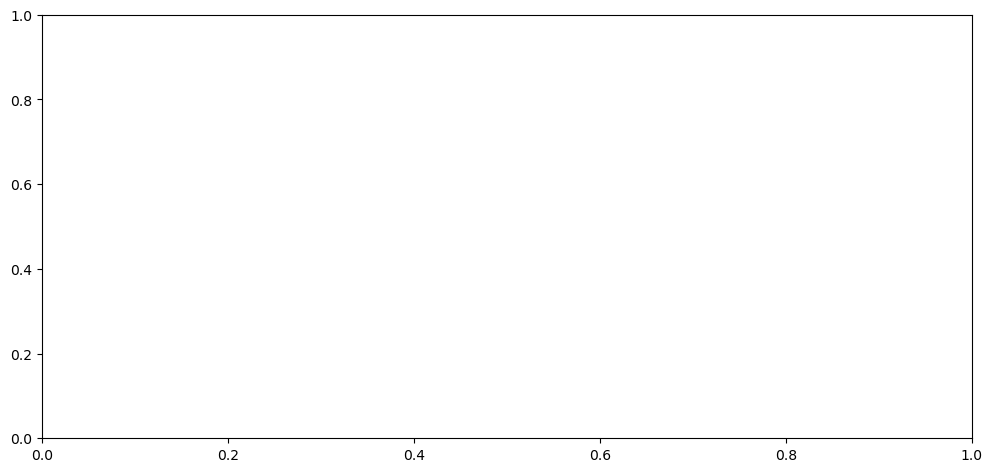

In [22]:
from sklearn.metrics import roc_auc_score

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}
plot_split_by_studies=True


model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]

### loop over ML models, train them & training results in a dictionary
idx_list=[0,2]
#for idx in idx_list:
#    data_param_key=[*parameters_for_analysis][idx]
    
for data_param_key in [*parameters_for_analysis][4:5]:
    
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X = load_and_modify_preprocessed_data(data_param_key)


    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats()

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]

        ## Create new prediction labels (or even multilabels) in the "RELAPSE" column based on the relapse day intervals defined in "bins" 
        if 'bins' in parameters_for_analysis[data_param_key].keys():
            pats_with_relapse_df = cut_relapse_days_to_interval_categories(pats_with_relapse_df,data_param_key)
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

    cv_res_df_list,cv_res_df_per_study_list=[],[]
    fig,ax=plt.subplots(1,1,figsize=(12,5.5))
    
    
    for period_end_day in period_end_days[:]:  
        
        period_num = period_end_days.index(period_end_day)

        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        print(len(pat_ids_))
        
        
        print(f'++++++++++++++++++ \n Period: {period_end_day} days \n+++++++++++++++++')

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        #print(f'Period: {period_end_day} days')
        
        if isinstance(period_end_day,int):

            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=period_end_day)].copy()

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()

        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames #\
                            #+ ae_cumul_colnames         
                            #+ arm_cumul_colnames \
                    
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
    

        for training_data_type in training_data_types[1:]:


            #ncols=train_params['num_cv_repeats']
            #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))

            scores,cv_num_list,model_name_list,scores_per_study_list,\
                            cv_num_per_study_list,model_name_per_study_list,study_list=[],[],[],[],[],[],[]

            for model_name in model_names[:]:
                print(model_name)

                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):

                    ## Based on the saved random state used at training, re-create the train-test data split
                    rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

                        ## If colunm name is in the temp_cols_to_keep list, don't drop it
                        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]


                    ## Drop rows, where the variables columns selcted for analysis contains NaNs
                    if period_end_day!='baseline':
                        cols_for_anal=X_subset.drop(columns=columns_to_drop_).columns
                        X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
                        
                        ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                        X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                        columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))

                    ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                    if period_end_day=='baseline':
                        X_subset_=X_subset.copy()

                    #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(X_subset_['USUBJID'].unique()),'STUDYID'],df_.loc[df_['USUBJID'].isin(X_subset_['USUBJID'].unique()),outcome_label]))

                    X_train,X_test,y_train,y_test,\
                                    X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day)
                    
                    
                    
                    X_train,X_test = scale_by_training_data(X_train, X_test)

                    model=cv_results[f'cv_rep_{cv_repeat_num}']['model']

                    ## Calculate label weights mapped to the test labels for RocCurveDisplay
                    if training_results['train_params']['weight_by_label_freq']==True:

                        label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                        label_weights=y_test[outcome_label].map(label_weights_dict).values

                    if training_results['train_params']['weight_by_label_freq']==False:
                        label_weights=None 

                    ## EXtract the output probabilities for each top n models and average them to get a final prediction probability
                    test_probs=[]
                    #for n in range(len(cv_results[f'cv_rep_{cv_repeat_num}']['model'].keys())):
                    for n in range(0,1):
                        model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][n]
                        test_probabilities = model.predict_proba(X_test)[:, 1]
                        test_probs.append(test_probabilities)
                        
                    final_test_probabilities =np.mean(np.array(test_probs),axis=0)

                    # Predict probabilities on the training and test data
                    #test_probabilities = model.predict_proba(X_test)[:, 1]
                    test_roc_auc=roc_auc_score(y_test, final_test_probabilities)

                    #cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                    scores.append(test_roc_auc)
                    cv_num_list.append(cv_repeat_num+1)
                    model_name_list.append(model_name)

                    ## IF THERE ARE MULTIPLE STUDIES IN THE DATA, CALCULATE THE ROC-AUC SCORES WITHIN THE STUDIES AS WELL
                    study_coln='STUDYID'
                    #study_coln='ARM'
                    
                    study_ids=X_subset[study_coln].unique()
                    #study_ids=['2EMRZ/2MR']
                    if len(study_ids)>1:
                        
                        for study_id in study_ids:
                            X_test_study_idx=X_subset.loc[(X_subset[study_coln]==study_id)&(X_subset['USUBJID'].isin(X_test_pat_ids)),'USUBJID'].tolist()
                            X_test_study=X_test.loc[X_test_study_idx,:]
                            #y_test_study=y_test.loc[y_test.index.get_level_values('STUDYID')==study_id]
                            y_test_study=y_test.loc[X_test_study_idx]

                            # Predict probabilities on the training and test data
                            try:
                                test_probabilities = model.predict_proba(X_test_study)[:, 1]
                                test_roc_auc=roc_auc_score(y_test_study, test_probabilities)
                            except ValueError:
                                print(f'No pats in cv-repeat_num {cv_repeat_num}')
                                continue

                            scores_per_study_list.append(test_roc_auc)
                            cv_num_per_study_list.append(cv_repeat_num+1)
                            model_name_per_study_list.append(model_name)
                            study_list.append(study_id)    
                                         
                
            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})
            cv_res_df['inclusion_period']=period_end_day
            cv_res_df_list.append(cv_res_df)

            if len(study_ids)>1:
                cv_res_per_study_df=pd.DataFrame.from_dict({'model_name':model_name_per_study_list,
                                                  'Num_of_CV_repeat':cv_num_per_study_list,
                                                  'ROC_AUC_score':scores_per_study_list,
                                                   study_coln:study_list})
                cv_res_per_study_df['inclusion_period']=period_end_day
                cv_res_df_per_study_list.append(cv_res_per_study_df)
                
                
    cv_res_acros_time_df=pd.concat(cv_res_df_list,axis=0)
    cv_res_acros_time_df = cv_res_acros_time_df.reset_index().drop(columns='index')

    ## SAVE TEST DATFRAME FOR LATER COMPARISON
    fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
    cv_res_acros_time_df.to_csv(fn)
    '''
    sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',
                y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=False)
    sns.stripplot(data=cv_res_acros_time_df, x='inclusion_period',hue='model_name', 
                  y='ROC_AUC_score', ax=ax, #color='black',
                  size=6, jitter=0.1, alpha=1, dodge=True,legend=False)
    sns.pointplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',
                  y='ROC_AUC_score',ax=ax,
                  errorbar='sd',alpha=0.5,dodge=True)

    
    ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
    ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
    
    ## Convert days to months for xticklabels
    xticklabels=[ '6 month' if day == 'all' 
                    else 'Baseline' if day == 'baseline' 
                    else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                    else None 
                    for day in period_end_days_for_plot]

    ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
    #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
    ax.set_ylim(0.3,1) 

    # Adjust legend: changing font size and handle size
    h, l = ax.get_legend_handles_labels()
    legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
    
    ax.legend(h,l,frameon=True,framealpha=0.5,
                        prop={'weight':'bold','size':legend_fontsize})

    


    ## PLot chance predicor's line at 0.5
    ax.axhline(y=0.5,color='black', linestyle='dashed')
    range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
    ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                        rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

    # increase tick width
    ax.tick_params(width=axis_lw)
    ax.tick_params(axis='y',labelsize=y_tick_size)

    

    if data_param_key in suptitle_dict.keys():
            study_names=suptitle_dict[data_param_key]
            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
            train_ds_type=suptitle_training_type_dict[training_data_type]
            suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: outcome at {prediction_time}"
            
    else:   
        suptitle=f"ROC-AUC of CV - {data_param_key} - {training_data_type}" 

    fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  
    ax.yaxis.grid(True) 
    '''
              
    ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
    if len(scores_per_study_list)>0 and plot_split_by_studies==True:

        cv_res_per_study_df=pd.concat(cv_res_df_per_study_list,axis=0)
        
        ## SAVE TEST DATFRAME FOR LATER COMPARISON
        #fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_test_ROC_AUC_across_time_per_study.csv' 
        fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_per_study..csv'
        cv_res_per_study_df.to_csv(fn)

        '''
        ncols=len(cv_res_per_study_df[study_coln].unique())
        nrows=1
        fig2=plt.figure(figsize=(ncols*10,nrows*5))

        for n,studyid in enumerate(np.sort(cv_res_per_study_df[study_coln].unique())):
            ax2=fig2.add_subplot(nrows,ncols,n+1)
            plot_df=cv_res_per_study_df[cv_res_per_study_df[study_coln]==studyid]

            # Calculate mean ROC_AUC_score for each model_name
            mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()

            sns.boxplot(data=plot_df,x='inclusion_period',#hue='model_name',
                        y='ROC_AUC_score',ax=ax2,boxprops={'fill': None},legend=False)
            sns.stripplot(data=plot_df, x='inclusion_period', #hue='model_name', 
                          y='ROC_AUC_score', ax=ax2, #color='black',
                         size=6, jitter=0.1, alpha=1, dodge=True)
            sns.pointplot(data=plot_df,x='inclusion_period',
                          #hue='model_name',
                          y='ROC_AUC_score',ax=ax2,
                          errorbar='sd',alpha=0.5,dodge=True,legend=False)
            

            ax2.set_title(studyid,fontweight='bold')
            ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
            ax2.set_xlabel(None)
            ax2.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size*0.5)
            #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
            ax2.set_ylim(0.3,1) 

            # increase tick width
            ax2.tick_params(width=axis_lw)
            ax2.yaxis.grid(True)
            
            ## PLot chance predicor's line at 0.5
            ax2.axhline(y=0.5,color='black', linestyle='dashed')
            range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
            ax2.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

            ## Remove legend title

            # Adjust legend: changing font size and handle size
            h, l = ax2.get_legend_handles_labels()
            legend = ax2.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)

            ax2.legend(h,l,frameon=True,framealpha=0.5,
                                prop={'weight':'bold','size':legend_fontsize})

            fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15) 
        '''

<Axes: >

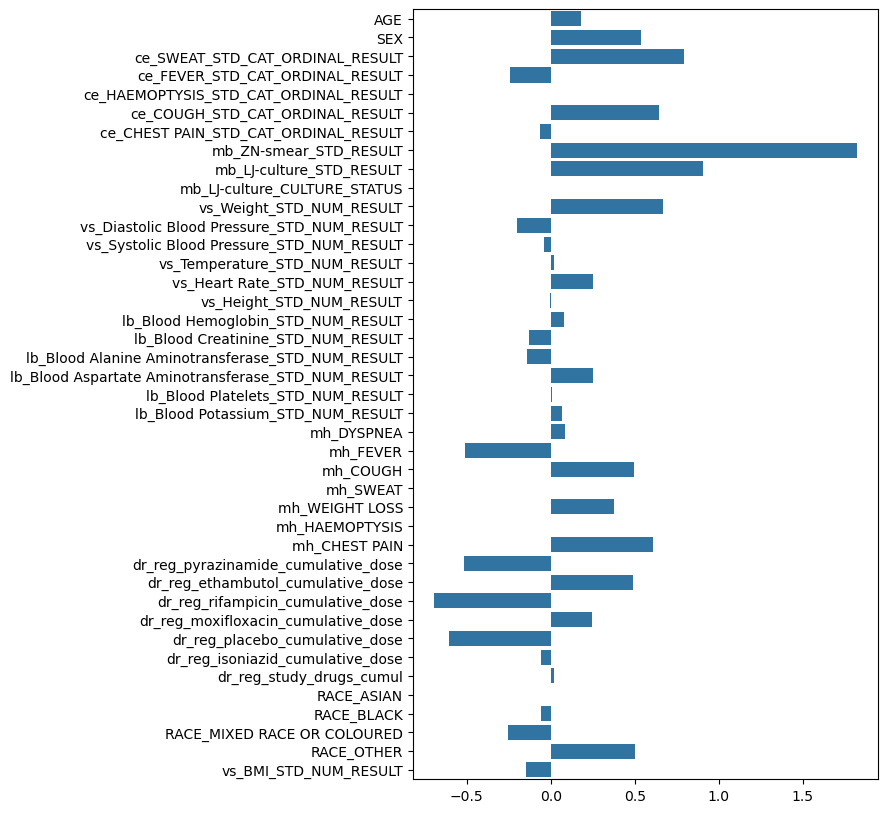

In [31]:
#sns.barplot()
fig=plt.figure(figsize=(6,10))
sns.barplot(pd.Series(data=model.coef_.flatten(),
              index=model.feature_names_in_),
           orient='h')

### Plot test set TOC-AUC values across time

tb21_22_2984_pats_22_vars_relapse_without_dr_reg


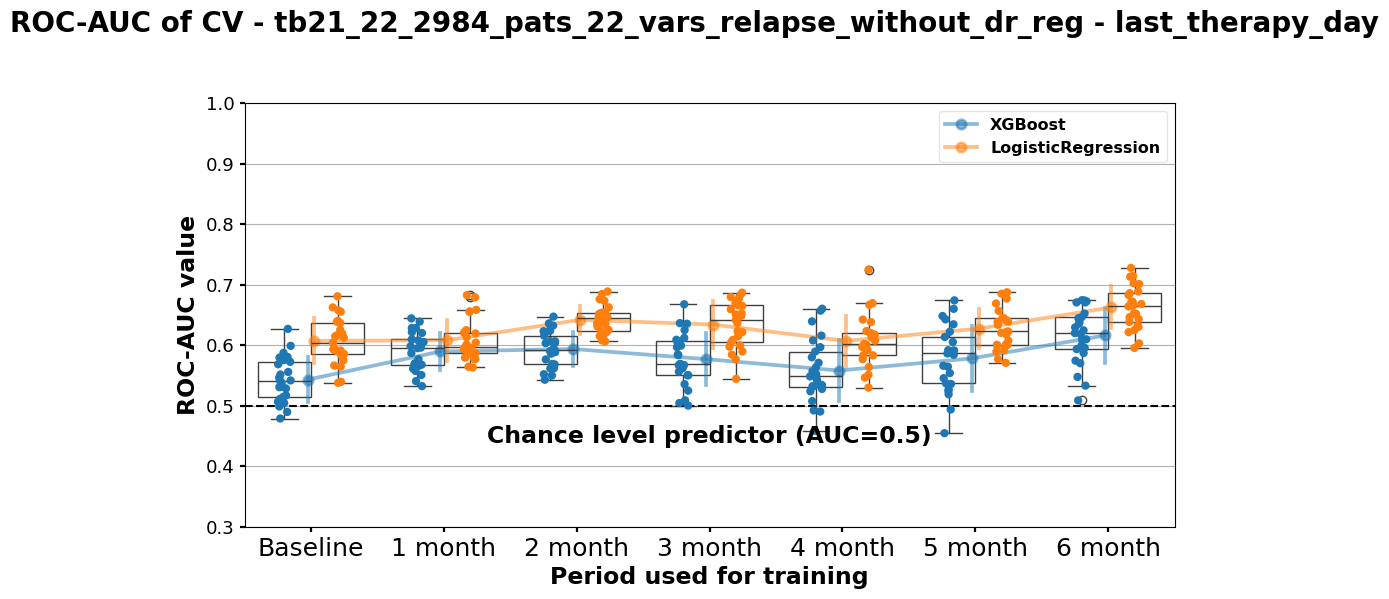

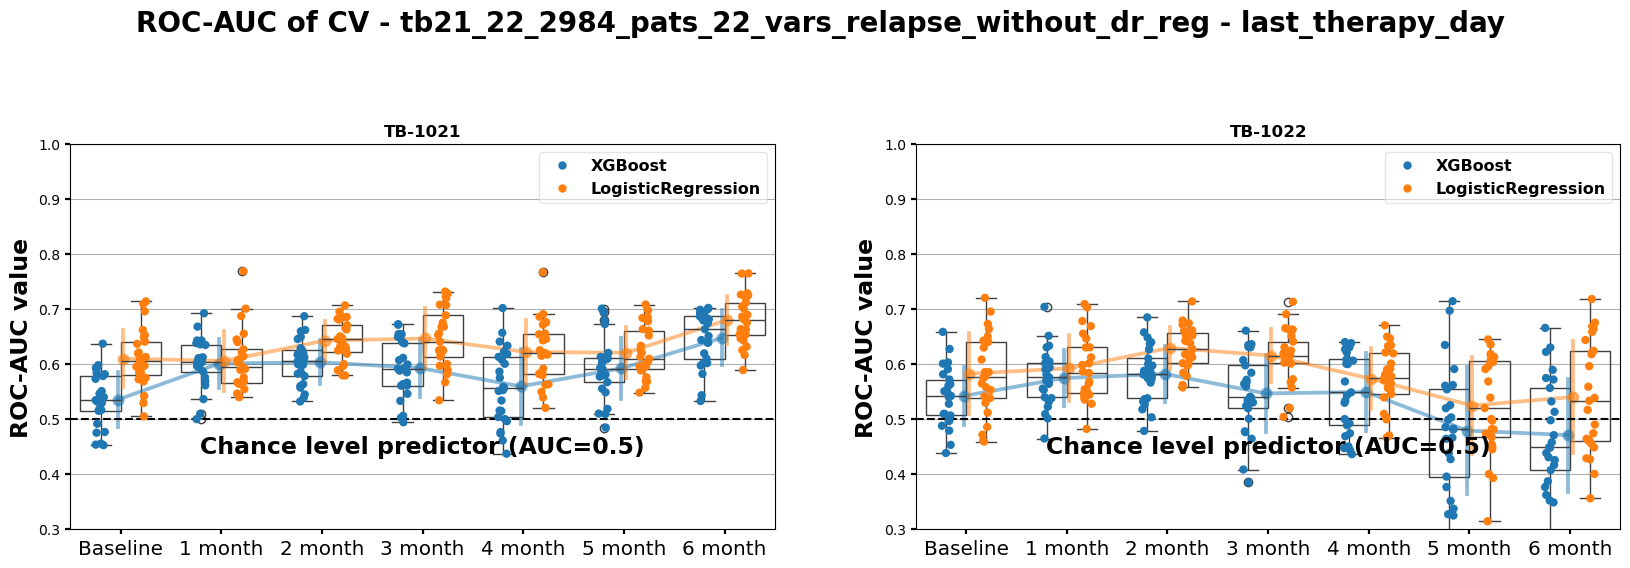

In [23]:
from sklearn.metrics import roc_auc_score

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
               'tb21_1405_pats_41_vars_relapse':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}
plot_split_by_studies=True


model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]

### loop over ML models, train them & training results in a dictionary
idx_list=[0,2]
#for idx in idx_list:
#    data_param_key=[*parameters_for_analysis][idx]
    
for data_param_key in [*parameters_for_analysis][4:5]:
    print(data_param_key)

    for training_data_type in training_data_types[1:]:

        fig,ax=plt.subplots(1,1,figsize=(12,5.5))
        
        ## LOAD TEST DATFRAME 
        fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
        cv_res_acros_time_df=pd.read_csv(fn,index_col=0)

        if cv_res_acros_time_df['model_name'].unique().shape[0]>1:
            hue='model_name'
        else:
            hue=None
        
        sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue=hue,
                    y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=False)
        sns.stripplot(data=cv_res_acros_time_df, x='inclusion_period',hue=hue,
                      y='ROC_AUC_score', ax=ax, #color='black',
                      size=6, jitter=0.1, alpha=1, dodge=True,legend=False)
        sns.pointplot(data=cv_res_acros_time_df,x='inclusion_period',hue=hue,
                      y='ROC_AUC_score',ax=ax,
                      errorbar='sd',alpha=0.5,dodge=True)
    
        
        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
        ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
        
        ## Convert days to months for xticklabels
        xticklabels=[ '6 month' if day == 'all' 
                        else 'Baseline' if day == 'baseline' 
                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                        else None 
                        for day in period_end_days_for_plot]
    
        ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
        ax.set_ylim(0.3,1) 
    
        # Adjust legend: changing font size and handle size
        h, l = ax.get_legend_handles_labels()
        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
        
        ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})
    
    
        ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
    
        # increase tick width
        ax.tick_params(width=axis_lw)
        ax.tick_params(axis='y',labelsize=y_tick_size)
    
        
    
        if data_param_key in suptitle_dict.keys():
                study_names=suptitle_dict[data_param_key]
                if 'relapse' not in data_param_key:
                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                    prediction_time = f'outcome at {prediction_time}'
                if 'relapse' in data_param_key:
                    prediction_time='relapse'
                    
                train_ds_type=suptitle_training_type_dict[training_data_type]
                suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: {prediction_time}"
                
        else:   
            suptitle=f"ROC-AUC of CV - {data_param_key} - {training_data_type}" 
    
        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  
        ax.yaxis.grid(True) 


        ## SAVE PLOTS
        data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_models/{data_param_key}'
        os.makedirs(data_dir_,exist_ok=True)
        fn=os.path.join(data_dir_,
                    f'{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_all_studies.png')
        fig.savefig(fn, bbox_inches='tight', dpi=300)


   
                  
        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
        #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_per_study..csv'
        fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_per_study..csv'
        study_coln='STUDYID'
        if os.path.isfile(fn)==True and plot_split_by_studies==True:
    
     
            cv_res_per_study_df=pd.read_csv(fn,index_col=0)
               
            ncols=len(cv_res_per_study_df[study_coln].unique())
            nrows=1
            fig2=plt.figure(figsize=(ncols*10,nrows*5))
    
            for n,studyid in enumerate(np.sort(cv_res_per_study_df[study_coln].unique())):
                ax2=fig2.add_subplot(nrows,ncols,n+1)
                plot_df=cv_res_per_study_df[cv_res_per_study_df[study_coln]==studyid]
    
                # Calculate mean ROC_AUC_score for each model_name
                mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()
    
                sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',
                            y='ROC_AUC_score',ax=ax2,boxprops={'fill': None},legend=False)
                sns.stripplot(data=plot_df, x='inclusion_period', hue='model_name', 
                              y='ROC_AUC_score', ax=ax2, #color='black',
                             size=6, jitter=0.1, alpha=1, dodge=True)
                sns.pointplot(data=plot_df,x='inclusion_period',
                              hue='model_name',
                              y='ROC_AUC_score',ax=ax2,
                              errorbar='sd',alpha=0.5,dodge=True,legend=False)
                
    
                ax2.set_title(studyid,fontweight='bold')
                ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                ax2.set_xlabel(None)
                ax2.set_xticklabels(xticklabels,fontsize=x_tick_size*0.8)
                #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                ax2.set_ylim(0.3,1) 
    
                # increase tick width
                ax2.tick_params(width=axis_lw)
                ax2.yaxis.grid(True)
                
                ## PLot chance predicor's line at 0.5
                ax2.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax2.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
    
                ## Remove legend title
    
                # Adjust legend: changing font size and handle size
                h, l = ax2.get_legend_handles_labels()
                legend = ax2.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
    
                ax2.legend(h,l,frameon=True,framealpha=0.5,
                                    prop={'weight':'bold','size':legend_fontsize})
    
                fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15) 

                ## SAVE PLOTS
                data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_models/{data_param_key}'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_per_study.png')
                fig2.savefig(fn, bbox_inches='tight', dpi=300)


## ROC-AUC curve of test set

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


for data_param_key in [*parameters_for_analysis][:1]:
    
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        


    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    for period_end_day in period_end_days[:]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
    

        for training_data_type in training_data_types[:]:


            ncols=train_params['num_cv_repeats']
            fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))

            for model_name in model_names[:]:

                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):

                    ## Based on the saved random state used at training, re-create the train-test data split
                    rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X.columns[X.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

                    X_train,X_test,y_train,y_test,\
                        X_train_pat_ids,X_test_pat_ids = create_std_training_testing_data(X_subset,y,pat_ids,
                                                                                      train_params['test_size_ratio'],
                                                                                      rand_state,training_data_type,
                                                                                      columns_to_drop_)

                    #X_train,X_test = scale_by_training_data(X_train, X_test)

                    #X_test_pat_ids=cv_results[f'cv_rep_{cv_repeat_num}']['X_test_pat_ids']
                    #X_test=X.loc[X['USUBJID'].isin(X_test_pat_ids),:]
                    #y_test=y.loc[X_test['USUBJID'].tolist()]

                    #X_test=X_test.drop(columns=columns_to_drop)

                    model=cv_results[f'cv_rep_{cv_repeat_num}']['model']

                    ## Calculate label weights mapped to the test labels for RocCurveDisplay
                    if training_results['train_params']['weight_by_label_freq']==True:

                        label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                        label_weights=y_test[outcome_label].map(label_weights_dict).values

                    if training_results['train_params']['weight_by_label_freq']==False:
                        label_weights=None   

                    if len([*cv_results])==1:
                        ax=axes
                    else:    
                        ax=axes[cv_repeat_num]


                    rfc_disp=RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=model_name,
                                                                            sample_weight=label_weights,alpha=0.8)  

                    ax.set_ylabel('True Positive Rate',fontsize=y_label_size,fontweight='bold')
                    ax.set_xlabel('False Positive Rate',fontsize=y_label_size,fontweight='bold')

                    ax.tick_params(axis='y', labelsize=y_label_size*0.8)
                    ax.tick_params(axis='x', labelsize=y_label_size*0.8)

                    ax.set_title(' - '.join(['CV-split',str(cv_repeat_num+1)]),fontsize=subtitle_size,fontweight='bold')

                    ## Plot diagonal chance level predictor curve + customize legend
                    ax.plot([0,1], [0,1],color='black', linestyle='dashed')
                    ax.text(0.5,0.55,'Chance level predictor (AUC=0.5)',fontsize=y_label_size*0.8,fontweight='bold',
                            rotation=45,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                    h, l = ax.get_legend_handles_labels()
                    ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})

                    ## Change linewidth of axes
                    for axis in ['top','bottom','left','right']:
                        ax.spines[axis].set_linewidth(axis_lw)

                    # increase tick width
                    ax.tick_params(width=axis_lw)

                    suptitle=f"ROC curve of test data\n {data_param_key} - {training_data_type}" 
                    suptitle=f"ROC curve of test data - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 

                    fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=0.87)  
                    ax.grid(True)        


## ROC-AUC curve of test set - split by study

In [ ]:

for data_param_key in [*parameters_for_analysis][:1]:
    

    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    for period_end_day in period_end_days[-1:]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()

        for training_data_type in training_data_types[1:]:


            ncols=train_params['num_cv_repeats']
            nrows=len(X['STUDYID'].unique())
            fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*7,nrows*7.5),constrained_layout=False)
            #fig=plt.figure(figsize=(ncols*6,nrows*4))

            for model_name in model_names[:]:

                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):

                    ## Based on the saved random state used at training, re-create the train-test data split
                    rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                    if len(columns_to_drop)>0:
                        columns_to_drop=columns_to_drop + X.columns[X.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()

                    X_train,X_test,y_train,y_test,\
                        X_train_pat_ids,X_test_pat_ids = create_std_training_testing_data(X_subset,y,pat_ids,
                                                                                      train_params['test_size_ratio'],
                                                                                      rand_state,training_data_type,
                                                                                       columns_to_drop=[])
                    #fig2,ax2=plt.subplots() 
                    #X_subset.loc[X_subset['USUBJID'].isin(X_test_pat_ids),'DAY'].hist(bins=50,ax=ax2)

                    #X_test_pat_ids=cv_results[f'cv_rep_{cv_repeat_num}']['X_test_pat_ids']
                    #X_test=X.loc[X['USUBJID'].isin(X_test_pat_ids),:]
                    #y_test=y.loc[X_test['USUBJID'].tolist()]

                    #X_test=X_test.drop(columns=columns_to_drop)

                    model=cv_results[f'cv_rep_{cv_repeat_num}']['model']


                    for l,studyid in enumerate(X_subset['STUDYID'].unique()):                                  

                        if len([*cv_results])==1:
                            ax=axes[l]
                        else:    
                            ax=axes[l,cv_repeat_num]

                        #ax=fig.add_subplot(nrows,ncols,l+1)
                        X_study_mask=X_test.loc[X_test['STUDYID']==studyid,:]
                        y_study_mask=y_test.loc[X_study_mask['USUBJID'].unique().tolist()]
                        X_study_mask=X_study_mask.drop(columns=columns_to_drop)

                        ## Calculate label weights mapped to the test labels for RocCurveDisplay
                        if training_results['train_params']['weight_by_label_freq']==True:

                            label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                            label_weights=y_study_mask[outcome_label].map(label_weights_dict).values

                        if training_results['train_params']['weight_by_label_freq']==False:
                            label_weights=None   


                        
                        rfc_disp=RocCurveDisplay.from_estimator(model, X_study_mask, y_study_mask, ax=ax, name=model_name,
                                                                                sample_weight=label_weights,alpha=0.8)  

                        ax.set_ylabel('True Positive Rate',fontsize=y_label_size,fontweight='bold')
                        ax.set_xlabel('False Positive Rate',fontsize=y_label_size,fontweight='bold')

                        ax.tick_params(axis='y', labelsize=y_label_size*0.8)
                        ax.tick_params(axis='x', labelsize=y_label_size*0.8)

                        ax.set_title(' - '.join([studyid,'CV-split',str(cv_repeat_num+1)]),fontsize=subtitle_size,fontweight='bold')

                        ## Plot diagonal chance level predictor curve + customize legend
                        ax.plot([0,1], [0,1],color='black', linestyle='dashed')
                        ax.text(0.5,0.55,'Chance level predictor (AUC=0.5)',fontsize=y_label_size*0.8,fontweight='bold',
                                rotation=45,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                        h, l = ax.get_legend_handles_labels()
                        ax.legend(h,l,frameon=True,framealpha=0.5,
                                prop={'weight':'bold','size':legend_fontsize})

                        ## Change linewidth of axes
                        for axis in ['top','bottom','left','right']:
                            ax.spines[axis].set_linewidth(axis_lw)

                        # increase tick width
                        ax.tick_params(width=axis_lw)

                        plt.subplots_adjust(wspace=0.25)

                        #suptitle=f"ROC curve of test data\n {data_param_key} - {training_data_type}" 
                        suptitle=f"ROC curve of test data - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 

                        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=0.95)  
                        ax.grid(True)        

                    ## Print distribution of labels per study
                    df=y_test.reset_index()#
                    df['STUDYID']=df['USUBJID'].str.split('/',expand=True)[0].values
                    #print(pd.crosstab(df['STUDYID'],df[outcome_label]))

#plt.tight_layout()


# COMPARISON OF BASELINE MODELS

## Functions

In [ ]:

def calc_paired_t_test_between_exp_setups(plot_df):

    # Get unique values from the 'setup' column
    unique_setups = plot_df['setup'].unique()
    
    # Generate all pairwise combinations
    setup_combinations = list(itertools.combinations(unique_setups, 2))
    setup_combinations#[0]
    
    paired_t_res_dict={}
    
    ## Loop over models
    for model_incl_per, model_incl_per_df in plot_df.groupby(['model_name','inclusion_period']):
        
        ttest_res_df=pd.DataFrame(columns=plot_df['setup'].unique(),
                                  index=plot_df['setup'].unique())
    
        for setup_combination in setup_combinations:
            
            #if setup_combination[0].startswith('baseline'):
    
            model_incl_per_df_1 = model_incl_per_df[(model_incl_per_df['setup']==setup_combination[0])]
            model_incl_per_df_2 = model_incl_per_df[(model_incl_per_df['setup']==setup_combination[1])]
    
            t_stat,pval = ttest_rel(model_incl_per_df_1['ROC_AUC_score'],model_incl_per_df_2['ROC_AUC_score'])
    
            ttest_res_df.loc[setup_combination[0],setup_combination[1]]=pval
    
        ## Copy upper triangle to lower triangle to get a dataframe where it is easier to extract the exp. setup comparisons later
        X=ttest_res_df.fillna(0).values
        X = X + X.T - np.diag(np.diag(X))
        ttest_res_df=pd.DataFrame(data=X,
                                  columns=plot_df['setup'].unique(),
                                  index=plot_df['setup'].unique())
        ttest_res_df=ttest_res_df.replace(0,np.nan)

        ## Add to dict
        paired_t_res_dict[model_incl_per]=ttest_res_df

    return paired_t_res_dict

#####===========================
def extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2):
    from statsmodels.stats.multitest import multipletests

    pvalues_df = ttest_res_df.loc[comparison_1,comparison_2]#.dropna()
    
    # 1. Extract non-NaN p-values
    non_nan_pvalues = pvalues_df.stack().values
    #non_nan_pvalues = pvalues_df.values.flatten()
    
    # 2. FDR correction
    _, corrected_pvalues, _, _ = multipletests(non_nan_pvalues, alpha=0.05, method='fdr_bh')
    
    # 3. Replace corrected p-values back into a symmetric DataFrame
    corrected_pvalues_df = pvalues_df.copy()
    corrected_pvalues_df.loc[:, :] = np.nan  # Reset with NaNs
    
    # Use mask to update non-NaN positions with corrected p-values
    pval_flat=pvalues_df.values.flatten()
    pval_flat[~np.isnan(pval_flat)]=corrected_pvalues
    
    mask = ~pvalues_df.isna()
    corrected_pvalues_df[mask] = pval_flat.reshape(corrected_pvalues_df.shape)

    return corrected_pvalues_df

#####==========
def annotate_fdr(ax, comparison_pairs, fdr_values, y_offset=0.02):
    """
    Annotate FDR-corrected p-values above bars with brackets.

    Args:
        ax: Matplotlib axis.
        comparison_pairs: List of (x1, x2) pairs indicating bar comparisons.
        fdr_values: List of corresponding FDR values for the comparisons.
        y_offset: Vertical offset for annotations.
    """
    for i, ((x1, x2), fdr) in enumerate(zip(comparison_pairs, fdr_values)):
        if fdr < 0.05:  # Only annotate significant comparisons
            # Get the y position for the top of the bars
            y1 = ax.patches[x1].get_height()
            y2 = ax.patches[x2].get_height()
            y_max = max(y1, y2) + y_offset
            
            # Draw bracket
            ax.annotate('', xy=(x1, y_max), xytext=(x2, y_max),
                        arrowprops=dict(arrowstyle='-', lw=1.5))
            
            # Add FDR value above bracket
            ax.text((x1 + x2) / 2, y_max + y_offset, f"p={fdr:.3f}", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

#####=========
def add_fdr_vals_to_bars(ax,plot_df,paired_t_res_dict,comparison_1,comparison_2):
    ## Create dict containing the x,y positions of all bars
    bars_x_pos = [p.get_x() + p.get_width() / 2 for p in ax.patches]
    bars_y_pos = [p.get_height() for p in ax.patches]
    err_bars_y_pos=([max(line.get_xydata()[:,1]) for line in ax.lines])

    incl_periods=plot_df['inclusion_period'].unique()  
    mod_name = ax.get_title()
    
    d={}
    for n,incl_per in enumerate(incl_periods):
        bars_x_pos_per = np.array(bars_x_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        bars_y_pos_per = np.array(bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        err_bars_y_pos_per = np.array(err_bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,bars_y_pos_per))))
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,err_bars_y_pos_per))))

        ttest_res_df=paired_t_res_dict[(mod_name,incl_per)]
        corrected_pvalues_df = extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

    
        y_offset=0.05

        m=0
        for comp1 in comparison_1:
            for comp2 in comparison_2:
                if comp1!=comp2:
                    fdr=corrected_pvalues_df.loc[comp1,comp2]
                    x_pos=(d[incl_per][comp1][0] + d[incl_per][comp2][0])/2
                    
                    x_pos1=d[incl_per][comp1][0]
                    x_pos2=d[incl_per][comp2][0]
                    y_pos1=d[incl_per][comp1][1]
                    y_pos2=d[incl_per][comp2][1]

                    x_mean=(x_pos1+x_pos2)/2
                    y_mean=np.max(err_bars_y_pos_per)+0.00 +y_offset*m

                    bx = [x_pos1, x_pos1, x_pos2 ,x_pos2]
                    by = [y_mean+ 0.01, y_mean + 0.04, y_mean + 0.04,y_mean + 0.01]
                    ax.plot(bx, by, 'k-', lw=1.5,clip_on=False,)
                    
                    # Add FDR value above bracket
                    color='black' if fdr>0.05 else 'r'
                    ax.text(x_mean, y_mean+0.05, f"{fdr:.3f}", 
                            ha='center', va='bottom', fontsize=10, color=color,fontweight='bold')
                    m=m+1

def replace_substring_in_list(replacements,list):
   
    replaced_list= [h if not isinstance(h, str)  else
                        reduce(lambda s, kv: s.replace(*kv), replacements.items(), h)
                        for h in list]
    return replaced_list
    

## Across studies - Plot ROC-AUC comparisons

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

baseline_training_data_types=['all_days_in_period','last_therapy_day']

period_end_days_for_plot=period_end_days[:]


#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['all_days_in_period','last_therapy_day']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

plot_split_by_studies=True


data_inclusion_types=['baseline_last_day','all_days_in_period','baseline_vars','all_days'][:]

comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
comparison_2=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:]
#comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][1:]
hue_order=['baseline_last_therapy_day', 'baseline_all_days_in_period','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]



plot_type='bar'
plot_type='point'

for data_param_key in [*parameters_for_analysis][-2:-1]:

    for plot_type in ['bar','point']:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')
            
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            'embed_baseline_vars': 'Baseline vars - all visits in period',
            'embed_baseline_last_day': 'Baseline vars - last visit in period',
            'baseline_last_therapy_day': 'Baseline vars - last visit in period',
            'baseline_all_days_in_period': 'Baseline vars - last visits concatenated',
            'embed_all_days':'All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
     
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['6 month' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization
        #fig_width = 18
        fig_height = 4

        
        # Create a FacetGrid for splitting by 'model_name'
        g = sns.FacetGrid(plot_df, col='model_name', col_wrap=1, height=fig_height, aspect=1.6,sharex=False,sharey=False)
        
        # Map barplot onto the FacetGrid
        if plot_type=='bar':
            g.map_dataframe(sns.barplot, x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup', 
                            errorbar='sd',
                            palette='Set2',
                            hue_order=hue_order,
                            alpha=0.6)

        
        if plot_type=='point':
            g.map_dataframe(sns.pointplot, x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup', 
                            errorbar='sd',
                            palette='Set2',
                            hue_order=hue_order,
                            alpha=0.6)
                                 
        
        # Add legends
        g.add_legend(title='Setup',loc='center left')
        # Adjust legend position
        g._legend.set_bbox_to_anchor((0.95, 0.5))  # Move the legend closer (adjust x and y)
        g._legend.set_frame_on(False)              # Optional: Add a box around the legend
        g._legend.set_title("Setup", prop={'size': 16, 'weight': 'bold'})  # Customize title

        # Customize legend labels font size
        for text in g._legend.texts:  # Loop through legend labels
            text.set_fontsize(14)     # Set label font size
        
        # Customize legend handle size
        for handle in g._legend.legendHandles:
            try:
                handle.set_markersize(12) 
            except AttributeError:
                handle.set(height=12)

        
        # Customize titles
        g.set_titles("{col_name}",size=12, weight='bold')

        # Set axis labels
        g.set_axis_labels("Inclusion Period", "ROC AUC Score",fontsize=12,fontweight='bold')

        # Customize tick sizes
        for ax in g.axes.flat:  # Loop through each subplot
            ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
            ax.tick_params(axis='y', labelsize=14)  # Customize y tick size
            ax.set_ylim(0.4,1.05)

             ## PLot chance predicor's line at 0.5
            ax.axhline(y=0.5,color='black', linestyle='dashed')
            range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
            ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

            #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
            #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
            ax.grid(alpha=0.4)

            if plot_type=='bar':
                add_fdr_vals_to_bars(ax,plot_df,paired_t_res_dict,comparison_1,comparison_2)
            
            
        # Adjust layout for better appearance
        # Adjust the overall figure size
        #g.fig.set_size_inches(fig_width, fig_height)  # Set custom figure size
        g.fig.suptitle(f"Test set ROC-AUC comparison\n{data_param_key}\n{parameters_for_analysis[data_param_key]['result_cat'].replace('_',' ').capitalize()}",
                       y=1,fontweight='bold',fontsize=15)\

        plt.tight_layout()
        
        plt.show()

                        

## Per study - Plot ROC-AUC comparisons

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

baseline_training_data_types=['all_days_in_period','last_therapy_day']

period_end_days_for_plot=period_end_days[:]


#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['all_days_in_period','last_therapy_day']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

plot_split_by_studies=True
shap_plot_types=['bar','dot'] #'dot'



data_inclusion_types=['baseline_last_day','all_days_in_period','baseline_vars','all_days'][:]

comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
comparison_2=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:]
#comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][1:]
hue_order=['baseline_last_therapy_day', 'baseline_all_days_in_period','LLM_embed_baseline_vars','LLM_embed_all_days'][:2]



plot_type='bar'
plot_type='point'

for data_param_key in [*parameters_for_analysis][-1:]:

    for plot_type in ['bar','point']:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[:]:
            print(bl_training_data_type)
            
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')
            
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            'embed_baseline_vars': 'Baseline vars - all visits in period',
            'embed_baseline_last_day': 'Baseline vars - last visit in period',
            'baseline_last_therapy_day': 'Baseline vars - last visit in period',
            'baseline_all_days_in_period': 'Baseline vars - last visits concatenated',
            'embed_all_days':'All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
     
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['6 month' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization
        #fig_width = 18
        fig_height = 4

        for study in plot_df['STUDYID'].unique()[:]:
            
            plot_df_study=plot_df[plot_df['STUDYID']==study]

        
            # Create a FacetGrid for splitting by 'model_name'
            g = sns.FacetGrid(plot_df_study, col='model_name', col_wrap=1, height=fig_height, aspect=1.6,sharex=False,sharey=False)
            
            # Map barplot onto the FacetGrid
            if plot_type=='bar':
                g.map_dataframe(sns.barplot, x='inclusion_period',
                                y='ROC_AUC_score', 
                                hue='setup', 
                                errorbar='sd',
                                palette='Set2',
                                hue_order=hue_order,
                                alpha=0.6)
    
            
            if plot_type=='point':
                g.map_dataframe(sns.pointplot, x='inclusion_period',
                                y='ROC_AUC_score', 
                                hue='setup', 
                                errorbar='sd',
                                palette='Set2',
                                hue_order=hue_order,
                                alpha=0.6)
                                     
            
            # Add legends
            g.add_legend(title='Setup',loc='center left')
            # Adjust legend position
            g._legend.set_bbox_to_anchor((0.95, 0.5))  # Move the legend closer (adjust x and y)
            g._legend.set_frame_on(False)              # Optional: Add a box around the legend
            g._legend.set_title("Setup", prop={'size': 16, 'weight': 'bold'})  # Customize title
    
            # Customize legend labels font size
            for text in g._legend.texts:  # Loop through legend labels
                text.set_fontsize(14)     # Set label font size
            
            # Customize legend handle size
            for handle in g._legend.legendHandles:
                try:
                    handle.set_markersize(12) 
                except AttributeError:
                    handle.set(height=12)
    
            
            # Customize titles
            g.set_titles("{col_name}",size=12, weight='bold')
    
            # Set axis labels
            g.set_axis_labels("Inclusion Period", "ROC AUC Score",fontsize=12,fontweight='bold')
    
            # Customize tick sizes
            for ax in g.axes.flat:  # Loop through each subplot
                ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
                ax.tick_params(axis='y', labelsize=14)  # Customize y tick size
                ax.set_ylim(0.4,1.05)
    
                 ## PLot chance predicor's line at 0.5
                ax.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
    
                #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
                ax.grid(alpha=0.4)
    
                if plot_type=='bar':
                    add_fdr_vals_to_bars(ax,plot_df,paired_t_res_dict,comparison_1,comparison_2)
                
                
            # Adjust layout for better appearance
            # Adjust the overall figure size
            #g.fig.set_size_inches(fig_width, fig_height)  # Set custom figure size
            g.fig.suptitle(f"Test set ROC-AUC comparison\n{parameters_for_analysis[data_param_key]['result_cat'].replace('_',' ').capitalize()}\n{study}",
                           y=1,fontweight='bold',fontsize=15)\
    
            plt.tight_layout()
            
            plt.show()

                        

# FEATURE IMPORTANCE: SHAP-VALUES

## Calculate SHAP-values

### Functions

In [25]:

### CALCULATE SHAP-SCORES (FEATURE IMPORTANCE) ####
def calculate_shap_values(X_train,X_test,model,model_name):
    import shap
    
    #importances_dict[training_method][train_ds_type+'_train_data'][model_type_name]={}

    if model_name in ['RandomForest','GradientBoost','XGBoost']:
        explainer=shap.TreeExplainer(model,data=X_train)
        shap_values=explainer(X_test)

    elif model_name in ['LogisticRegression','Lasso','Ridge','ElasticNet']:
        #explainer=shap.LinearExplainer(model,data=X_train,masker=shap.maskers.Impute(data=X_train))
        #shap_values=explainer(X_test)

        #masker = shap.maskers.Independent(X_train)
        masker = shap.maskers.Impute(X_train)
        explainer = shap.Explainer(model, masker=masker, algorithm="linear")
        shap_values = explainer(X_test)

    elif model_name in ['DenseNetwork']:
        explainer=shap.DeepExplainer(model,data=torch.tensor(X_train.values,dtype=torch.float32))
        shap_values=explainer.shap_values(torch.tensor(X_test.values,dtype=torch.float32))
        
    elif model_name in ['SVR','KNN']:
        explainer=shap.KernelExplainer(model.predict, data=shap.kmeans(X_train, 1),
                                        masker=shap.maskers.Independent(X_train, max_samples=100))
        shap_values=explainer.shap_values(X_test)                                                       

    return shap_values

### Run calculation of SHAP-values

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

model_names=['XGBoost','LogisticRegression']

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][4:5]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X = load_and_modify_preprocessed_data(data_param_key)


    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats()

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

    
    for period_end_day in period_end_days[:]:                
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        print(len(pat_ids_))



        print(f'++++++++++++++++++ \n Period: {period_end_day} days \n +++++++++++++++++')
        if isinstance(period_end_day,int):

            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=period_end_day)].copy()

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       
        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames #\
                            #+ ae_cumul_colnames
                            #+ arm_cumul_colnames \
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
        
        for training_data_type in training_data_types[1:]:
            print(f'Running training with {training_data_type} model')


            for model_name in model_names[1:]:
                
                
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']

                
                for cv_repeat_num in range(len([*cv_results])):
                    print(f'Calculating SHAP-values for model {model_name},CV-repeat number:{cv_repeat_num}')

                    ## Based on the saved random state used at training, re-create the train-test data split
                    rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()\
                                        #+ ['dr_reg_study_drugs_cumul']
                        ## If colunm name is in the temp_cols_to_keep list, don't drop it
                        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

                    ## Drop rows, where the variables columns selcted for analysis contains NaNs
                    if period_end_day!='baseline':
                        cols_for_anal=X_subset.drop(columns=columns_to_drop_).columns
                        X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)

                        ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                        X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                        columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))

                    ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                    if period_end_day=='baseline':
                        X_subset_=X_subset.copy()

                    X_train,X_test,y_train,y_test,\
                                    X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day)

                    

                    X_train,X_test = scale_by_training_data(X_train, X_test)

                    if isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'], dict):
                        model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][0]

                    ## Calculate SHAP-values * prediction probabilities for both training and testing data
                    for X_data,y_data,prefix in zip([X_train,X_test],[y_train,y_test],['train','test']):
                        #print(prefix)
                        
                        shap_values=calculate_shap_values(X_train,X_data,model,model_name)
                        cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shap_values']=shap_values

                        #print(shap_values.values.shape)

                        pred_prob = model.predict_proba(X_data)[:, 1]
                        cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob']=pred_prob
                        cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']=y_data.values
                        
                    
       

                training_results['cv_results']=cv_results
        
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'wb') as handle:
                    pickle.dump(training_results, handle)
        


 tb21_22_2984_pats_22_vars_relapse_without_dr_reg 

set(idx)&set(de_.index) {'TB-1022/42083', 'TB-1022/43330', 'TB-1021/2003995'}
RELAPSE     0    1
STUDYID           
TB-1021  1061  140
TB-1022  1085  116
USUBJID                
TB-1021/1006663  160352    320.0
TB-1021/1007305  60674     440.0
TB-1021/1015079  451602    382.0
TB-1021/1020617  528727    261.0
TB-1021/1028897  168718    393.0
                           ...  
TB-1021/2892159  440084    256.0
TB-1021/2931146  43577     365.0
TB-1021/2940160  35676     522.0
TB-1021/2964983  404760    490.0
TB-1021/3026076  235794    299.0
Name: DAY, Length: 89, dtype: float64
2399
++++++++++++++++++ 
 Period: baseline days 
 +++++++++++++++++
Running training with last_therapy_day model
Calculating SHAP-values for model LogisticRegression,CV-repeat number:0


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating SHAP-values for model LogisticRegression,CV-repeat number:1


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating SHAP-values for model LogisticRegression,CV-repeat number:12


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating SHAP-values for model LogisticRegression,CV-repeat number:13


### Concatenate & save raw SHAP-values & raw input data into dataframes

In [ ]:

#training_data_types=['full','last_therapy_day']
training_data_types=['all_days_in_period','last_therapy_day']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]

shap_plot_types=['bar','dot'] #'dot'


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][4:5]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X = load_and_modify_preprocessed_data(data_param_key)


    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats()

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)
    
    for period_end_day in period_end_days[:]:                
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        print(len(pat_ids_))

        print(f'++++++++++++++++++ \n Period: {period_end_day} days \n +++++++++++++++++')
        if isinstance(period_end_day,int):

            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=period_end_day)].copy()

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames# \
                            #+ ae_cumul_colnames
                           #+ arm_cumul_colnames \
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')

            ncols=train_params['num_cv_repeats']

            for model_name in model_names_for_plotting[1:]:
                print(f'Loading SHAP-values for model {model_name}')
                
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']
                ncols=len([*cv_results])
                
                for plot_type in shap_plot_types[1:]:
                    #fig,axes=plt.subplots(1,ncols)
                    
                    shap_abs_df_list,shap_df_list,X_data_list=[],[],[]
                    
                    for cv_repeat_num in range(len([*cv_results])):
                        print('cv_repeat_num',cv_repeat_num)
                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()\
                                             #+ ['dr_reg_study_drugs_cumul']

                            ## If colunm name is in the temp_cols_to_keep list, don't drop it
                            columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

                        ## Drop rows, where the variables columns selcted for analysis contains NaNs
                        if period_end_day!='baseline':
                            cols_for_anal=X_subset.drop(columns=columns_to_drop_).columns
                            X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)

                             ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                            X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                            columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))
    
                        ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                        if period_end_day=='baseline':
                            X_subset_=X_subset.copy()


                        X_train,X_test,y_train,y_test,\
                                    X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day)

                        #X_train,X_test = scale_by_training_data(X_train, X_test)
                        
                        num_of_feats=len(X_test.columns)
                        plot_size=[ncols*7,num_of_feats*0.25]

                        #train_test_shap_list=[]
                        for X_data,prefix in zip([X_train,X_test],['train','test']):

                            arm_pat_dict=X.loc[X['USUBJID'].isin(X_data.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                            
                            ## Shorten feature names
                            feature_names=X_data.columns.tolist()
                            
                            if training_data_type!='all_days_in_period':
                            
                                feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                                feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                                feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]
                                feature_names_split=[x.replace('_STD_RESULT','') for x in feature_names_split]
                            
                            if training_data_type=='all_days_in_period':    
                                feature_names_split=feature_names

                            
                            X_data.columns=feature_names_split

                                
                            ## Extract shap-values
                            shap_values = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shap_values']

                            rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names_split)
                            rf_resultX['data_type']=prefix

                            rf_resultX[f'pred_prob'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob']
                            rf_resultX[f'true_labels'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']

                            ## Add ARM and USUBID information to the shap value dataframe
                            rf_resultX['USUBJID']=X_data.index.tolist()
                            rf_resultX['cv_repeat_num']=cv_repeat_num
                            rf_resultX['ARM']=rf_resultX['USUBJID'].map(arm_pat_dict)
                            #train_test_shap_list.append(rf_resultX)
                            
                            ## Add dataframe of CV-repeat to list for later concatenation
                            shap_df_list.append(rf_resultX)

                            ## Min-max normlaize X_test + add cv_repeat_num to X_test
                            #X_data_norm=(X_data-X_data.min())/(X_data.max()-X_data.min())
                            X_data_norm=X_data.copy()
                            X_data_norm['cv_repeat_num']=cv_repeat_num
                            X_data_norm['ARM']=X_data_norm.index.map(arm_pat_dict)
                            X_data_norm['data_type']=prefix
                            X_data_list.append(X_data_norm)
                        
           
                ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT                
                merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                merged_x_test_across_cv=pd.concat(X_data_list,axis=0) 

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                merged_shap_across_cv.to_csv(fn)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv.to_csv(fn)
     

## Plot SHAP-values

### Scatterplot -  raw SHAP values for all CV-reps for each Arm

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import shap 
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable



figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMoxTB',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMoxTB',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


training_data_types=['full','last_therapy_day']
pats_with_relapse_df=extract_21_22_relapse_pats()

model_names_for_plotting=['XGBoost','LogisticRegression'][:]



### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][4:5]:
    print('===========\n',data_param_key,'\n')
    ## Define X and y dataframes for training

    outcome_label=data_param_key.split('vars_')[-1].upper()
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    l,k=[],[]
    
    for period_end_day in period_end_days[:]:      
        print(f'{period_end_day}')

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')


            for model_name in model_names_for_plotting[:]:
                print(f'Loading SHAP-values for model {model_name}')
                

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv=pd.read_csv(fn,index_col=0)
               
                
                for data_type in ['train','test'][1:]:

                    merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    
                    ## Put categorical columns into index, keeping only numeric columns as values
                    merged_shap_across_cv_numeric=merged_shap_across_cv_dtype.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|period|cv_repeat_num|true_labels|pred_prob|\bARM\b')]).reset_index().drop(columns='level_2')
                    merged_x_test_across_cv_numeric=merged_x_test_across_cv_dtype.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|period|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')
    
                    ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                    # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                    low_thr=0.00
                    num_cols=merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains(r'USUBJID|period|cv_repeat_num|\bARM\b',regex=True)].abs().mean()
                    cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                    merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                    merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=cols_to_drop)

                    num_cols=merged_x_test_across_cv_numeric.columns[~merged_x_test_across_cv_numeric.columns.isin(['cv_repeat_num', 'ARM', 'USUBJID'])].tolist()
                    
                    merged_x_test_across_cv_numeric[num_cols]=((merged_x_test_across_cv_numeric[num_cols]-\
                                                               merged_x_test_across_cv_numeric[num_cols].min())/(merged_x_test_across_cv_numeric[num_cols].max()-merged_x_test_across_cv_numeric[num_cols].min())).values
    
                    
                    ncols=3
                    nrows=int(np.ceil(merged_x_test_across_cv_numeric['ARM'].unique().shape[0]/ncols))
                    fig=plt.figure(figsize=(8*ncols,14*nrows))
                    
                    for n,arm in enumerate(merged_shap_across_cv_numeric['ARM'].unique()):
                        
                        study=merged_x_test_across_cv_numeric[merged_x_test_across_cv_numeric['ARM']==arm]['USUBJID'].map(study_pat_dict).unique()[0]
                        
                        
                        ax=fig.add_subplot(nrows,ncols,n+1)
                        shap_df=merged_shap_across_cv_numeric.loc[merged_shap_across_cv_numeric['ARM']==arm,
                                                                  ~merged_shap_across_cv_numeric.columns.str.contains(r'true_label|pred_prob')]

                        
                        shap_df.columns = shap_df.columns.str.replace(r'_RESULT','')
                        shap_df.columns = shap_df.columns.str.replace(r'mb_','')
                        x_test_df=merged_x_test_across_cv_numeric[merged_x_test_across_cv_numeric['ARM']==arm].drop(columns=['USUBJID'])

                        ## Min-max normalise within ARM
                        # Select only numeric columns
                        numeric_cols = x_test_df.select_dtypes(include='number').columns
                        #x_test_df[numeric_cols] = (x_test_df[numeric_cols] - x_test_df[numeric_cols].min()) / \
                        #                        (x_test_df[numeric_cols].max() - x_test_df[numeric_cols].min())
                        
                        
                        shap_plot_df=pd.melt(shap_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                        x_test_plot_df=pd.melt(x_test_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
    
                        norm = Normalize(vmin=x_test_plot_df['value'].min(), vmax=x_test_plot_df['value'].max())
                        sm = ScalarMappable(norm=norm, cmap='viridis')
                        pal=sns.color_palette("viridis", as_cmap=True)

                    
                        
                        sns.barplot(data=shap_plot_df,y='variable',x='value',errorbar='se',fill=False,ax=ax)
                        stripplot = sns.stripplot(data=shap_plot_df,y='variable',x='value',ax=ax,palette=pal,
                                                  hue=x_test_plot_df['value'].values,s=2.5,jitter=0.2)
                        
                        # Remove legend created by stripplot
                        ax.legend_.remove()
                    
                        # Add the colorbar
                        # Create a divider for the current axis
                        divider = make_axes_locatable(ax)
                        cax = divider.append_axes("right", size="10%", pad=0.002)
                        cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
                        #cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.002)
                        cbar.set_label('Feature Value',fontsize=18,labelpad=-35, fontweight='bold')
                        
                        # Customize colorbar to show 'High' and 'Low'
                        cbar_low_tick=max(0,x_test_plot_df['value'].quantile(0.02))
                        cbar_high_tick=min(1,x_test_plot_df['value'].quantile(0.98))
                        cbar.set_ticks([cbar_low_tick,cbar_high_tick])
                        cbar.set_ticklabels(['Low', 'High'],fontsize=15,fontweight='bold')
                        

                        ylabel='FAVOURABLE | UNFAVOURABLE'
                        if 'relapse' in data_param_key:
                            ylabel='NO RELAPSE | RELAPSE'
                        ax.set_xlabel(f"SHAP-value - Impact on prediction\n<== {ylabel} ==>",fontsize=17,fontweight='bold')
                        ax.tick_params(axis='x', labelsize=16)

                        if nrows==1:
                            ytick_labelsize=len(shap_df.columns)*0.25
                        if nrows>1:
                            ytick_labelsize=len(shap_df.columns)*0.5
                        ax.tick_params(axis='y', labelsize=ytick_labelsize)
                        
                        ax.set_ylabel(None)
                        ax.set_title(f"{study_dict[study]} - Arm: {arm.replace(' regimen','')}",fontsize=20,fontweight='bold',y=1.02)
                        plt.tight_layout()
    
    
                        xlim_min=1.05 * np.nanquantile(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values,0.0001)
                        xlim_max=1.05 * np.nanquantile(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values,0.9999)
    
                        #xlim_min=1.05 * np.min(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values)
                        #xlim_max=1.05 * np.max(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values)
                        ax.set_xlim(xlim_min,xlim_max)
                        #ax.set_xlim(-4.5,5.5)
                    
                    if data_param_key in suptitle_study_dict.keys():
                        study_names=suptitle_study_dict[data_param_key]
                        prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                        train_ds_type=suptitle_training_type_dict[training_data_type]
                        if isinstance(period_end_day,int):
                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                        if period_end_day=='all':
                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                        if period_end_day=='baseline':
                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: outcome at {str(prediction_time)}"
                    else:
                        suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"
                    fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.09) 


                    ### SAVE PLOTS
                    data_dir_=f'../data/plots/raw_SHAP_values_all_datapoints/{data_param_key}'
                    os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                   f'{training_data_type}_{period_end_day}_{model_name}_{data_type}_set_SHAP_vals_across_arms.png')
                    fig.savefig(fn, bbox_inches='tight', dpi=300)
                    
                    
                

In [30]:
#max(0,x_test_plot_df['value'].quantile(0.02))
cbar_low_tick=max(0,x_test_plot_df['value'].quantile(0.02))
cbar_high_tick=min(1,x_test_plot_df['value'].quantile(0.98))
cbar_low_tick
cbar_high_tick

1

In [43]:
len(shap_df.columns)*0.4

14.4

### Clustermap -  raw SHAP values for all CV-reps for each Arm

 tb21_22_2984_pats_22_vars_relapse 

baseline
last_therapy_day model
Loading SHAP-values for model LogisticRegression


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


31
last_therapy_day model
Loading SHAP-values for model LogisticRegression


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


62
last_therapy_day model
Loading SHAP-values for model LogisticRegression


...

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


160
last_therapy_day model
Loading SHAP-values for model LogisticRegression


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


all
last_therapy_day model
Loading SHAP-values for model LogisticRegression


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


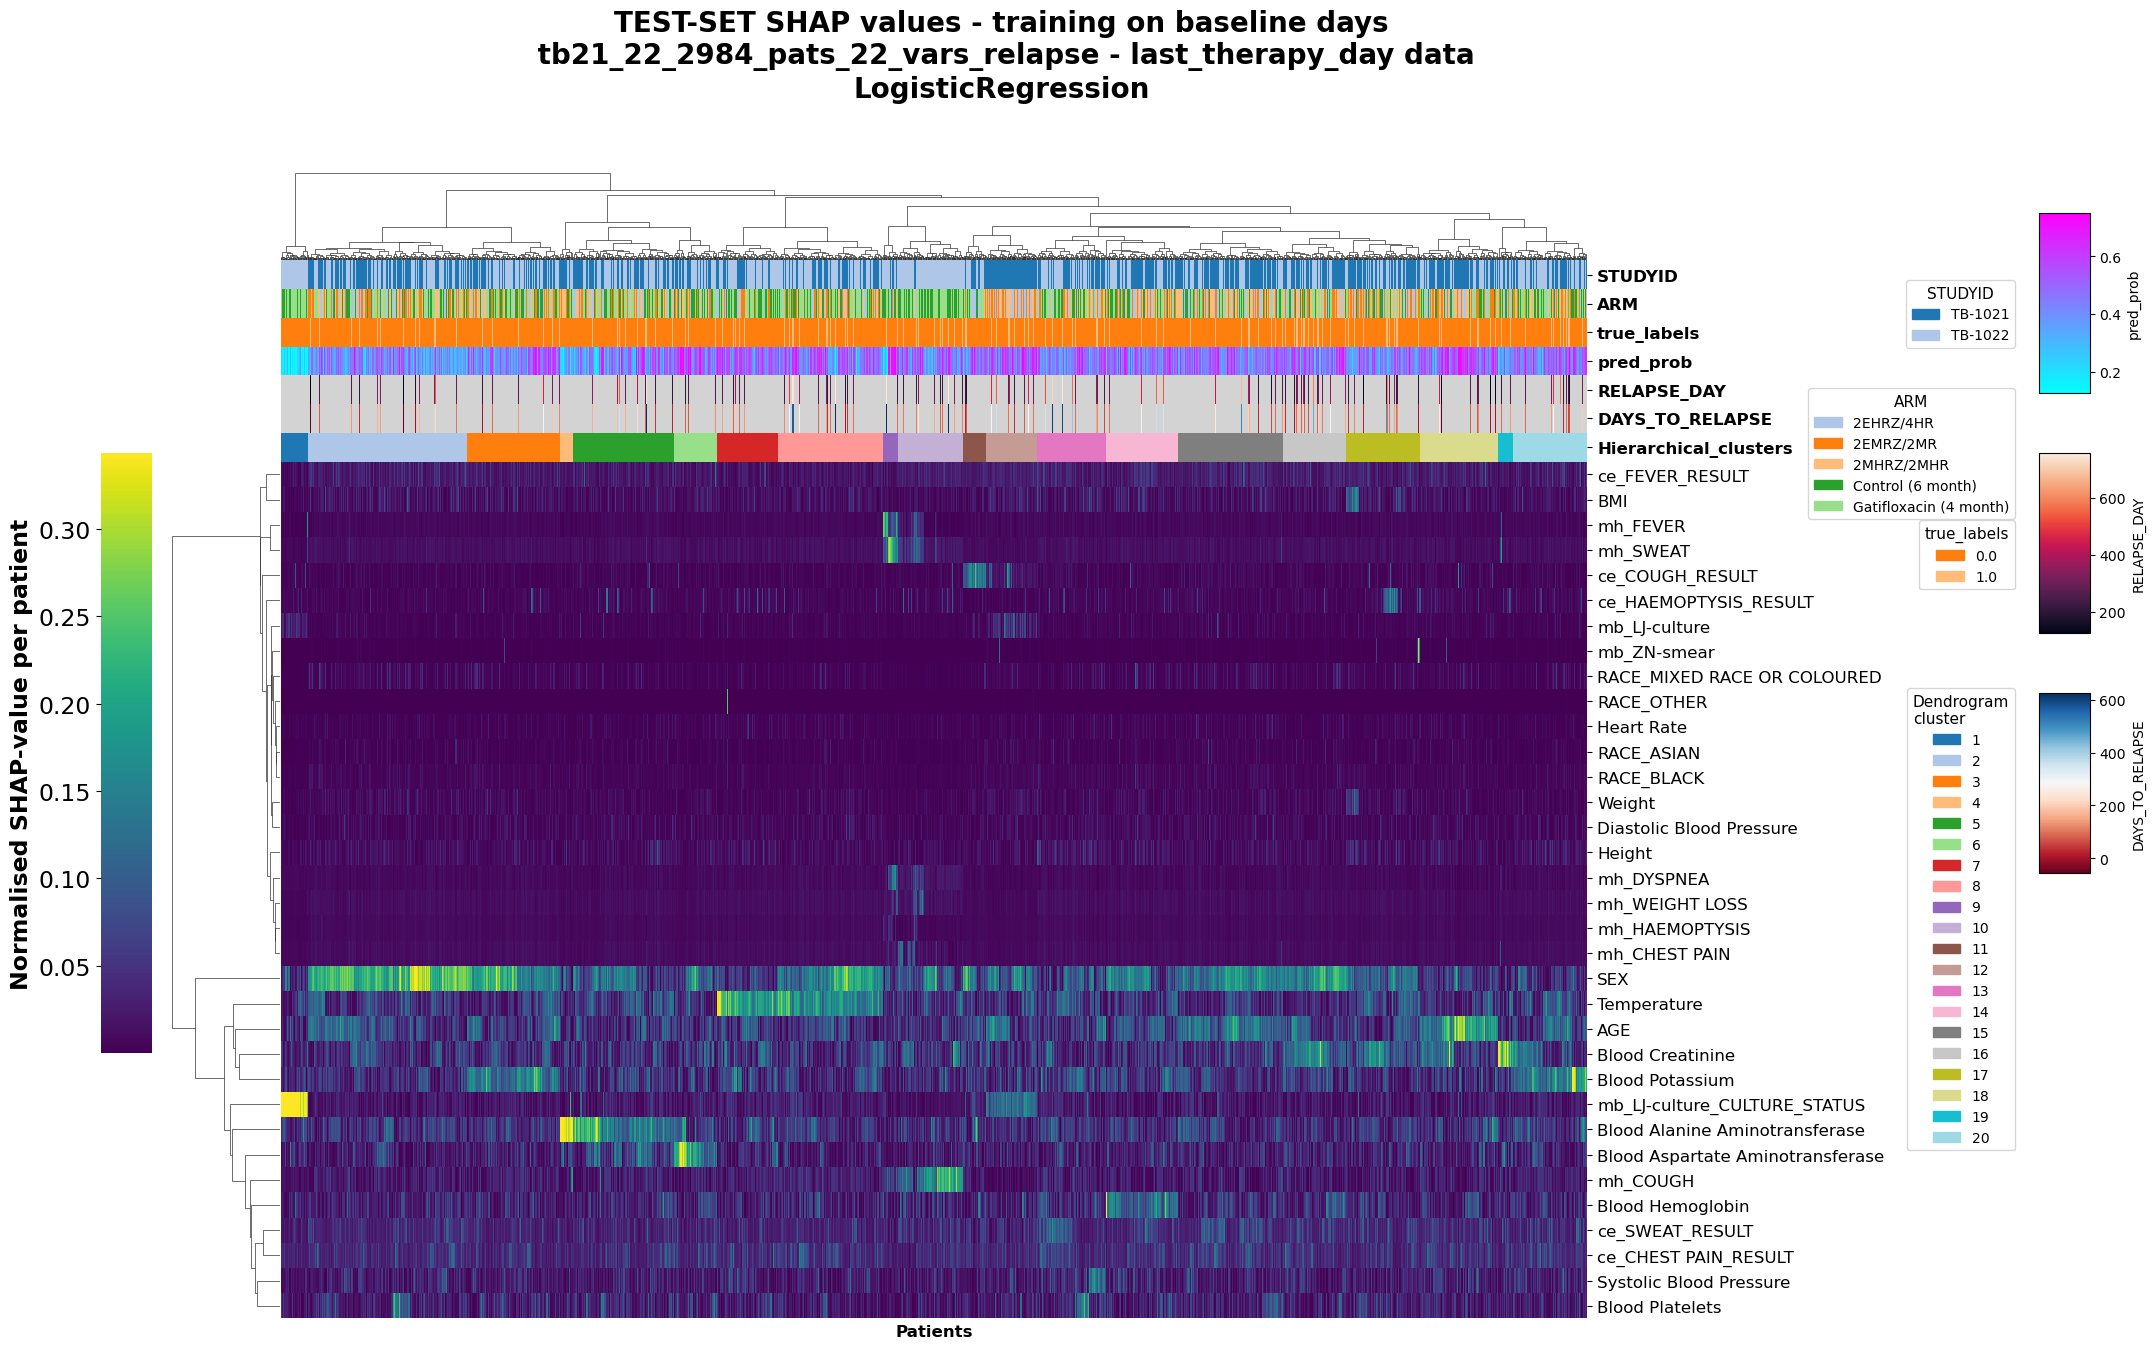

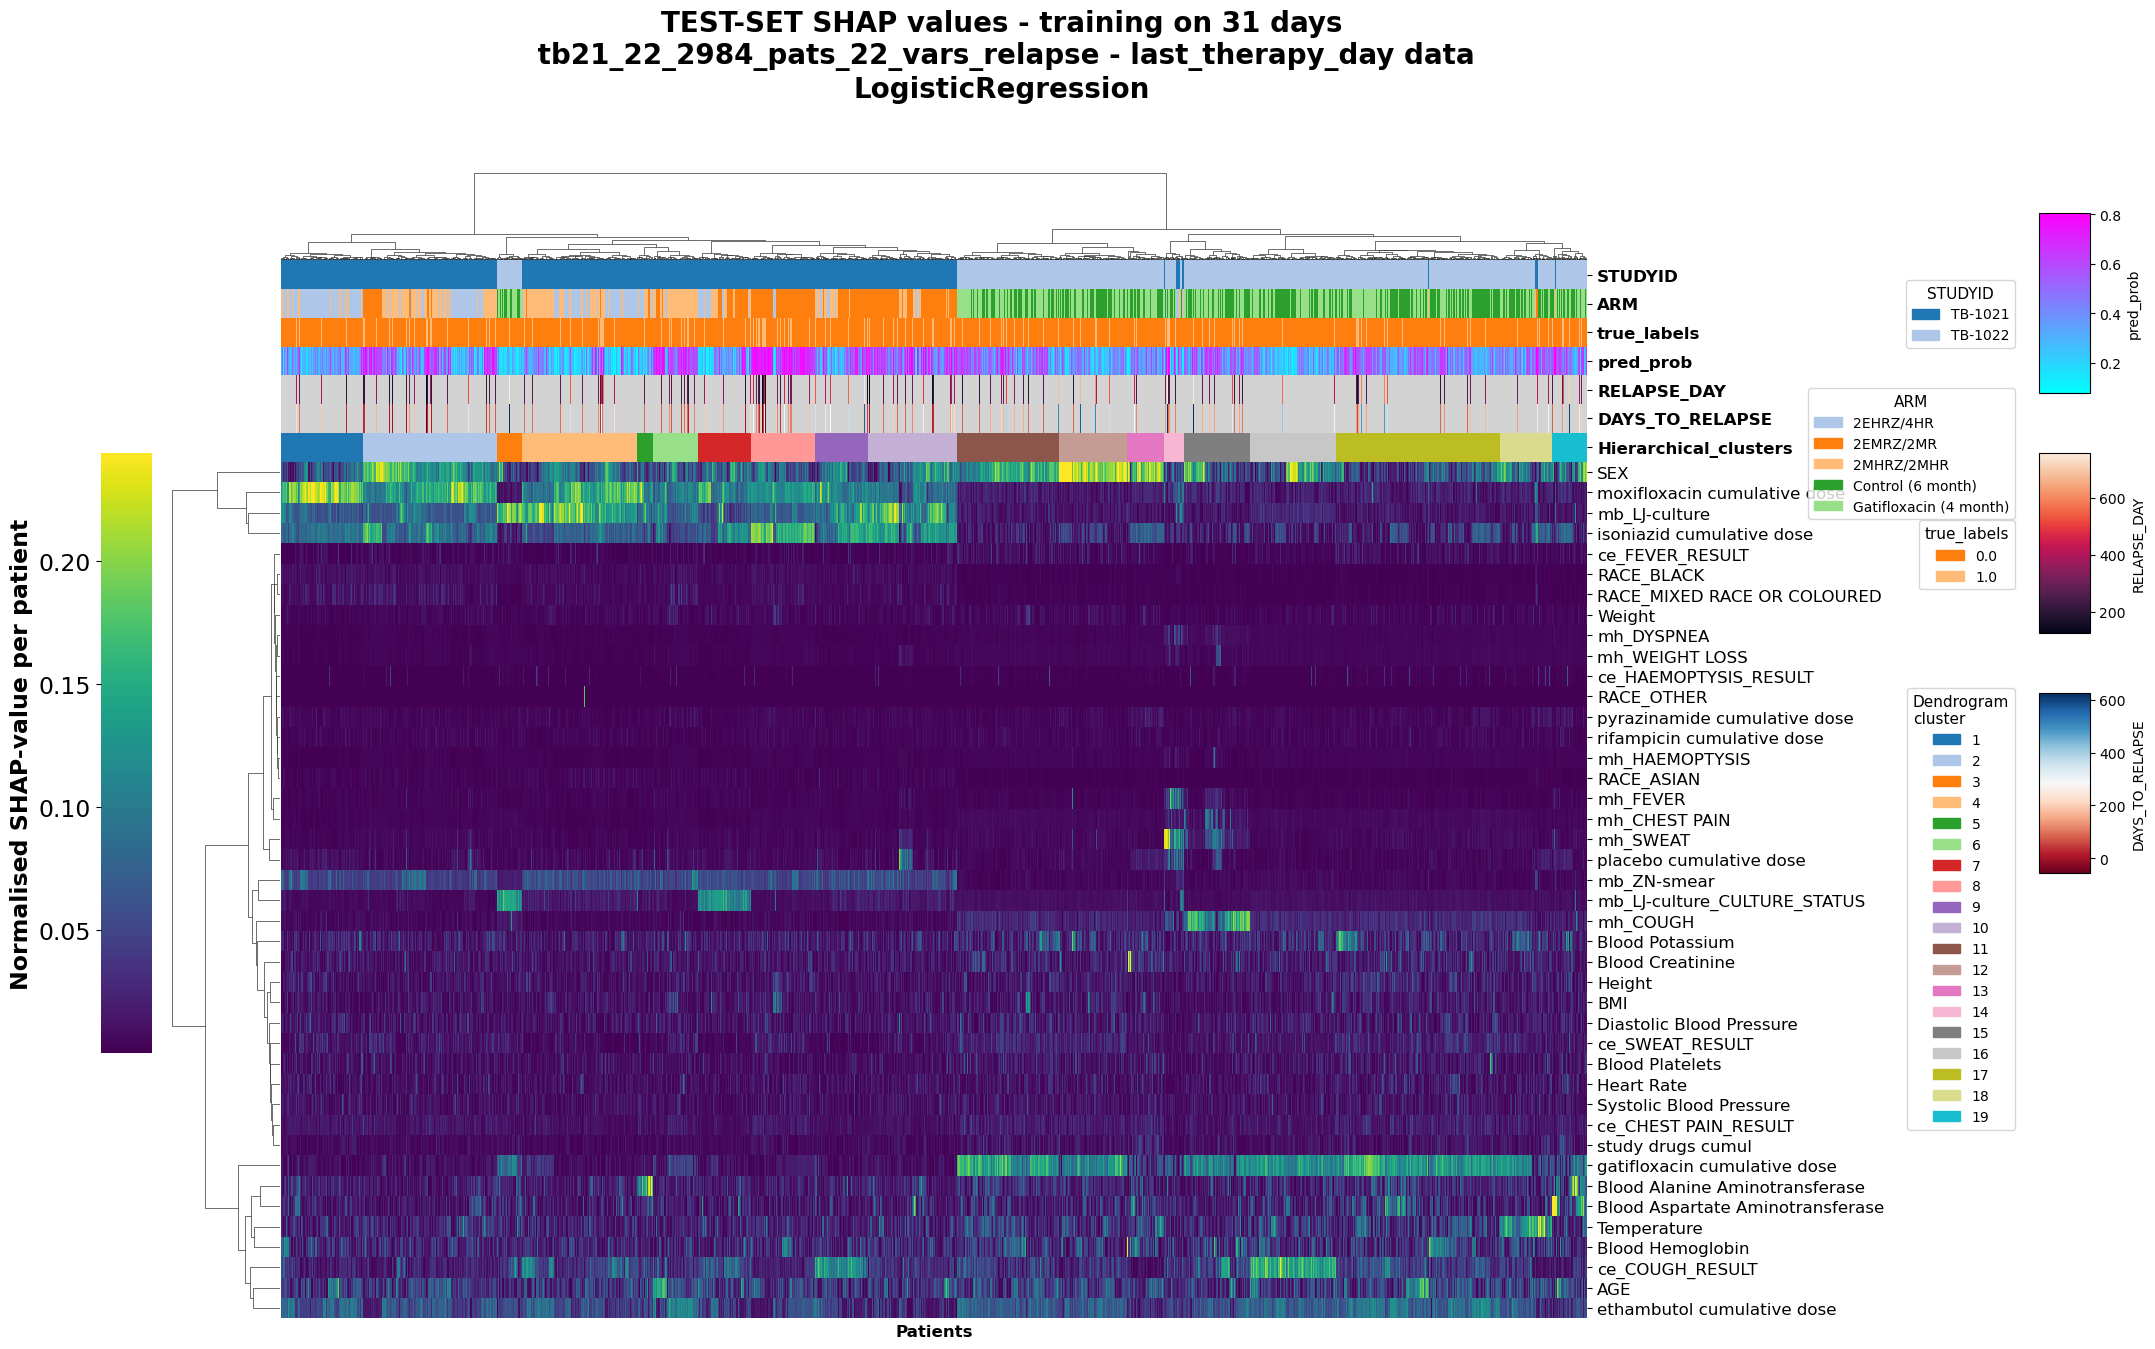

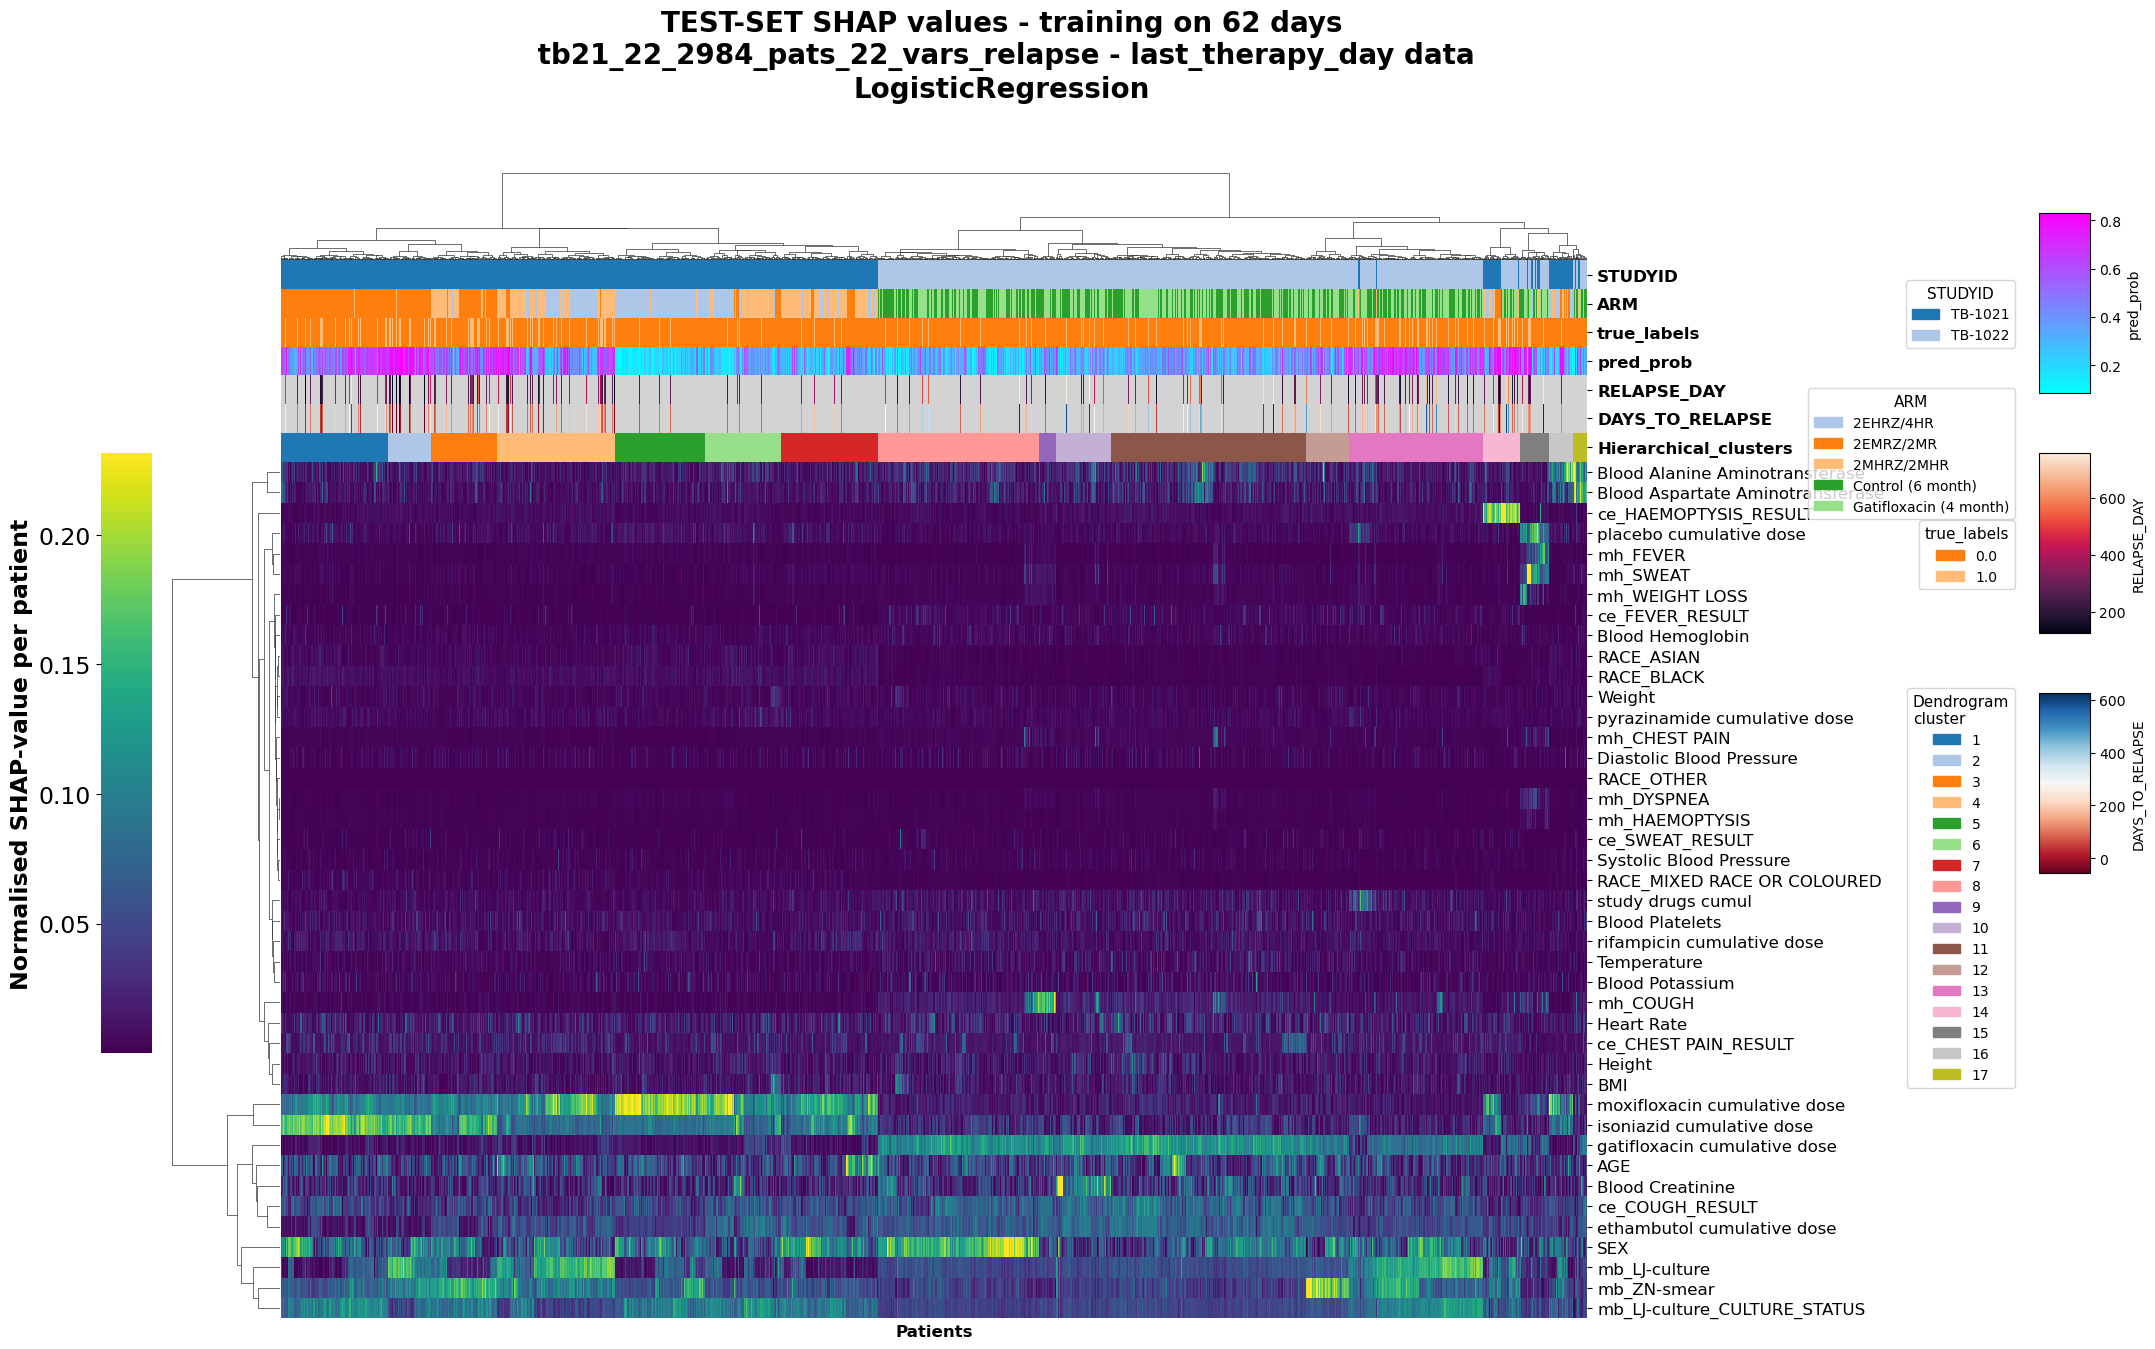

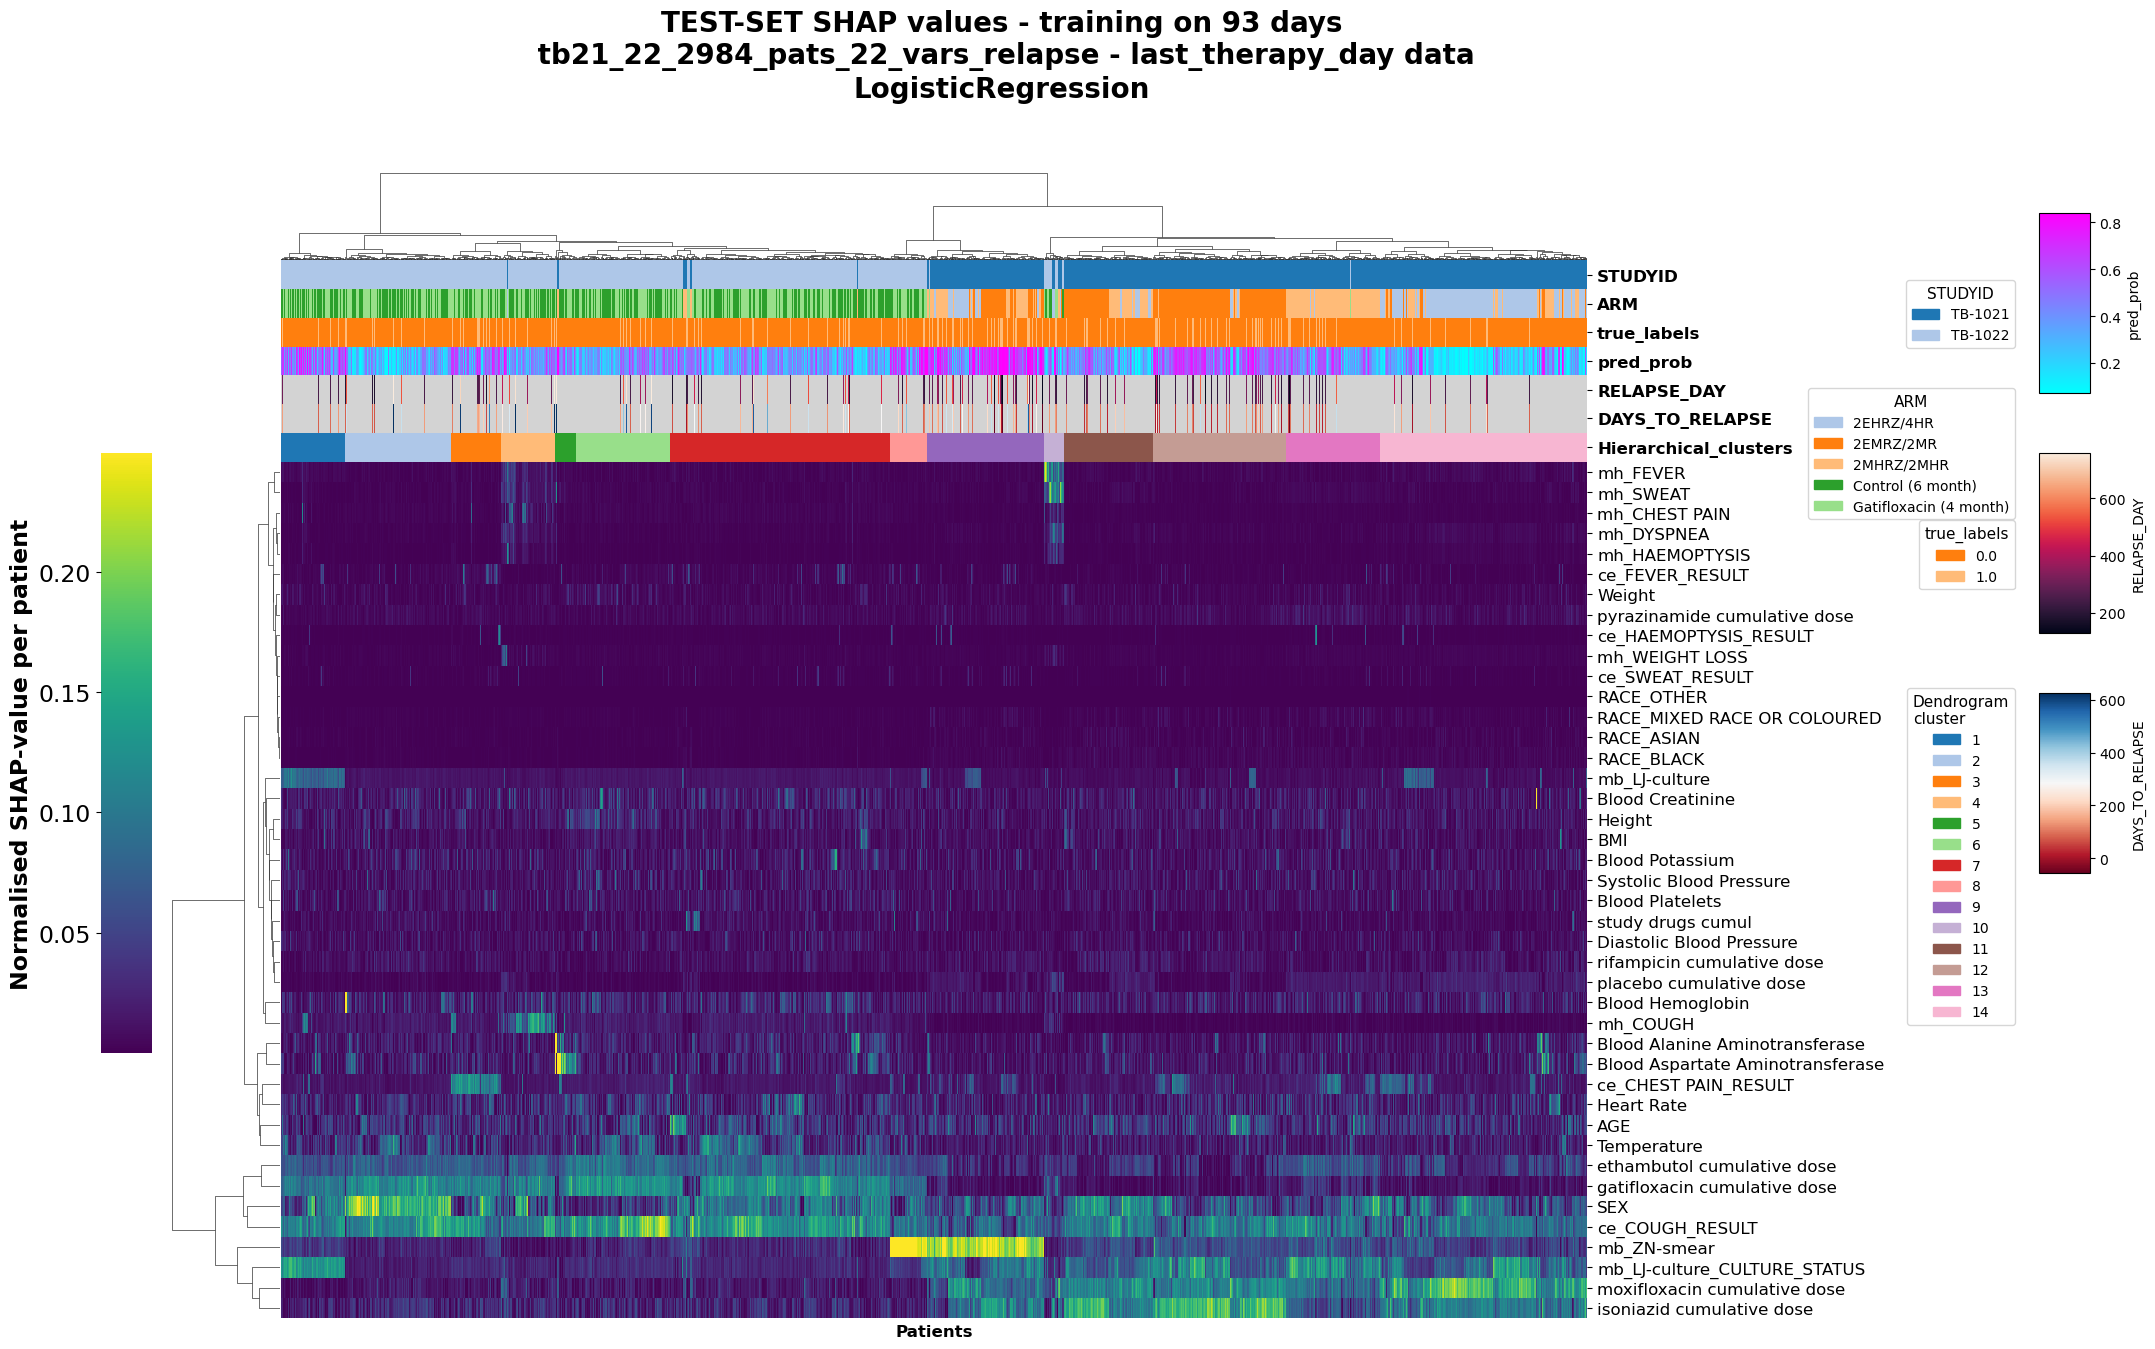

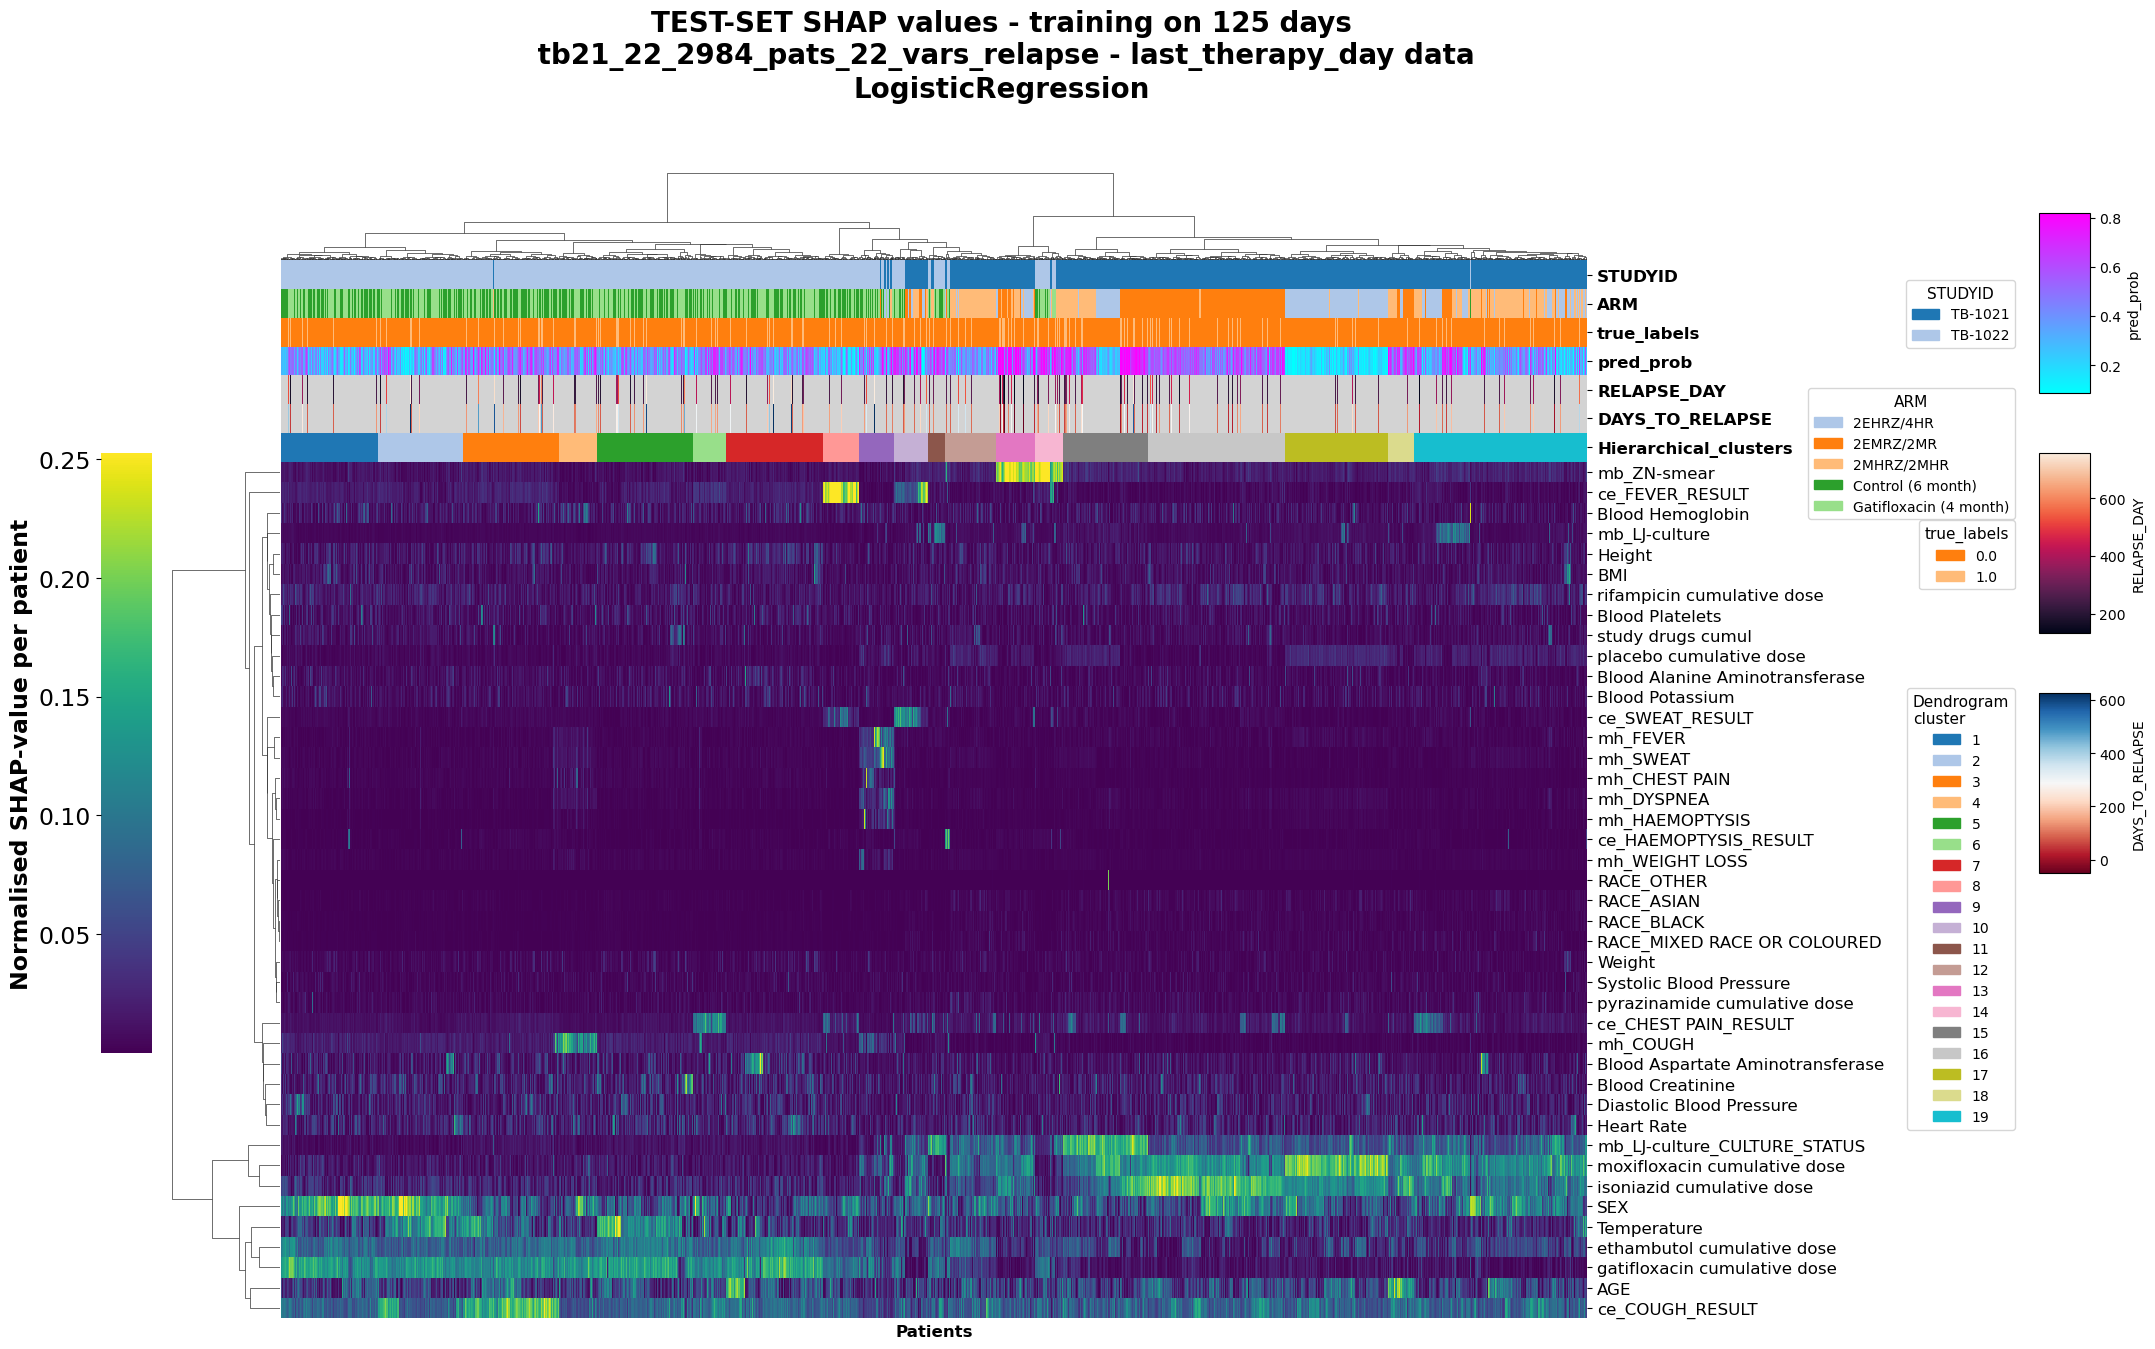

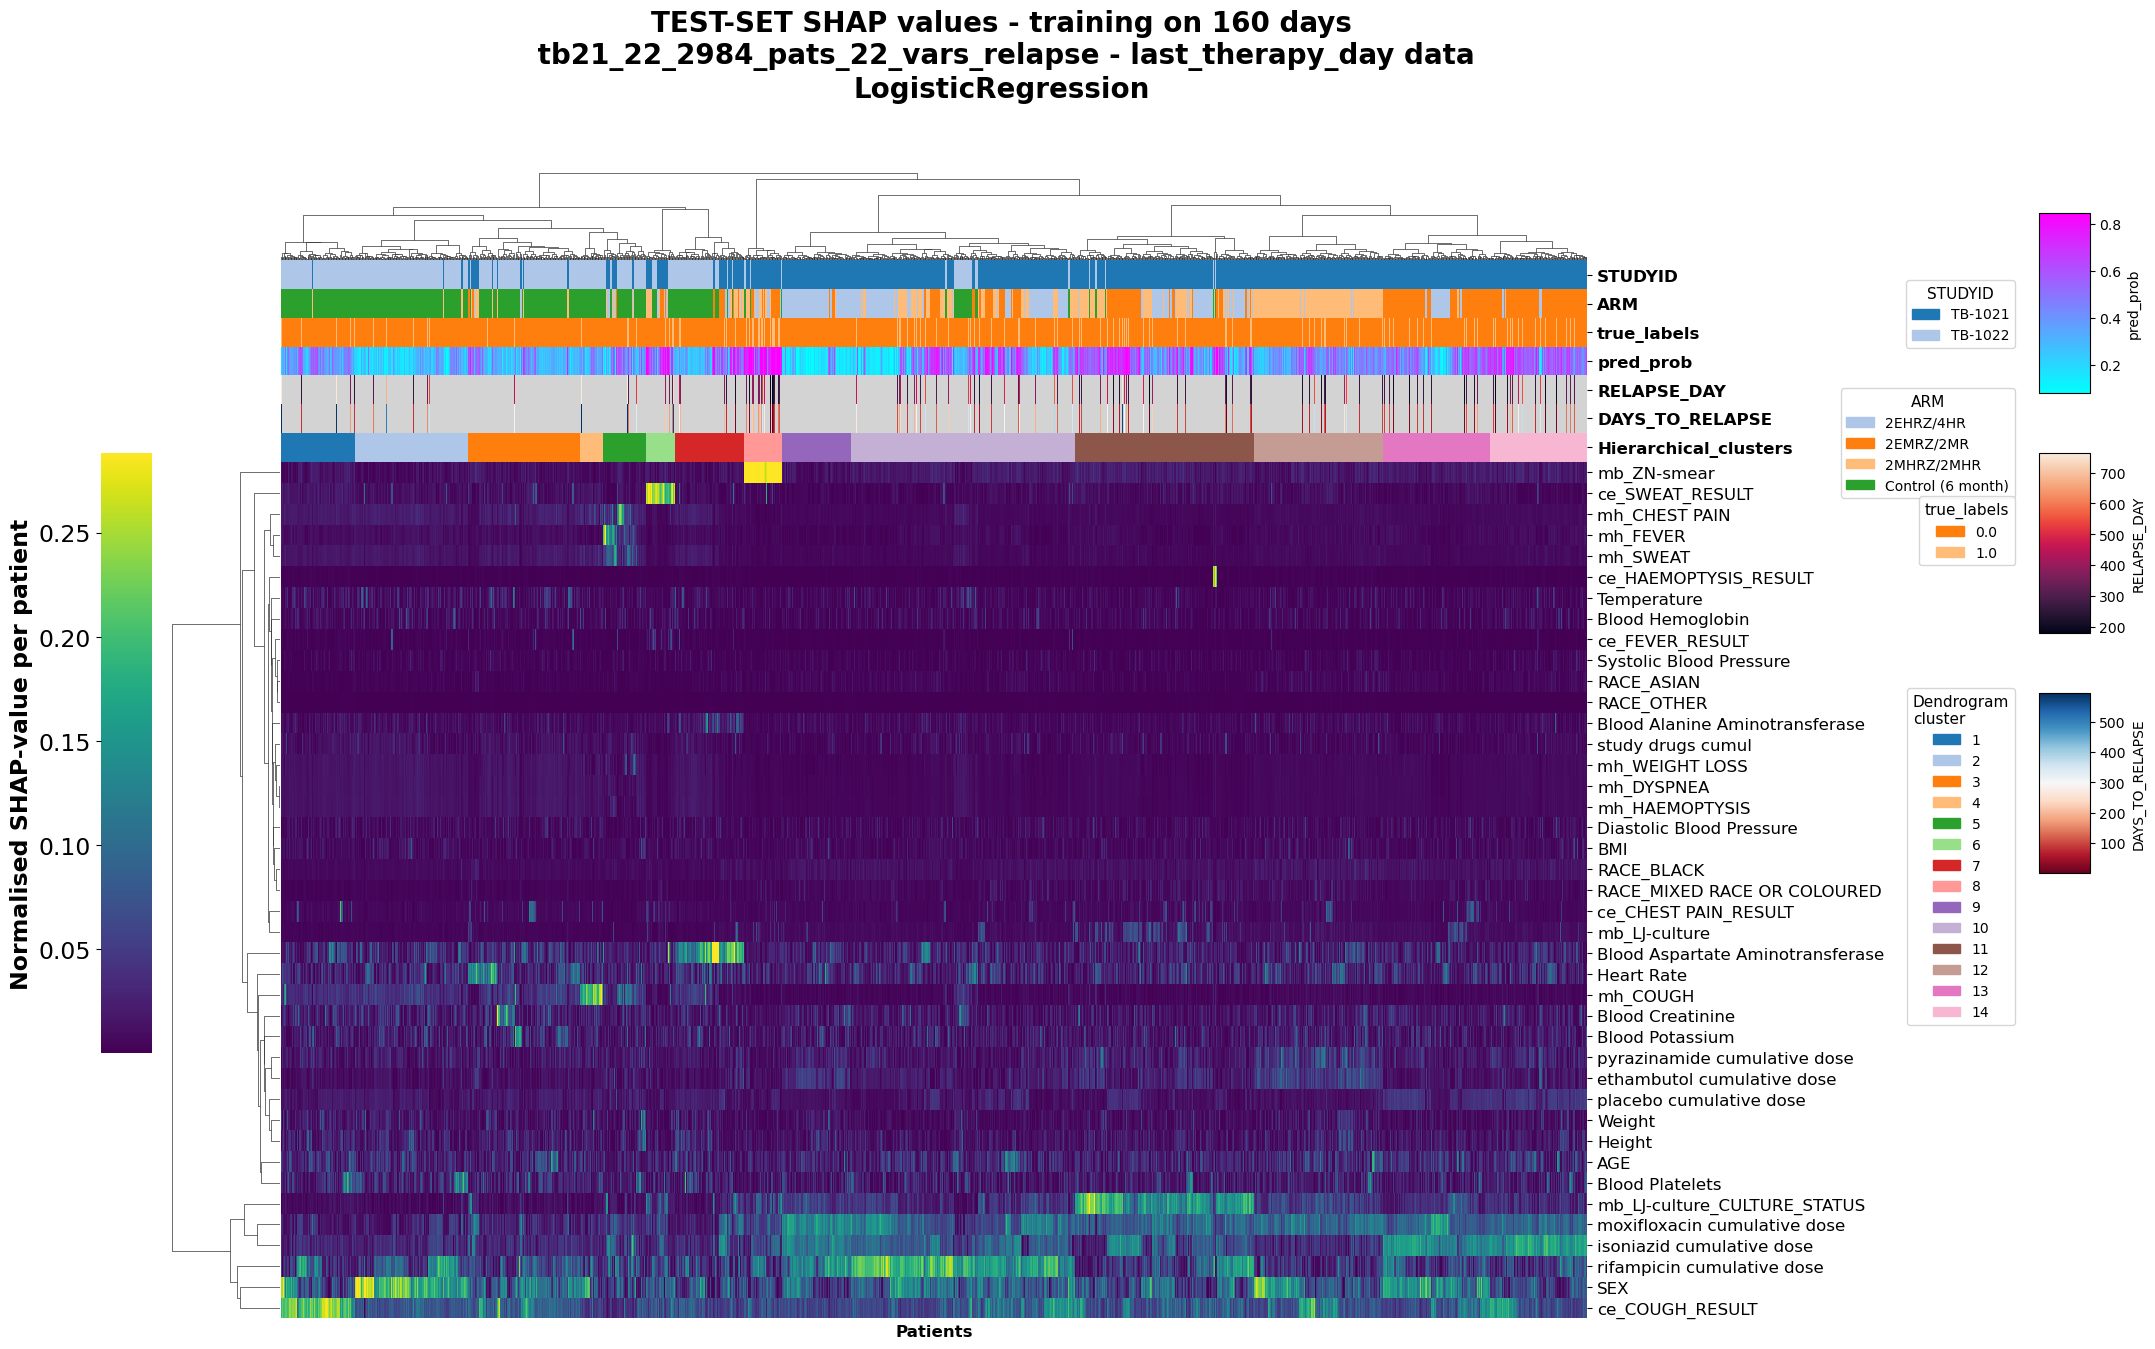

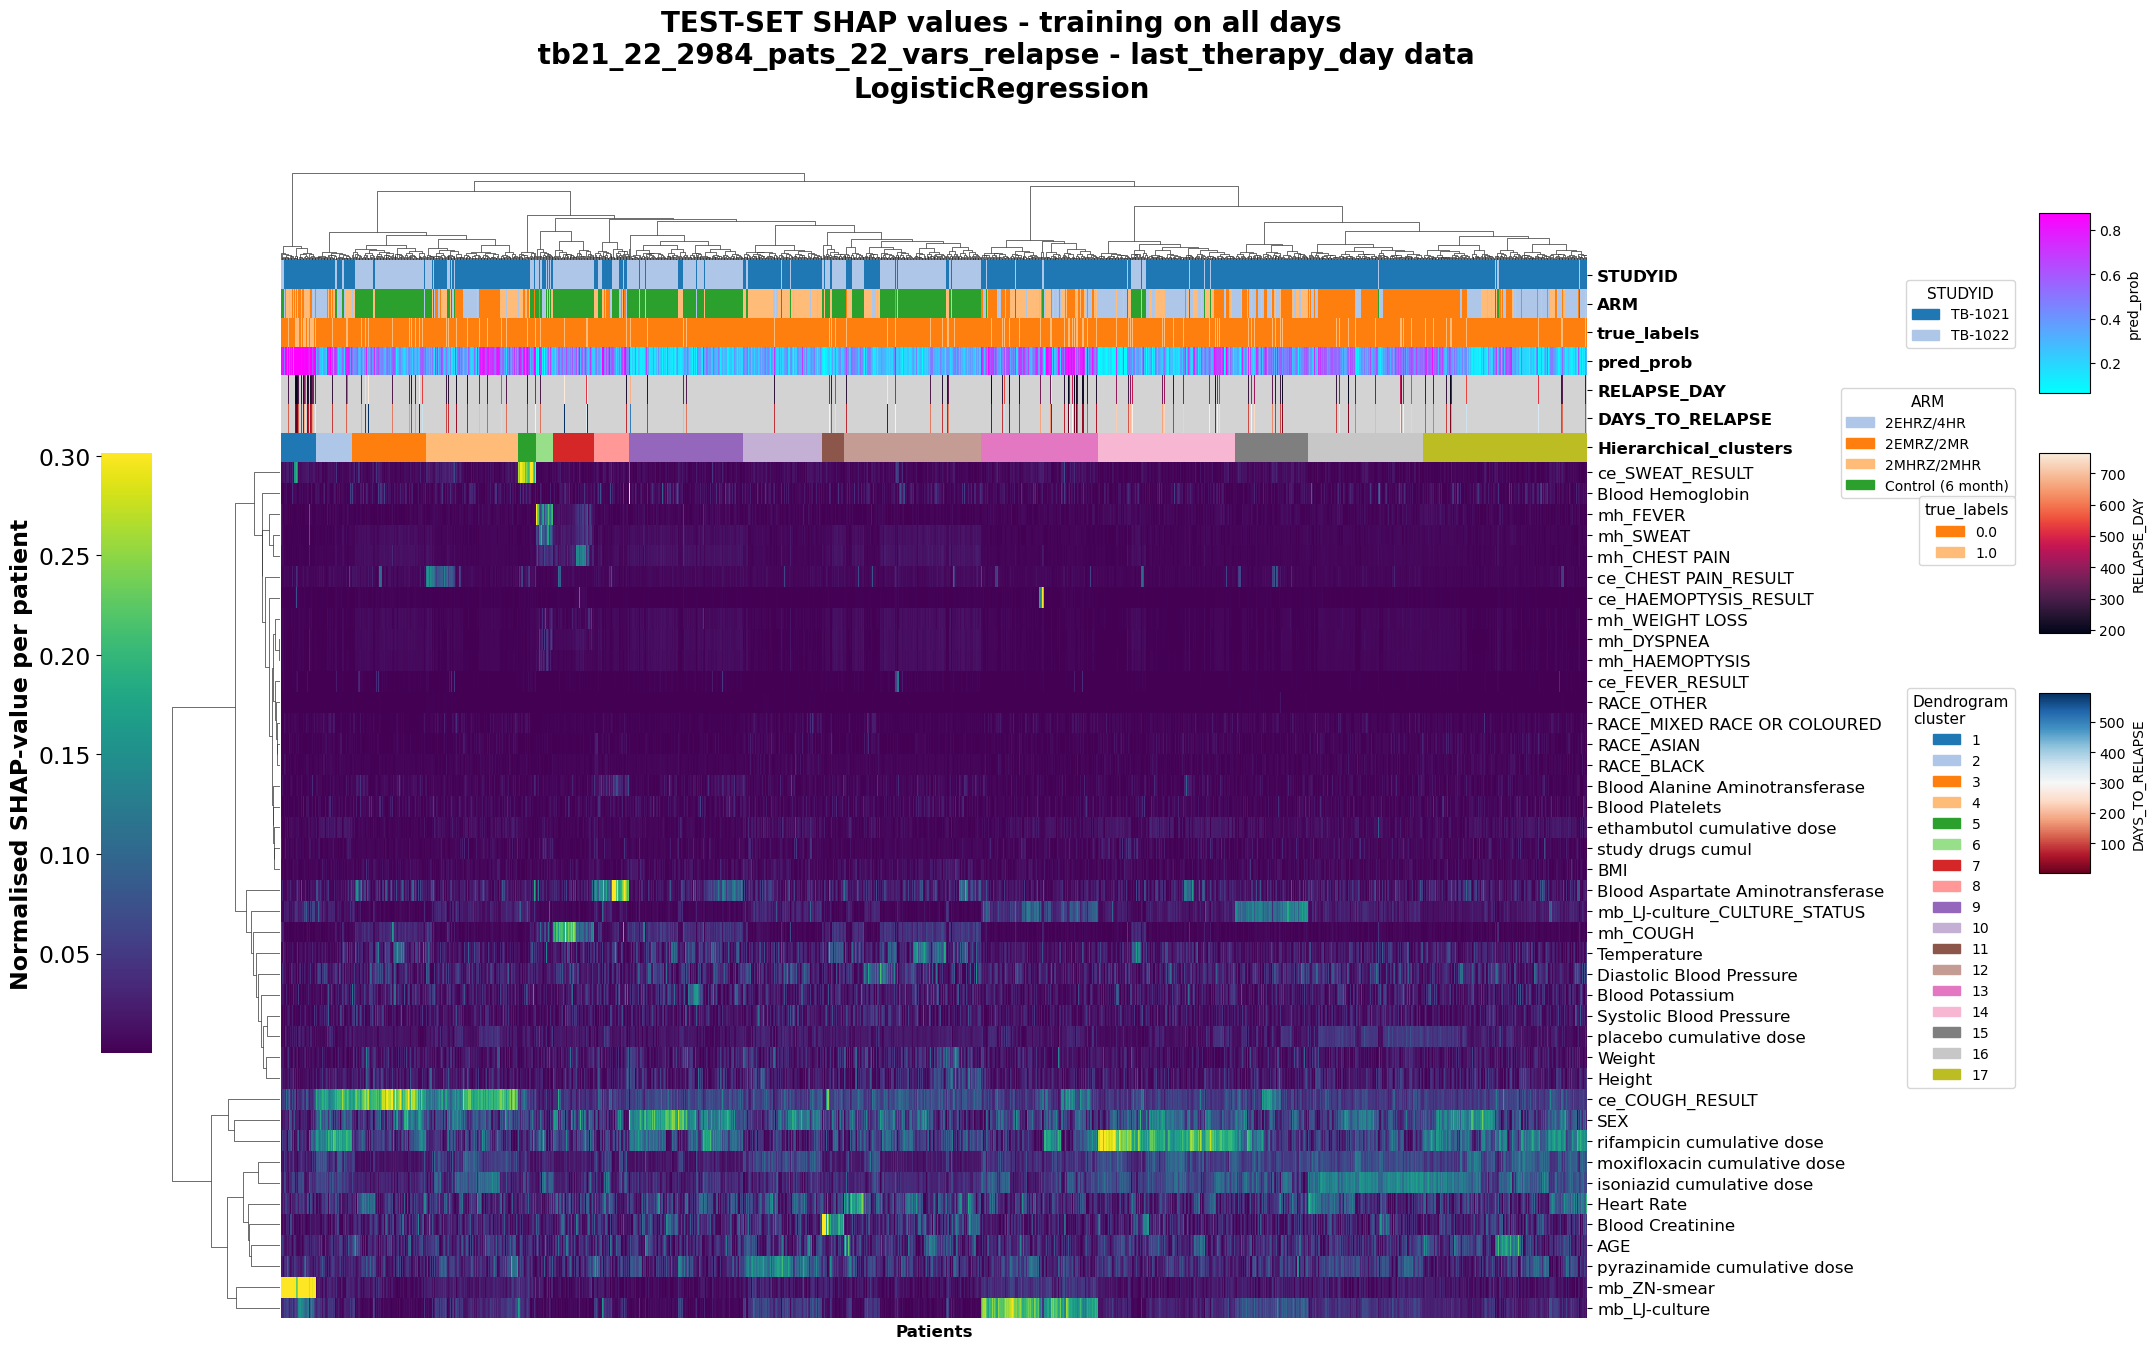

In [32]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


training_data_types=['all_days_in_period','last_therapy_day']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]



avg_abs_shap_val_dict,avg_raw_shap_val_dict,x_test_list,suptitles_dict={},{},{},{}

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    ## Define X and y dataframes for training

    outcome_label=data_param_key.split('vars_')[-1].upper()
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    l,k=[],[]
    
    for period_end_day in period_end_days[:]:      
        print(f'{period_end_day}')

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')


            for model_name in model_names_for_plotting[1:]:
                print(f'Loading SHAP-values for model {model_name}')
                

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv=pd.read_csv(fn,index_col=0)
                
                
                ## Put categorical columns into index, keeping only numeric columns as values
                merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b|true_labels')]).reset_index().drop(columns='level_2')
                merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')

                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                low_thr=0.00
                num_cols=merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|true_labels|pred_prob|\bARM\b',regex=True)].abs().mean()
                cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=cols_to_drop)

            
                
                for data_type in ['train','test'][1:]:

                    merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])


                    all_nan_cols=merged_x_test_across_cv_dtype.isna().all()[merged_x_test_across_cv_dtype.isna().all().values].index.tolist()
       

                    ## Extract only patients with the highest and lowest pred. probability
                    '''
                    a=merged_shap_across_cv_dtype.loc[(merged_shap_across_cv_dtype['pred_prob']>0.9)\
                                    |(merged_shap_across_cv_dtype['pred_prob']<0.2)\
                                    ,~merged_shap_across_cv_dtype.columns.isin(all_nan_cols)]
                    '''

                    ## Extract all patients
                    a=merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.isin(all_nan_cols)].copy()
                    
                    ## Average SHAP values across the patients
                    avg_shap=a.groupby('USUBJID').apply(lambda x:x.loc[:,~x.columns.isin(['ARM'])].mean())
                    avg_shap['ARM']=a.drop_duplicates('USUBJID').set_index('USUBJID').loc[avg_shap.index,'ARM'].values
                    a=avg_shap.reset_index().copy()
                    
                    ## Add STUDYID
                    aa=X[['USUBJID','STUDYID']].drop_duplicates(subset=['USUBJID']).set_index('USUBJID')
                    a['STUDYID'] = aa.loc[a['USUBJID'].values.tolist()].values.flatten()

                    if outcome_label=='RELAPSE':
                        a[['RELAPSE_DAY','DAYS_TO_RELAPSE']]=pats_with_relapse_df.loc[a['USUBJID'].tolist(),['RELAPSE_DAY','DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']].values
                        #a['RELAPSE_DAY']=a['RELAPSE_DAY'].fillna(0)
                        (pats_with_relapse_df['RELAPSE_DAY'].dropna()).index
                        a=a.set_index(['STUDYID','USUBJID','cv_repeat_num','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE'])
                        col_color_var_list=['STUDYID','cv_repeat_num','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']
                        #a=a.loc[a.index.get_level_values('RELAPSE_DAY')>0,:]
                        #a = a[~a.index.get_level_values('DAYS_TO_RELAPSE').isna()]

                        # Sort 'a' by the levels 'RELAPSE_DAY','ARM' and 'cv_repeat_num'
                        a = a.sort_index(level=['RELAPSE_DAY','ARM', 'cv_repeat_num'][:])

                    if outcome_label!='RELAPSE':
                        a=a.set_index(['STUDYID','USUBJID','cv_repeat_num','ARM','true_labels','pred_prob'])
                        col_color_var_list=['STUDYID','cv_repeat_num','ARM','true_labels','pred_prob']                        
                    
                        # Sort 'a' by the levels 'ARM' and 'cv_repeat_num'
                        a = a.sort_index(level=['ARM', 'cv_repeat_num'][:])
                    
                    col_color_var_list.remove('cv_repeat_num')
                    
                    ### CREATE CUSTOM LEGEND FOR REGIONS
                    # Create a list for column colors
                    col_colrs_list = []
                    legends = []  # Store legend details
                    
                    
                
                    colormaps=['cool','rocket','RdBu']
                    num_col_color_vars = ['pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']
                    numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
                    
                    for n,colour_coln in enumerate(col_color_var_list):
     
                        if colour_coln in num_col_color_vars:
    
                            # Extract column values
                            col_vals = a.reset_index()[colour_coln]
                            
                            # Identify NaNs
                            nan_mask = col_vals.isna()
                        
                            # Normalize only the non-NaN values
                            non_nan_values = col_vals[~nan_mask]
                            norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                                                 vmax=np.quantile(non_nan_values, 0.98))
                        
                            # Choose colormap
                            colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
                        
                            # Apply color mapping (gray for NaNs, colormap for valid values)
                            continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]
                            
                            col_colrs_list.append(continuous_colors)
                            
                            # Add colorbar for continuous variable (only for non-NaN values)
                            legends.append({"type": "continuous",
                                            "label": colour_coln,
                                            "norm": norm,
                                            "colormap": colormap})


                        
                        else:
                            col_vars=np.sort(a.index.get_level_values(colour_coln).astype(str).unique())
                            ordered_clusters_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
                            ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
                        
                            col_colrs_list.append(a.reset_index()[colour_coln].astype(str).map(ordered_clusters_color_mapping).tolist())
                    
                            # Add legend for categorical variable
                            patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
                                for region in col_vars]
                            
                            legends.append({"type": "categorical",
                                            "label": colour_coln,
                                            "handles": patch_handles})
                        '''
                        nan_patch = Patch(color='#d3d3d3', label='Missing (NaN)')
                        legends.append({"type": "categorical",
                                        "label": "NaN Values",
                                        "handles": [nan_patch]})
                        '''                                        

                    ### Take the absolute value of the SHAP-values, and calculate the normalised contribution of each variable per patient
                    b=a.copy()
                    a=a.abs()
                    a = a.div(a.sum(axis=1),axis=0)
                    #a=a*100

                     # Extract linkage matrix for columns
                    col_linkage = sch.linkage(a, method="ward", metric="euclidean") 
                    
                    # Step 2: Use fcluster to get cluster assignments
                    from scipy.cluster.hierarchy import fcluster
                    
                    # Choose a distance threshold (adjust `t` as needed)
                    t = 1  
                    #t=0.5
                    #t = 6
                    col_clusters = fcluster(col_linkage, t=t, criterion='distance')
                    
                    # Step 3: Map each cluster to a unique color
                    num_clusters = len(set(col_clusters))  # Number of unique clusters
                    col_palette = sns.color_palette("tab20", num_clusters)  # Use a categorical color palette
                    cluster_color_mapping = {cluster: col_palette[i] for i, cluster in enumerate(set(col_clusters))}
                    
                    # Step 4: Apply colors to the column dendrogram
                    dendro_colors = [cluster_color_mapping[cluster] for cluster in col_clusters]# + [(0,0,0,1)]*len(a)
                    col_colrs_list.append(dendro_colors)


                    legends.append({"type": "categorical",
                                        "label": "Dendrogram cluster",
                                        "handles":[Patch(color=color, label=str(dendr_clust))
                                                    for dendr_clust,color in cluster_color_mapping.items()]})
                    col_color_var_list.append('Hierarchical_clusters')

                    cbar_label='Normalised SHAP-value per patient'
                    #cbar_label='Impact on prediction\n<== FAVOURABLE | UNFAVOURABLE ==>'

                    
                    
                    ## PLOT CLUSTERMAP
                    g=sns.clustermap(a.T,
                                     col_colors=col_colrs_list,
                                      vmin=np.quantile(a.values,0.001),                                    
                                      vmax=np.quantile(a.values,0.999),
                                     row_cluster=True, 
                                     col_cluster=True, 
                                     #colors_ratio=0.01,
                                     method='ward', 
                                     metric='euclidean', 
                                     figsize=(17,12),
                                     yticklabels=True,
                                     xticklabels=False,
                                     cmap='viridis',
                                     dendrogram_ratio=(0.08,0.08),
                                     colors_ratio=0.025,
                                     #z_score=0,
                                     cbar_pos=(-0.03, 0.25, 0.03, 0.5),
                                     cbar_kws={'label':cbar_label},
                                     #tree_kws={'colors':dendro_colors,'linewidths':1.5}
                                  )
                    
                    g.ax_heatmap.set_xlabel('Patients',fontsize=12,fontweight='bold')
                    g.ax_cbar.yaxis.set_label_position("left")
                    g.ax_cbar.yaxis.tick_left()
                    g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=17, fontweight='bold')
                    g.ax_cbar.tick_params(axis='y',labelsize=17)
                    g.ax_heatmap.tick_params(axis='y',labelsize=12)

                
                    
                    # Add legends
                    cont_leg_num=0
                    fig = g.fig  # Access the figure from clustermap
                    for i, legend in enumerate(legends):

                        if legend["type"] == "categorical":
                            if i==0:
                                label_size=0
                            
                            fig.legend(
                                handles=legend["handles"],
                                title=legend["label"].replace(' ','\n'),
                                loc="upper right",
                                bbox_to_anchor=(1.1, 0.9 - i * 0.05 -label_size),
                                frameon=True,
                                fontsize=10,
                                title_fontsize=11
                            )
                            label_size=len(legend["handles"])*0.02
                            
                        elif legend["type"] == "continuous":

                            cbar_ax = fig.add_axes([1.11, 0.8 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
                            ColorbarBase(
                                cbar_ax,
                                cmap=legend["colormap"],
                                norm=legend["norm"],
                                orientation='vertical',
                            ).set_label(legend["label"], fontsize=10)
                            cont_leg_num=cont_leg_num+1
                    
                    ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
                    # Calculate the y positions for the ticks
                    
                    num_col_colors = len(col_color_var_list)
                    yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
                    g.ax_col_colors.set_yticks(yticks)
                    
                    # Set the tick labels on the right side
                    g.ax_col_colors.yaxis.tick_right()
                    
                    # Set the tick labels for each color bar
                    col_col_names=col_color_var_list
                    g.ax_col_colors.set_yticklabels(col_col_names, 
                                                    fontsize=12,  # Adjust fontsize here
                                                    ha='left',  # Horizontal alignment to be closer to the color bars
                                                    weight='bold'
                                                   )
                    if data_param_key in suptitle_study_dict.keys():
                        study_names=suptitle_study_dict[data_param_key]
                        prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                        train_ds_type=suptitle_training_type_dict[training_data_type]
                        if isinstance(period_end_day,int):
                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                        if period_end_day=='all':
                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                        if period_end_day=='baseline':
                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: outcome at {str(prediction_time)}"
                    else:
                        suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"
                    fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.12) 



                    ### SAVE PLOTS
                    os.makedirs(f'../data/plots/raw_SHAP_values_clustermaps',exist_ok=True)
                    fn=os.path.join(f'../data/plots/raw_SHAP_values_clustermaps/',
                                f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_{data_type}_set_SHAP_clutermaps.png')
                    g.fig.savefig(fn, bbox_inches='tight', dpi=300)
                    #plt.close()

                    
                    ## EXTRACT X-TEST VARIABLES FOR EACH PATIENT, ADD CLUSTERING BASED ON ABS. NORM. SHAP-VALUES +  SAVE TO LIST
                    x_test_= merged_x_test_across_cv_dtype[~merged_x_test_across_cv_dtype.index.duplicated()].loc[a.index.get_level_values('USUBJID'),:]
                    x_test_['cluster'] = col_clusters
                    a['cluster'] = col_clusters
                    b['cluster'] = col_clusters

                    key_name=f'{data_param_key}_{period_end_day}_{model_name}_{training_data_type}_{data_type}'
                    avg_abs_shap_val_dict[key_name]=a
                    avg_raw_shap_val_dict[key_name]=b
                    x_test_list[key_name]=x_test_
                    suptitles_dict[key_name]=suptitle

 
                    

In [ ]:
merg_x = merged_x_test_across_cv_dtype.copy()
#merg_x['cluster'] = col_clusters
merg_x['STUDYID']=merg_x.reset_index()['USUBJID'].str.split('/',expand=True)[0]
merg_x['true_labels'] = pats_with_relapse_df.loc[merg_x.reset_index()['USUBJID'],outcome_label].values
merg_x[['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']] = a.reset_index().set_index('USUBJID').loc[merg_x.reset_index()['USUBJID'],['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']].values


clust_dict=dict(zip(a.index.get_level_values('USUBJID'),col_clusters))
merg_x['cluster']=merg_x.reset_index()['USUBJID'].map(clust_dict).values
merg_x=merg_x.reset_index().set_index(['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE','cluster'])

column_order,row_order = g.dendrogram_col.reordered_ind,g.dendrogram_row.reordered_ind 
column_names = a.T.columns.get_level_values('USUBJID')[column_order] 
idx_names = a.T.index[row_order] # Get column names in clustered order

clustmap_order = a.iloc[column_order,row_order].reset_index()[['USUBJID','cv_repeat_num']].values
clustmap_order_tuples = [tuple(row) for row in clustmap_order]
#p=merg_x.reset_index().set_index(['USUBJID','cv_repeat_num']).loc[clustmap_order_tuples,idx_names]
p=merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[column_names,idx_names]
#p=p.loc[:,~p.columns.isin(['ARM'])]
#p=(p-p.min())/(p.max()-p.min())


from scipy.stats import zscore
z_score=None

if z_score==1:
    vmax=np.quantile(zscore(p).values.flatten(),0.98)
    vmin=np.quantile(zscore(p).values.flatten(),0.01)

if z_score==0:
    vmax=np.quantile(zscore(p.T).values.flatten(),0.98)
    vmin=np.quantile(zscore(p.T).values.flatten(),0.01)

if z_score is None:
    vmax=np.quantile(p.values.flatten(),0.98)
    vmin=np.quantile(p.values.flatten(),0.01)



### CREATE CUSTOM LEGEND FOR REGIONS
# Create a list for column colors
col_colrs_list = []
legends = []  # Store legend details

                    
colormaps=['cool','rocket','RdBu']
num_col_color_vars = ['pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']
numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
col_color_var_list=['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']

for n,colour_coln in enumerate(col_color_var_list):

    if colour_coln in num_col_color_vars:

        # Extract column values
        col_vals = merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[column_names,colour_coln]
        
        # Identify NaNs
        nan_mask = col_vals.isna()
    
        # Normalize only the non-NaN values
        non_nan_values = col_vals[~nan_mask]
        norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                             vmax=np.quantile(non_nan_values, 0.98))
    
        # Choose colormap
        colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
    
        # Apply color mapping (gray for NaNs, colormap for valid values)
        continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]

        #print(colour_coln)

        
        col_colrs_list.append(continuous_colors)
        
        # Add colorbar for continuous variable (only for non-NaN values)
        legends.append({"type": "continuous",
                        "label": colour_coln,
                        "norm": norm,
                        "colormap": colormap})


    
    else:
        col_vars=np.sort(merg_x.reset_index()[colour_coln].unique())
        ordered_clusters_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
        ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
    
        col_colrs_list.append(merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[column_names,colour_coln].map(ordered_clusters_color_mapping).tolist())

        # Add legend for categorical variable
        patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
            for region in col_vars]
        
        legends.append({"type": "categorical",
                        "label": colour_coln,
                        "handles": patch_handles})

    
# Step 4: Apply colors to the column dendrogram
dendro_colors = [cluster_color_mapping[cluster] for cluster in p.reset_index()['USUBJID'].map(clust_dict).values]# + [(0,0,0,1)]*len(a)
col_colrs_list.append(dendro_colors)


legends.append({"type": "categorical",
                    "label": "Dendrogram cluster",
                    "handles":[Patch(color=color, label=str(dendr_clust))
                                for dendr_clust,color in cluster_color_mapping.items()]})

col_color_var_list.append('Hierarchical_clusters')



#fig,ax=plt.subplots(1,1,figsize=(14,10))
#p=avg_raw_vars.loc[1,:]
h=sns.clustermap(p.T,
              cmap='viridis',
               method='ward',
               #col_colors=[np.array(col_colrs_list)[n][column_order].tolist() for n in range(len(col_colrs_list))],
               col_colors=col_colrs_list,
               col_cluster=False,
               row_cluster=False,
               xticklabels=False,
              yticklabels=True,
               #metric='euclidean', 
              figsize=(17,12),
              fmt='.1f',
              #ax=ax,
              annot_kws={'fontsize':'6'},
              z_score=z_score,
              standard_scale=0,
              annot=False,

              #vmax=vmax,
              #vmin=vmin,
                )


# Add legends
cont_leg_num=0
fig = h.fig  # Access the figure from clustermap
for i, legend in enumerate(legends):

    if legend["type"] == "categorical":
        if i==0:
            label_size=0
        
        fig.legend(
            handles=legend["handles"],
            title=legend["label"],
            loc="upper right",
            bbox_to_anchor=(1.1, 0.9 - i * 0.05 -label_size),
            frameon=True,
            fontsize=8,
            title_fontsize=10
        )
        label_size=len(legend["handles"])*0.02
        
    elif legend["type"] == "continuous":

        cbar_ax = fig.add_axes([1.13, 0.8 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
        ColorbarBase(
            cbar_ax,
            cmap=legend["colormap"],
            norm=legend["norm"],
            orientation='vertical',
        ).set_label(legend["label"], fontsize=10)
        cont_leg_num=cont_leg_num+1

## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
# Calculate the y positions for the ticks

num_col_colors = len(col_color_var_list)
yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
h.ax_col_colors.set_yticks(yticks)

# Set the tick labels on the right side
h.ax_col_colors.yaxis.tick_right()

# Set the tick labels for each color bar
col_col_names=col_color_var_list
h.ax_col_colors.set_yticklabels(col_col_names, 
                                fontsize=12,  # Adjust fontsize here
                                ha='left',  # Horizontal alignment to be closer to the color bars
                                weight='bold'
                               )
h.fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05) 
print()

#### Avg. SHAP-values per cluster

In [33]:



### CALCULATE ROC-AUC PER CLUSTER
def calc_roc_auc_score_(x):
    from sklearn.metrics import roc_auc_score
    try:
        roc=roc_auc_score(x['true_labels'],x['pred_prob'])
        return roc
    except ValueError:
        return np.nan




### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:
    data_list=[]
    
    for period_end_day in period_end_days[:]:      

        for training_data_type in training_data_types[1:]:

            for model_name in model_names_for_plotting[1:]:
             
                for data_type in ['train','test'][1:]:

                    key_name=f'{data_param_key}_{period_end_day}_{model_name}_{training_data_type}_{data_type}'
                    data = avg_abs_shap_val_dict[key_name]
                    #avg_raw_shap_val_dict[key_name]
                    #x_test_ = x_test_list[key_name]=
                    #suptitle = suptitles_dict[key_name]
                    print(key_name)


    
                    roc_auc_=data.reset_index()[['true_labels','pred_prob','cluster']].groupby('cluster').apply(lambda x:calc_roc_auc_score_(x))
                    unique_pat_nums=data.reset_index()[['USUBJID','cluster']].groupby('cluster').apply(lambda x:x['USUBJID'].unique().shape[0])
                    
                    if 'DAYS_TO_RELAPSE' in data.reset_index().columns:
                        days_to_relapse=data.reset_index()[['DAYS_TO_RELAPSE','cluster']].groupby('cluster').apply(lambda x:x['DAYS_TO_RELAPSE'].mean())
                        days_to_relapse_var=data.reset_index()[['DAYS_TO_RELAPSE','cluster']].groupby('cluster').apply(lambda x:x['DAYS_TO_RELAPSE'].std())
                        #aa=pd.concat([roc_auc_,days_to_relapse,days_to_relapse_var,unique_pat_nums],axis=1)
                        #aa.columns=['ROC_AUC','days_to_relapse_median','days_to_relapse_std_dev','num_of_pats_in_clust']
                    
                        aa=pd.concat([roc_auc_,unique_pat_nums],axis=1)
                        aa.columns=['ROC_AUC','unique_num_of_pats']
                    
                    if 'DAYS_TO_RELAPSE' not in data.reset_index().columns:
                        aa=pd.concat([roc_auc_,unique_pat_nums],axis=1)
                        aa.columns=['ROC_AUC','unique_num_of_pats']
                    
                    
                    ### ADD NUMBER OF RELAPSE PER CLUSTER AS COUNT OF PAITENTS AND AS PER PROPORTION AS WELL
                    relapse_counts = data.reset_index().groupby(['cluster']).apply(lambda x: x['true_labels'].value_counts(normalize=False)).reset_index()
                    relapse_props = data.reset_index().groupby(['cluster']).apply(lambda x: x['true_labels'].value_counts(normalize=True)).reset_index()
                    
                    if 'true_labels' not in relapse_counts.columns:
                        relapse_counts = relapse_counts.melt(id_vars=['cluster'],var_name='true_labels', value_name='count')
                        relapse_props = relapse_props.melt(id_vars=['cluster'],var_name='true_labels', value_name='proportion')
                    
                    relapse_props=relapse_props*100
                    
                    pp=pd.concat([relapse_counts,relapse_props],axis=1)
                    
                    pp=pp.loc[:,~pp.columns.duplicated()]
                    
                    aa[[f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']]=np.nan
                    aa.loc[pp.loc[pp['true_labels']==1.0,'cluster'].tolist(),[f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']] = pp[pp['true_labels']==1.0].set_index('cluster').loc[:,['proportion','count']].values
                    

                    data['ROC_AUC_in_clust'] = data['cluster'].map(aa['ROC_AUC'].to_dict()).values
                    data['period']=period_end_day
                    data['model']=model_name
                    data['data_type']=data_type
                    #data['setup']=key_name
                    
                    data_list.append(data)
                    
                    #print((aa.sort_values('ROC_AUC',ascending=False)).round(3))
                    '''
                    #sns.scatterplot(data=aa.reset_index(),
                    #               x='relapse_proportion',
                    #               #x='relapse_count',
                    #               y='ROC_AUC')
                    
                    
                    
                    
                    
                    ### CREATE CUSTOM LEGEND FOR REGIONS
                    # Create a list for column colors
                    col_colrs_list = []
                    legends = []  # Store legend details
                    
                                        
                    colormaps=['plasma','rocket','RdBu']
                    num_col_color_vars = ['ROC_AUC',f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']
                    numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
                    #col_color_var_list=['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']
                    col_color_var_list=['ROC_AUC',f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']
                    
                    for n,colour_coln in enumerate(col_color_var_list):
                    
                        if colour_coln in num_col_color_vars:
                    
                            # Extract column values
                            col_vals = aa.loc[p.columns.tolist(),colour_coln]
                            
                            # Identify NaNs
                            nan_mask = col_vals.isna()
                        
                            # Normalize only the non-NaN values
                            non_nan_values = col_vals[~nan_mask]
                            norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                                                 vmax=np.quantile(non_nan_values, 0.98))
                        
                            # Choose colormap
                            colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
                        
                            # Apply color mapping (gray for NaNs, colormap for valid values)
                            continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]
                    
                            #print(colour_coln)
                    
                            
                            col_colrs_list.append(continuous_colors)
                            
                            # Add colorbar for continuous variable (only for non-NaN values)
                            legends.append({"type": "continuous",
                                            "label": colour_coln,
                                            "norm": norm,
                                            "colormap": colormap})
                    
                    
                        
                        else:
                            col_vars=np.sort(merg_x.reset_index()[colour_coln].unique())
                            ordered_clusters_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
                            ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
                        
                            col_colrs_list.append(merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[column_names,colour_coln].map(ordered_clusters_color_mapping).tolist())
                    
                            # Add legend for categorical variable
                            patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
                                for region in col_vars]
                            
                            legends.append({"type": "categorical",
                                            "label": colour_coln,
                                            "handles": patch_handles})
                    
                    
                    
                    p=p*100
                    h=sns.clustermap(p,
                                  cmap='viridis',
                                   method='ward',
                                  xticklabels=True,
                                  yticklabels=True,
                                  dendrogram_ratio=(0.1,0.1),
                                   col_colors = col_colrs_list,
                                     colors_ratio=0.025,
                                   metric='euclidean', 
                                  cbar_pos=(-0.03, 0.25, 0.03, 0.5),
                                  cbar_kws={'label':'Norm. SHAP-value per patient\naveraged in cluster (%)'},
                                  figsize=(14,12),
                                  fmt='.2f',
                                  annot_kws={'fontsize':'10'},
                                  #z_score=1,
                                  annot=True,
                                  vmax=np.quantile(p.values.flatten(),0.999),
                                  vmin=np.quantile(p.values.flatten(),0.001))
                    
                    
                    h.fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.12) 
                    
                    # Adjust the position of the colorbar label
                    h.ax_cbar.yaxis.set_label_position("left")
                    h.ax_cbar.yaxis.tick_left()
                    h.ax_cbar.set_ylabel(h.ax_cbar.get_ylabel(), fontsize=14, fontweight='bold')
                    h.ax_cbar.tick_params(labelsize=10, width=1.5)
                    
                    #h.ax_heatmap.tick_params(axis='y',labelsize=6)
                    
                    
                    
                    ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
                    # Calculate the y positions for the ticks
                    
                    num_col_colors = len(col_color_var_list)
                    yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
                    h.ax_col_colors.set_yticks(yticks)
                    
                    # Set the tick labels on the right side
                    h.ax_col_colors.yaxis.tick_right()
                    
                    # Set the tick labels for each color bar
                    col_col_names=col_color_var_list
                    h.ax_col_colors.set_yticklabels(col_col_names, 
                                                    fontsize=12,  # Adjust fontsize here
                                                    ha='left',  # Horizontal alignment to be closer to the color bars
                                                    weight='bold'
                                                   )
                    
                    
                    # Add legends
                    cont_leg_num=0
                    fig = h.fig  # Access the figure from clustermap
                    for i, legend in enumerate(legends):
                    
                        if legend["type"] == "categorical":
                            if i==0:
                                label_size=0
                            
                            fig.legend(
                                handles=legend["handles"],
                                title=legend["label"],
                                loc="upper right",
                                bbox_to_anchor=(1.1, 0.8 - i * 0.05 -label_size),
                                frameon=True,
                                fontsize=8,
                                title_fontsize=10
                            )
                            label_size=len(legend["handles"])*0.02
                            
                        elif legend["type"] == "continuous":
                    
                            cbar_ax = fig.add_axes([1.03, 0.75 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
                            ColorbarBase(
                                cbar_ax,
                                cmap=legend["colormap"],
                                norm=legend["norm"],
                                orientation='vertical',
                            ).set_label(legend["label"], fontsize=10)
                            cont_leg_num=cont_leg_num+1
                    
                    
                    
                    
                    aaa=(aa.sort_values('ROC_AUC',ascending=False)).round(3)
                    #aaa.columns = aaa.columns.str.replace(f'{outcome_label}_',f'{outcome_label}\n')
                    aaa
                    '''

tb21_22_2984_pats_22_vars_relapse_baseline_LogisticRegression_last_therapy_day_test
tb21_22_2984_pats_22_vars_relapse_31_LogisticRegression_last_therapy_day_test
tb21_22_2984_pats_22_vars_relapse_62_LogisticRegression_last_therapy_day_test
tb21_22_2984_pats_22_vars_relapse_93_LogisticRegression_last_therapy_day_test
tb21_22_2984_pats_22_vars_relapse_125_LogisticRegression_last_therapy_day_test
tb21_22_2984_pats_22_vars_relapse_160_LogisticRegression_last_therapy_day_test
tb21_22_2984_pats_22_vars_relapse_all_LogisticRegression_last_therapy_day_test


In [37]:
data_=pd.concat(data_list,axis=0)
index_colnames =list(data_.index.names) + ['period','model','data_type','ROC_AUC_in_clust']
data_ = data_.reset_index().set_index(index_colnames)

In [73]:
plot_df = data_.reset_index().groupby(['USUBJID','period','model','data_type','ARM','STUDYID']).apply(lambda x:x['ROC_AUC_in_clust'])
plot_df = plot_df.reset_index()
plot_df['period_']=plot_df['period'].replace({'baseline':0,'all':182}).astype(float)

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


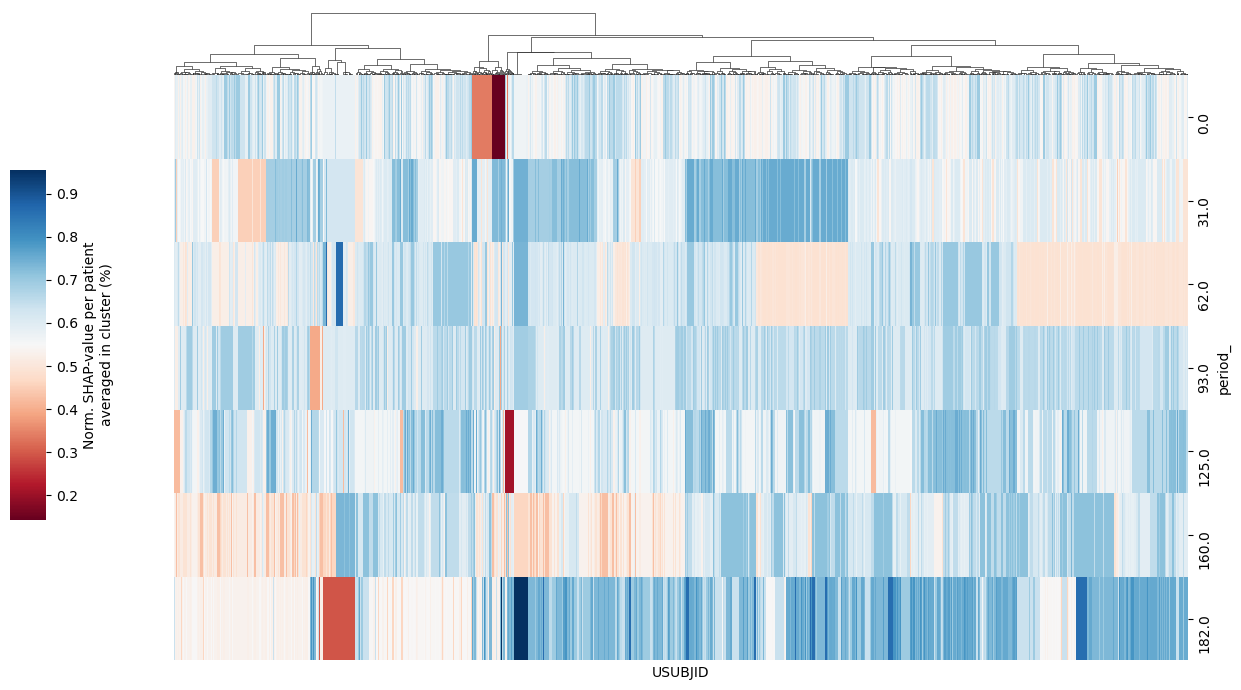

In [81]:


p=plot_df.pivot(columns='period_',values='ROC_AUC_in_clust',index='USUBJID')
#p=p.loc[:,p.columns[~p.columns.isin([160,182])]]
p=p.dropna()

sns.clustermap(p.T,
              cmap='RdBu',
               method='ward',
               col_cluster=True,
               row_cluster=False,
              xticklabels=False,
              yticklabels=True,
              dendrogram_ratio=(0.1,0.1),
              #col_colors = col_colrs_list,
              #colors_ratio=0.025,
              metric='euclidean', 
              cbar_pos=(-0.03, 0.25, 0.03, 0.5),
              cbar_kws={'label':'Norm. SHAP-value per patient\naveraged in cluster (%)'},
              figsize=(12,7),
              fmt='.2f',
              annot_kws={'fontsize':'10'},
              #z_score=1,
              annot=False,
              vmax=np.quantile(p.values.flatten(),0.999),
              vmin=np.quantile(p.values.flatten(),0.001))

In [70]:
plot_df.columns

Index(['USUBJID', 'period', 'model', 'data_type', 'level_4',
       'ROC_AUC_in_clust', 'period_'],
      dtype='object')

<Axes: xlabel='period_', ylabel='ROC_AUC_in_clust'>

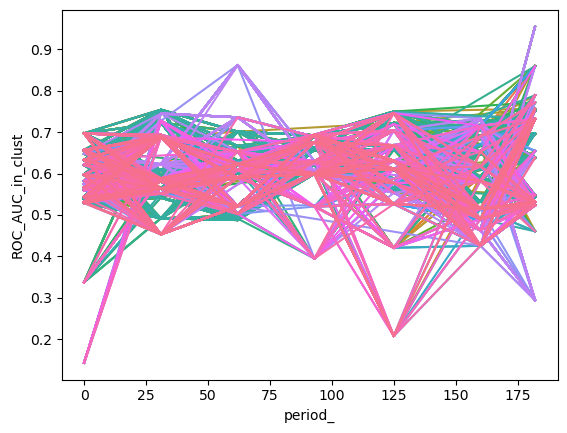

In [77]:

sns.lineplot(data=plot_df,
             x='period_',
            #hue='USUBJID',
            hue='USUBJID',
            y='ROC_AUC_in_clust',
            legend=False)

#### Correlation of raw input - SHAP-values within clusters

In [ ]:
from scipy.stats import spearmanr,pearsonr
import warnings
warnings.filterwarnings("ignore")


merg_x = merged_x_test_across_cv_dtype.copy()
#merg_x = merg_x.reset_index().sort_values(by=['cv_repeat_num','USUBJID'])
merg_x = merg_x.reset_index().drop_duplicates('USUBJID').sort_values('USUBJID')#.set_index('USUBJID')
merg_x['cluster'] = data['cluster'].values

non_var_cols=['cluster','ARM','cv_repeat_num','USUBJID'][:-1]

merg_x_vars=merg_x.drop(columns=non_var_cols).set_index('USUBJID')



b_=b.reset_index().set_index('USUBJID')

dd_pval,dd_corr={},{}

for clust in merg_x['cluster'].unique():
    pats_in_clust=merg_x.loc[merg_x['cluster']==clust,'USUBJID'].tolist()

    dd_corr[clust]={}
    dd_pval[clust]={}

    for var in merg_x_vars.columns:
        dd_corr[clust][var]={}
        dd_pval[clust][var]={}
        
        raw_vars=merg_x_vars.loc[pats_in_clust,var].tolist()
        shap_vals=b_.loc[pats_in_clust,var].tolist()
        
        corr,pval= spearmanr(raw_vars,shap_vals)
        dd_corr[clust][var]=corr
        dd_pval[clust][var]=pval

        
cc=pd.DataFrame.from_dict(dd_corr,orient='columns').fillna(0)

#plt.figure(figsize=(13,13),          )
sns.clustermap(cc,
           cmap='RdBu',
           method='ward',
           annot=True,
            figsize=(13,13))   


#### Avg. norm. input vars per cluster

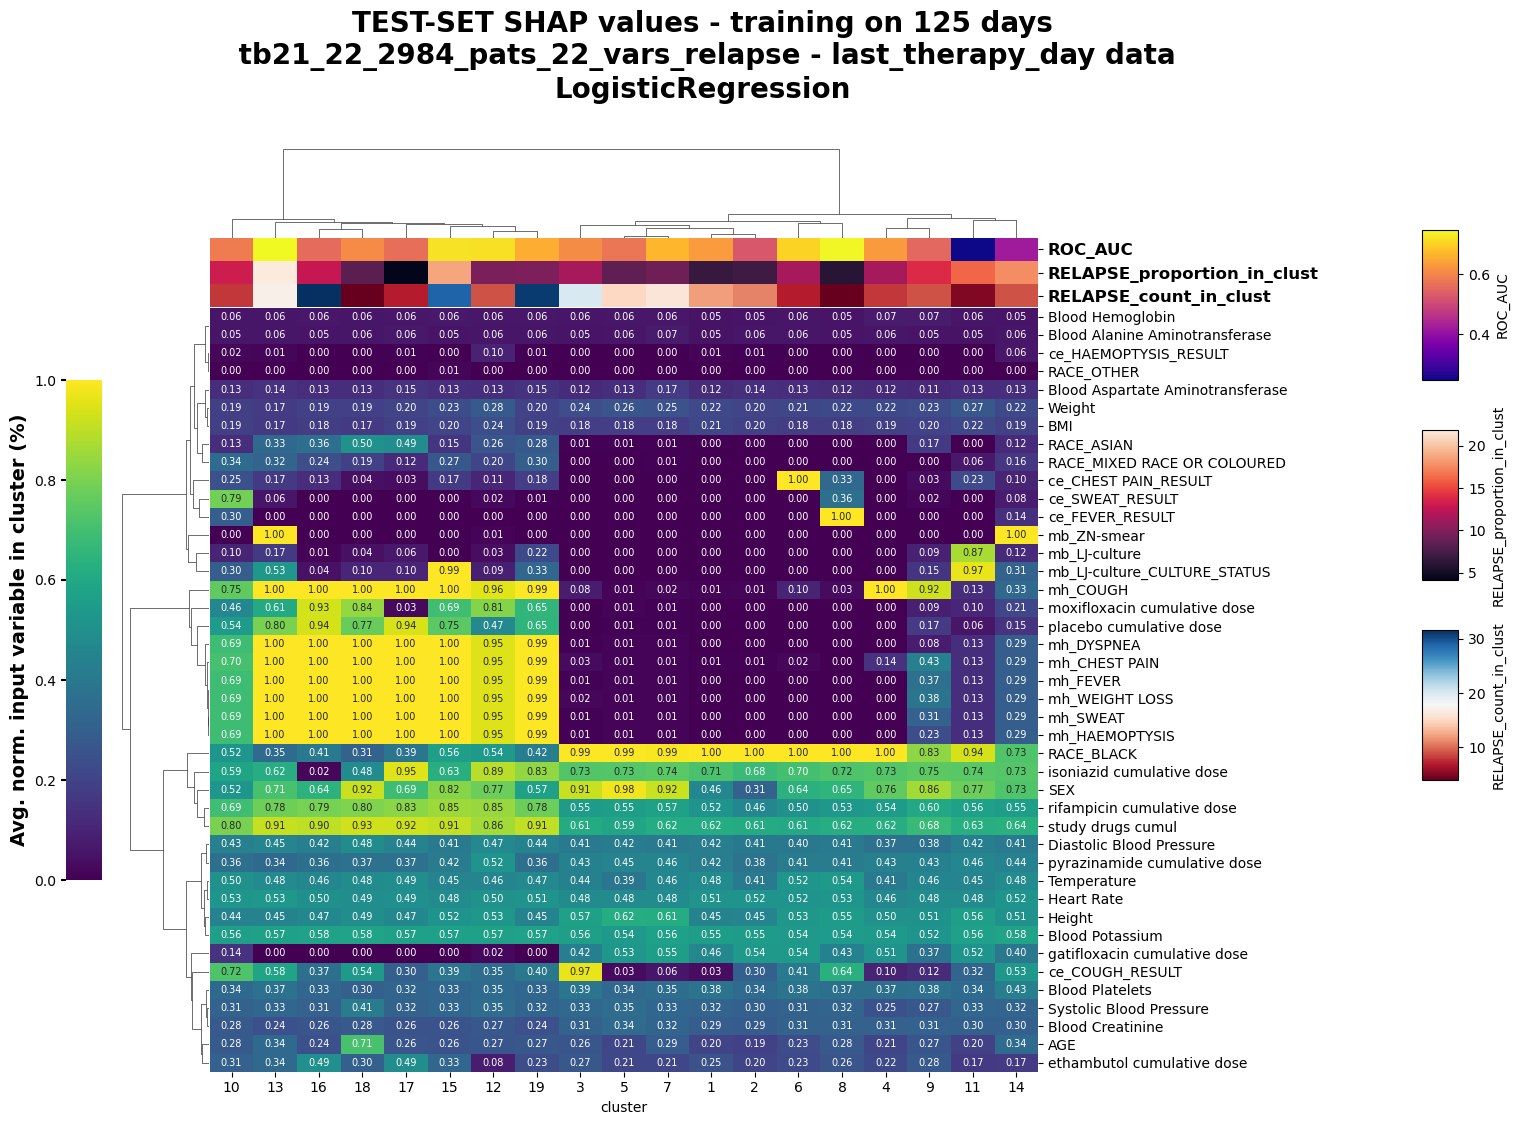

In [24]:
from scipy.stats import zscore

merg_x = merged_x_test_across_cv_dtype.copy()
#merg_x = merg_x.reset_index().sort_values(by=['cv_repeat_num','USUBJID'])
merg_x = merg_x.reset_index().drop_duplicates('USUBJID').sort_values('USUBJID')#.set_index('USUBJID')
merg_x['cluster'] = data['cluster'].values

non_var_cols=['cluster','ARM','cv_repeat_num','USUBJID']

merg_x_vars=merg_x.drop(columns=non_var_cols)

merg_x_vars=(merg_x_vars-merg_x_vars.min())/(merg_x_vars.max()-merg_x_vars.min())
#merg_x_vars = merg_x_vars.apply(zscore)
merg_x_vars['cluster']=merg_x['cluster'].values

avg_raw_vars=merg_x_vars.groupby('cluster').apply(lambda x: x.loc[:,~x.columns.isin(['cluster'])].mean())



### CREATE CUSTOM LEGEND FOR REGIONS
# Create a list for column colors
col_colrs_list = []
legends = []  # Store legend details

                    
colormaps=['plasma','rocket','RdBu']
num_col_color_vars = ['ROC_AUC',f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']
numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
col_color_var_list=['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']
col_color_var_list=['ROC_AUC',f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']

for n,colour_coln in enumerate(col_color_var_list):

    if colour_coln in num_col_color_vars:

        # Extract column values
        col_vals = aa.loc[avg_raw_vars.index,colour_coln]
        
        # Identify NaNs
        nan_mask = col_vals.isna()
    
        # Normalize only the non-NaN values
        non_nan_values = col_vals[~nan_mask]
        norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                             vmax=np.quantile(non_nan_values, 0.98))
    
        # Choose colormap
        colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
    
        # Apply color mapping (gray for NaNs, colormap for valid values)
        continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]

        #print(colour_coln)

        
        col_colrs_list.append(continuous_colors)
        
        # Add colorbar for continuous variable (only for non-NaN values)
        legends.append({"type": "continuous",
                        "label": colour_coln,
                        "norm": norm,
                        "colormap": colormap})


    
    else:
        col_vars=np.sort(merg_x.reset_index()[colour_coln].unique())
        ordered_clusters_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
        ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
    
        col_colrs_list.append(merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[column_names,colour_coln].map(ordered_clusters_color_mapping).tolist())

        # Add legend for categorical variable
        patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
            for region in col_vars]
        
        legends.append({"type": "categorical",
                        "label": colour_coln,
                        "handles": patch_handles})



#p=avg_raw_vars*100
p=avg_raw_vars 

h=sns.clustermap(p.T,
              cmap='viridis',
               method='ward',
              xticklabels=True,
              yticklabels=True,
              dendrogram_ratio=(0.1,0.1),
               col_colors = col_colrs_list,
                 colors_ratio=0.025,
               metric='euclidean', 
              cbar_pos=(-0.03, 0.25, 0.03, 0.5),
              cbar_kws={'label':'Avg. norm. input variable in cluster (%)'},
              figsize=(12,10),
              fmt='.2f',
              annot_kws={'fontsize':'7'},
              #z_score=0,
              #standard_scale=0,
              annot=True,
              #vmax=np.quantile(p.values.flatten(),0.98),
              #vmin=np.quantile(p.values.flatten(),0.01),
                )


h.fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.12) 

# Adjust the position of the colorbar label
h.ax_cbar.yaxis.set_label_position("left")
h.ax_cbar.yaxis.tick_left()
h.ax_cbar.set_ylabel(h.ax_cbar.get_ylabel(), fontsize=14, fontweight='bold')
h.ax_cbar.tick_params(labelsize=10, width=1.5)

#h.ax_heatmap.tick_params(axis='y',labelsize=6)

## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
# Calculate the y positions for the ticks

num_col_colors = len(col_color_var_list)
yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
h.ax_col_colors.set_yticks(yticks)

# Set the tick labels on the right side
h.ax_col_colors.yaxis.tick_right()

# Set the tick labels for each color bar
col_col_names=col_color_var_list
h.ax_col_colors.set_yticklabels(col_col_names, 
                                fontsize=12,  # Adjust fontsize here
                                ha='left',  # Horizontal alignment to be closer to the color bars
                                weight='bold'
                               )


# Add legends
cont_leg_num=0
fig = h.fig  # Access the figure from clustermap
for i, legend in enumerate(legends):

    if legend["type"] == "categorical":
        if i==0:
            label_size=0
        
        fig.legend(
            handles=legend["handles"],
            title=legend["label"],
            loc="upper right",
            bbox_to_anchor=(1.1, 0.8 - i * 0.05 -label_size),
            frameon=True,
            fontsize=8,
            title_fontsize=10
        )
        label_size=len(legend["handles"])*0.02
        
    elif legend["type"] == "continuous":

        cbar_ax = fig.add_axes([1.1, 0.75 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
        ColorbarBase(
            cbar_ax,
            cmap=legend["colormap"],
            norm=legend["norm"],
            orientation='vertical',
        ).set_label(legend["label"], fontsize=10)
        cont_leg_num=cont_leg_num+1





In [ ]:
merg_x = merged_x_test_across_cv_dtype.copy()
#merg_x['cluster'] = col_clusters
merg_x['STUDYID']=merg_x.reset_index()['USUBJID'].str.split('/',expand=True)[0]
merg_x['true_labels'] = pats_with_relapse_df.loc[merg_x.reset_index()['USUBJID'],outcome_label].values
merg_x[['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']] = a.reset_index().set_index('USUBJID').loc[merg_x.reset_index()['USUBJID'],['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']].values


clust_dict=dict(zip(a.index.get_level_values('USUBJID'),col_clusters))
merg_x['cluster']=merg_x.reset_index()['USUBJID'].map(clust_dict).values
merg_x=merg_x.reset_index().set_index(['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE','cluster'])

column_order,row_order = g.dendrogram_col.reordered_ind,g.dendrogram_row.reordered_ind 
column_names = a.T.columns.get_level_values('USUBJID')[column_order] 
idx_names = a.T.index[row_order] # Get column names in clustered order

clustmap_order = a.iloc[column_order,row_order].reset_index()[['USUBJID','cv_repeat_num']].values
clustmap_order_tuples = [tuple(row) for row in clustmap_order]
#p=merg_x.reset_index().set_index(['USUBJID','cv_repeat_num']).loc[clustmap_order_tuples,idx_names]


pats=data[data['cluster']==1].reset_index()['USUBJID']

p=merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[pats,idx_names]
#p=p.loc[:,~p.columns.isin(['ARM'])]
#p=(p-p.min())/(p.max()-p.min())


from scipy.stats import zscore
z_score=None

if z_score==1:
    vmax=np.quantile(zscore(p).values.flatten(),0.98)
    vmin=np.quantile(zscore(p).values.flatten(),0.01)

if z_score==0:
    vmax=np.quantile(zscore(p.T).values.flatten(),0.98)
    vmin=np.quantile(zscore(p.T).values.flatten(),0.01)

if z_score is None:
    vmax=np.quantile(p.values.flatten(),0.98)
    vmin=np.quantile(p.values.flatten(),0.01)



### CREATE CUSTOM LEGEND FOR REGIONS
# Create a list for column colors
col_colrs_list = []
legends = []  # Store legend details

                    
colormaps=['cool','plasma']
num_col_color_vars = ['pred_prob','DAYS_TO_RELAPSE']
numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
col_color_var_list=['STUDYID','ARM','true_labels','pred_prob','DAYS_TO_RELAPSE']

for n,colour_coln in enumerate(col_color_var_list):

    if colour_coln in num_col_color_vars:

        # Extract column values
        col_vals = merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[pats,colour_coln]
        
        # Identify NaNs
        nan_mask = col_vals.isna()
    
        # Normalize only the non-NaN values
        non_nan_values = col_vals[~nan_mask]
        norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                             vmax=np.quantile(non_nan_values, 0.98))
    
        # Choose colormap
        colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
    
        # Apply color mapping (gray for NaNs, colormap for valid values)
        continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]

        #print(colour_coln)

        
        col_colrs_list.append(continuous_colors)
        
        # Add colorbar for continuous variable (only for non-NaN values)
        legends.append({"type": "continuous",
                        "label": colour_coln,
                        "norm": norm,
                        "colormap": colormap})


    
    else:
        col_vars=np.sort(merg_x.reset_index()[colour_coln].unique())
        ordered_clusters_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
        ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
    
        col_colrs_list.append(merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[pats,colour_coln].map(ordered_clusters_color_mapping).tolist())

        # Add legend for categorical variable
        patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
            for region in col_vars]
        
        legends.append({"type": "categorical",
                        "label": colour_coln,
                        "handles": patch_handles})

    
# Step 4: Apply colors to the column dendrogram
dendro_colors = [cluster_color_mapping[cluster] for cluster in p.reset_index()['USUBJID'].map(clust_dict).values]# + [(0,0,0,1)]*len(a)
col_colrs_list.append(dendro_colors)


legends.append({"type": "categorical",
                    "label": "Dendrogram cluster",
                    "handles":[Patch(color=color, label=str(dendr_clust))
                                for dendr_clust,color in cluster_color_mapping.items()]})

col_color_var_list.append('Hierarchical_clusters')



#fig,ax=plt.subplots(1,1,figsize=(14,10))

#p=p.loc[pats,:]
p = p.loc[:,(p.nunique()>1).values]

h=sns.clustermap(p.T,
              cmap='viridis',
               method='ward',
               #col_colors=[np.array(col_colrs_list)[n][column_order].tolist() for n in range(len(col_colrs_list))],
               col_colors=col_colrs_list,
               col_cluster=True,
               row_cluster=True,
               xticklabels=False,
              yticklabels=True,
               #metric='euclidean', 
              figsize=(17,12),
              fmt='.1f',
              #ax=ax,
              annot_kws={'fontsize':'6'},
              z_score=z_score,
              standard_scale=0,
              annot=False,

              #vmax=vmax,
              #vmin=vmin,
                )


# Add legends
cont_leg_num=0
fig = h.fig  # Access the figure from clustermap
for i, legend in enumerate(legends):

    if legend["type"] == "categorical":
        if i==0:
            label_size=0
        
        fig.legend(
            handles=legend["handles"],
            title=legend["label"],
            loc="upper right",
            bbox_to_anchor=(1.1, 0.9 - i * 0.05 -label_size),
            frameon=True,
            fontsize=12,
            title_fontsize=12
        )
        label_size=len(legend["handles"])*0.02
        
    elif legend["type"] == "continuous":

        cbar_ax = fig.add_axes([1.13, 0.8 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
        ColorbarBase(
            cbar_ax,
            cmap=legend["colormap"],
            norm=legend["norm"],
            orientation='vertical',
        ).set_label(legend["label"], fontsize=10)
        cont_leg_num=cont_leg_num+1

## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
# Calculate the y positions for the ticks

num_col_colors = len(col_color_var_list)
yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
h.ax_col_colors.set_yticks(yticks)

# Set the tick labels on the right side
h.ax_col_colors.yaxis.tick_right()

# Set the tick labels for each color bar
col_col_names=col_color_var_list
h.ax_col_colors.set_yticklabels(col_col_names, 
                                fontsize=12,  # Adjust fontsize here
                                ha='left',  # Horizontal alignment to be closer to the color bars
                                weight='bold'
                               )
h.fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05) 
print()

In [ ]:
p.columns#['DAYS_TO_RELAPSE']

In [ ]:
(p['Blood Hemoglobin']).plot.bar()
plt.figure()
(zscore(p['Blood Hemoglobin']).plot.bar())

In [ ]:
plot_df=aa.dropna(how='any',axis=0)

fig,ax=plt.subplots(1,1,figsize=(8,5))
sns.scatterplot(data=plot_df,
               x='unique_num_of_pats',
               y='ROC_AUC',
               hue='days_to_relapse_median',
               ax=ax)

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(15,5))
sns.barplot(data=pp,
            x='cluster',
            #y='count',
            y='count',
            hue='true_labels',
            ax=ax,
            #boxprops={'fill': None},
            #legend=False,
           )


In [ ]:
fig,ax=plt.subplots(1,1,figsize=(15,5))
sns.boxplot(data=data,x='cluster',y='DAYS_TO_RELAPSE',
            #hue='ARM',
            ax=ax,boxprops={'fill': None},legend=False)
sns.stripplot(data=data,x='cluster',y='DAYS_TO_RELAPSE',
              #hue='ARM',
              ax=ax,dodge=True)

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(8,6))
data
sns.scatterplot(data=data[data['cluster']==14],
               x='pred_prob',
               y='DAYS_TO_RELAPSE',
               #hue='cluster',
               hue='STUDYID',
               ax=ax)

### Scatterplot - high & low pred. probs SHAP values

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import shap 
from sklearn.preprocessing import MinMaxScaler

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


#training_data_types=['full','last_therapy_day']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]



### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    ## Define X and y dataframes for training

    outcome_label=data_param_key.split('vars_')[-1].upper()
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    l,k=[],[]
    
    for period_end_day in period_end_days[:]:      
        print(f'{period_end_day}')

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')


            for model_name in model_names_for_plotting[1:]:
                print(f'Loading SHAP-values for model {model_name}')
                

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv=pd.read_csv(fn,index_col=0)
                
                
                ## Put categorical columns into index, keeping only numeric columns as values
                merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b|true_labels')]).reset_index().drop(columns='level_2')
                merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')

                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                low_thr=0.00
                num_cols=merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|true_labels|pred_prob|\bARM\b',regex=True)].abs().mean()
                cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=cols_to_drop)

                

                for data_type in ['train','test']:

                    merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    
                    ncols=3
                    nrows=int(np.ceil(merged_shap_across_cv_dtype['ARM'].unique().shape[0]/ncols))
                    fig=plt.figure(figsize=(8*ncols,10*nrows))
                
                       
                    for arm in merged_shap_across_cv_dtype['ARM'].unique()[:]:
    
                        study=merged_x_test_across_cv_numeric[merged_x_test_across_cv_numeric['ARM']==arm]['USUBJID'].map(study_pat_dict).unique()[0]
                        
                        shap_arm_df=merged_shap_across_cv_dtype[merged_shap_across_cv_dtype['ARM']==arm]
                        x_test_arm_df=merged_x_test_across_cv_dtype[(merged_x_test_across_cv_dtype['ARM']==arm)]
                    
                        #hi_prob_preds=arm_df.loc[arm_df['test_probabilities']>arm_df['test_probabilities'].quantile(0.95),:]
                        #low_prob_preds=arm_df.loc[arm_df['test_probabilities']<arm_df['test_probabilities'].quantile(0.2),:]
                        
                        hi_prob_preds=shap_arm_df.loc[shap_arm_df['pred_prob']>0.8,~shap_arm_df.columns.str.contains(r'true_label|pred_prob')]
                        low_prob_preds=shap_arm_df.loc[shap_arm_df['pred_prob']<0.1,~shap_arm_df.columns.str.contains(r'true_label|pred_prob')]
                    
                        hi_prob_x_test=x_test_arm_df.loc[(shap_arm_df['pred_prob']>0.8).values,:]
                        low_prob_x_test=x_test_arm_df.loc[(shap_arm_df['pred_prob']<0.1).values,:]
                        
                        hi_prob_preds_plot_df=pd.melt(hi_prob_preds,id_vars=['cv_repeat_num','ARM','USUBJID'])
                        low_prob_preds_plot_df=pd.melt(low_prob_preds,id_vars=['cv_repeat_num','ARM','USUBJID'])
                    
                        hi_prob_x_test_plot_df=pd.melt(hi_prob_x_test,id_vars=['cv_repeat_num','ARM'])
                        low_prob_x_test_plot_df=pd.melt(low_prob_x_test,id_vars=['cv_repeat_num','ARM'])
                    
                    
                    
                        fig,axes=plt.subplots(1,2,figsize=(15,8))
                    
                        for pred_df,x_test_df,ax_title,ax in zip([hi_prob_preds_plot_df,low_prob_preds_plot_df],
                                                              [hi_prob_x_test_plot_df,low_prob_x_test_plot_df],
                                                              ['Pats with pred.prob.>0.8','Pats with pred.prob.<0.1'],
                                                                axes):
                            
                            norm = Normalize(vmin=x_test_df['value'].min(), vmax=x_test_df['value'].max())
                            sm = ScalarMappable(norm=norm, cmap='inferno')
                            pal=sns.color_palette("inferno", as_cmap=True)
                            
                            stripplot = sns.stripplot(data=pred_df,y='variable',x='value',palette=pal,ax=ax,alpha=1,
                                                                hue=x_test_df['value'].values,s=3.5,jitter=0.2,linewidth=0.5)
                            
                            sns.barplot(data=pred_df,y='variable',x='value',errorbar='se',fill=False,ax=ax,alpha=0.5)
                    
                            ax.set_facecolor((0.9, 0.9, 0.9, 0.3))
                    
                    
                            ax.legend_.remove()
                        
                            # Add the colorbar
                            cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.002)
                            cbar.set_label('Feature Value',fontsize=12,fontweight='bold',labelpad=0.001)
                            
                            # Customize colorbar to show 'High' and 'Low'
                            cbar.set_ticks([x_test_df['value'].quantile(0.02), x_test_df['value'].quantile(0.98)])
                            cbar.set_ticklabels(['Low', 'High'],fontsize=10,fontweight='bold')
                            
                            ax.set_xlabel('Impact on prediction\n<== FAVOURABLE | UNFAVOURABLE ==>',fontsize=17,fontweight='bold')
                            #ax.set_xlabel('Average impact on model output magnitude',fontsize=10,fontweight='bold')
                            ax.tick_params(axis='both', labelsize=12)
                            ax.set_ylabel(None)
                            ax.set_title(f"{study_dict[study]} - Arm: {arm.replace(' regimen','')}\n{ax_title}",fontsize=20,fontweight='bold')
                            plt.tight_layout()
                    
                            xlim_min=1.05 * np.quantile(merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains('cv_repeat_num|ARM|true_labels|test_probabilities|USUBJID')].values,0.001)
                            xlim_max=1.05 * np.quantile(merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains('cv_repeat_num|ARM|true_labels|test_probabilities|USUBJID')].values,0.999)
                    
                            #xlim_min=1.05 * np.min(shap_arm_df.loc[:,~shap_arm_df.columns.str.contains('cv_repeat_num|ARM|true_labels|test_probabilities')].values)
                            #xlim_max=1.05 * np.max(merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains('cv_repeat_num|ARM')].values)
                            ax.set_xlim(xlim_min,xlim_max)
                            #ax.set_xlim(-4.5,5.5)
                            ax.axvline(x=0,alpha=0.2)
                        
                        if data_param_key in suptitle_study_dict.keys():
                            study_names=suptitle_study_dict[data_param_key]
                            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                            train_ds_type=suptitle_training_type_dict[training_data_type]
                            if isinstance(period_end_day,int):
                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                            if period_end_day=='all':
                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                            if period_end_day=='baseline':
                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: outcome at {str(prediction_time)}"
                        else:
                            suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"
                        fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.15) 
                

### Correlation across periods - input variables & SHAP-values

#### Functions

In [ ]:
def calc_correl_between_dfs(shap_,x_,period_end_days,outcome_label,corr_case):
    from scipy.stats import spearmanr, pearsonr
    import warnings
    warnings.filterwarnings("ignore")
    
    # Example: Assuming `shap_df` is your SHAP DataFrame and `pred_probs` is a Series or numpy array
    # Each column in `shap_df` is a variable, each row is a patient.
    
    def safe_logit(p):
        p = np.clip(p, 1e-6, 1 - 1e-6)  # Clip to avoid log(0) and division by zero
        return np.log(p / (1 - p))
    
    
    
    ## Define columns that are not containing input vars or shap values
    cols_to_drop=['data_type', 'pred_prob', 'true_labels', 'USUBJID', 'cv_repeat_num',
                 'ARM', 'period',outcome_label]
    
    l=[]
    for period_end_day in period_end_days[:]:  
    
        for label in shap_[outcome_label].unique()[:]:
            
            for cv_repeat_num in shap_['cv_repeat_num'].unique():
    
                # Convert to DataFrame if needed
                shap_df = shap_.loc[(shap_['period']==period_end_day)\
                                    &(shap_[outcome_label]==label)\
                                    &(shap_['cv_repeat_num']==cv_repeat_num), ~shap_.columns.isin(cols_to_drop)].dropna(how='all',axis=1)  # Replace with actual SHAP DataFrame if not already
        
                x_df = x_.loc[(x_['period']==period_end_day)\
                                        &(x_[outcome_label]==label)\
                                        &(x_['cv_repeat_num']==cv_repeat_num), ~x_.columns.isin(cols_to_drop)].dropna(how='any',axis=1)  # Replace with actual SHAP DataFrame if not already
    
    
                
                pred_probs =  shap_.loc[(shap_['period']==period_end_day)\
                            &(shap_[outcome_label]==label)\
                            &(shap_['cv_repeat_num']==cv_repeat_num),'pred_prob'] # Ensure pred_probs is a numpy array
                
                logit_pred_probs = pred_probs.apply(lambda x:safe_logit(x))
                #print('logit_pred_probs',logit_pred_probs)
                
                
                #vars=shap_.columns[~shap_.columns.isin(cols_to_drop)].tolist()

                comparison_dict={'raw_vars__shap_vals':[x_df,shap_df],
                                  'pred_probs__shap_vals':[shap_df,logit_pred_probs],
                                  'raw_vars__pred_probs':[x_df,logit_pred_probs]}

                df_1,df_2 = comparison_dict[corr_case][0],comparison_dict[corr_case][1]
                
                # Compute correlation for each SHAP variable
                correlation_results = {}
                
                for col in df_1.columns[:]:

                    if 'pred_probs' in corr_case:
                        spearman_corr, spearman_p = spearmanr(df_1[col], df_2.values)
                        pearson_corr, pearson_p = pearsonr(df_1[col], df_2.values)
                        #print(col,spearman_corr)

                    else:
                        if col in df_2.columns:
                            spearman_corr, spearman_p = spearmanr(df_1[col], df_2[col])
                            pearson_corr, pearson_p = pearsonr(df_1[col], df_2[col])

                        
                    correlation_results[col] = {"Spearman_corr": spearman_corr,
                                                "Spearman_p": spearman_p,
                                                "Pearson_corr": pearson_corr,
                                                "Pearson_p": pearson_p}
                    
                # Convert results to DataFrame for easy visualization
                correlation_df = pd.DataFrame(correlation_results).T
                correlation_df['period']=period_end_day
                correlation_df[outcome_label]=label
                correlation_df['cv_repeat_num']=cv_repeat_num
                l.append(correlation_df)
                #print(correlation_df)

    #print(len(l))
    corr_df=pd.concat(l).reset_index()
    return corr_df



#### Concatenate all data across periods

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import shap 
from sklearn.preprocessing import MinMaxScaler

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


training_data_types=['full','last_therapy_day']
pats_with_relapse_df=extract_21_22_relapse_pats()

model_names_for_plotting=['XGBoost','LogisticRegression'][:]

corr_cases=['raw_vars__shap_vals','pred_probs__shap_vals','raw_vars__pred_probs']

corr_methods=['Pearson','Spearman']

corr_method=corr_methods[1]

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    ## Define X and y dataframes for training

    outcome_label=data_param_key.split('vars_')[-1].upper()
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    for model_name in model_names_for_plotting[:]:

        l,k=[],[]
        
        for period_end_day in period_end_days[:]:      
            print(f'{period_end_day}')
    
            for training_data_type in training_data_types[1:]:
                print(f'{training_data_type} model')


                print(f'Loading SHAP-values for model {model_name}')
                

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv=pd.read_csv(fn,index_col=0)

                
                #print(merged_x_test_across_cv.index)
                merged_x_test_across_cv['period']=period_end_day
                l.append(merged_x_test_across_cv)

                merged_shap_across_cv['period']=period_end_day
                merged_shap_across_cv['USUBJID']=merged_x_test_across_cv.index.tolist()
                k.append(merged_shap_across_cv)

        
        ## CONCATENATE SHAP VALUES AND RAW VARIABLES ACROSS PERIODS
        x=pd.concat(l)
        shap=pd.concat(k)
        
        
        ## SUBSET TO TESTING DATA & ADD OUTCOME LABEL
        x_=x[x['data_type']=='test']
        shap_=shap[shap['data_type']=='test']
             
        x_[outcome_label]=pats_with_relapse_df.loc[x_.index,outcome_label].values
        shap_[outcome_label]=pats_with_relapse_df.loc[shap_['USUBJID'],outcome_label].values

        
        ## CALCULATE CORRELATION BETWEEN RAW INPUT VARS AND SHAP-VALUES,
        #. - Calculate the corr. of raw input  variables & repsective SHAP-values
        #. - Correlation calcuation is nested: for each period -> for each outcome_label -> for CV-repeat number 
        

        for corr_case in corr_cases[:]:
            
            corr_df = calc_correl_between_dfs(shap_,x_,period_end_days,outcome_label,corr_case)
    
    
    
            mean_corrs=corr_df.reset_index().groupby('index').apply(lambda x: x['Pearson_corr'].mean())
            top_vars=mean_corrs.sort_values(ascending=False).index[:]
            
            
            p=corr_df[corr_df['index'].isin(top_vars)]
            corr_df[outcome_label]=corr_df[outcome_label].replace({1:'UNFAVOURABLE',0:'FAVOURABLE'})
            
            # Create a FacetGrid
            g = sns.FacetGrid(corr_df, col='index', 
                              palette='tab20',
                              col_wrap=4, height=4, sharex=False, sharey=True)
            
            #sns.boxplot(data=p.reset_index(),x='period',y='Pearson_corr')
            # Map the scatterplot onto the FacetGrid
            g.map_dataframe(sns.boxplot, x='period', y=f"{corr_method}_corr",hue=outcome_label,boxprops={'fill': None})#,marker='o',)
            g.map_dataframe(sns.stripplot, x='period', y=f"{corr_method}_corr",dodge=True,hue=outcome_label)#,marker='o',)
            g.map_dataframe(sns.pointplot, x='period', y=f"{corr_method}_corr",dodge=True,hue=outcome_label,errorbar='sd',alpha=0.5)#,marker='o',)
            
            g.set_titles(col_template="{col_name}", size=14, fontweight="bold") 
            
            xticklabels=[ '6 month' if day == 'all' 
                                    else 'Baseline' if day == 'baseline' 
                                    else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                                    else None 
                                    for day in period_end_days]
    
            
            
            for i, ax in enumerate(g.axes.flat):

                ax.grid(True, which="major", linestyle="--", alpha=0.3)                                        
                
                ## Drug regmien variables are missing in the baseline period ==> adjust x-ticks accordingly
                ax.set_xticks(range(len(ax.get_xticklabels())))  # Set x-tick positions based on unique 'period' values
                
                if len(ax.get_xticklabels())<len(xticklabels):
                    ax.set_xticklabels(xticklabels[1:], fontsize=7, rotation=0, ha="center",fontweight="bold")
                else:
                    ax.set_xticklabels(xticklabels[:], fontsize=7, rotation=0, ha="center",fontweight="bold")
                
                #ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0, ha="center")
                ax.tick_params(axis='y',labelsize=12)
            
                # Y-tick labels (only modify if they exist)
                if i % g._ncol == 0:  # This ensures we only modify the first column (leftmost subplots)
                    ylabel=f"{corr_method} corr. between\n{corr_case.split('__')[0].replace('_',' ').capitalize()} - {corr_case.split('__')[1].replace('_',' ').capitalize()}"
                    ax.set_ylabel(ylabel,fontsize=14,fontweight='bold')
               
                    for label in ax.get_yticklabels():
                        label.set_fontsize(12)  # Set y-tick font size
                        label.set_fontweight("bold")  # Set y-tick font weight
                        
            
            # Add legend and make it larger
            g.add_legend()
            g._legend.set_bbox_to_anchor((1.12, 0.5))  # Moves legend outside to the right
            g._legend.set_frame_on(True)  # Adds a frame
            g._legend.set_title(outcome_label, prop={'size': 30})  # Increases title size
            for text in g._legend.get_texts():
                text.set_fontsize(25)  # Increases font size of legend labels
            
            # Increase the size of legend handles (markers)
            for handle in g._legend.legendHandles:
                handle.set_markersize(15)  # Adjust marker size
                handle.set_linewidth(2)  # Increase line thickness if applicable
            

            
            ## ADD SUPTITLE
            if data_param_key in suptitle_study_dict.keys():
                study_names=suptitle_study_dict[data_param_key]
                prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                train_ds_type=suptitle_training_type_dict[training_data_type]
                if isinstance(period_end_day,int):
                    suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                if period_end_day=='all':
                    suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                if period_end_day=='baseline':
                    suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: outcome at {str(prediction_time)}"
            else:
                suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"
            
            g.fig.suptitle(suptitle,fontsize=18,y=1.05, fontweight='bold')
            
            ### SAVE PLOTS
            data_dir_=f'../data/plots/input_var_SHAP_value_correlations'
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                        f'{data_param_key}_days_{model_name}_{corr_case}_correlations.png')
            g.fig.savefig(fn, bbox_inches='tight', dpi=300)


In [ ]:
corr_df

### Raw SHAP-values of vars across time

In [ ]:
from matplotlib.colors import Normalize
import matplotlib as mpl
from matplotlib.lines import Line2D      
from matplotlib.cm import ScalarMappable
from matplotlib import colors as mcolors
from matplotlib.font_manager import FontProperties
import shap 
from sklearn.preprocessing import MinMaxScaler

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


training_data_types=['full','last_therapy_day']
pats_with_relapse_df=extract_21_22_relapse_pats()

model_names_for_plotting=['XGBoost','LogisticRegression'][:]



### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][-4:]:
    print('===========\n',data_param_key,'\n')
    ## Define X and y dataframes for training

    outcome_label=data_param_key.split('vars_')[-1].upper()
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    for model_name in model_names_for_plotting[1:]:

        l,k=[],[]
        
        for period_end_day in period_end_days[:]:      
            print(f'{period_end_day}')
    
            for training_data_type in training_data_types[1:]:
                print(f'{training_data_type} model')


                print(f'Loading SHAP-values for model {model_name}')
                

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                merged_x_test_across_cv=pd.read_csv(fn,index_col=0)

                
                #print(merged_x_test_across_cv.index)
                merged_x_test_across_cv['period']=period_end_day
                l.append(merged_x_test_across_cv)

                merged_shap_across_cv['period']=period_end_day
                merged_shap_across_cv['USUBJID']=merged_x_test_across_cv.index.tolist()
                k.append(merged_shap_across_cv)

        
        ## CONCATENATE SHAP VALUES AND RAW VARIABLES ACROSS PERIODS
        x=pd.concat(l)
        shap=pd.concat(k)
        
        data_type='test'
        
        ## SUBSET TO TESTING DATA & ADD OUTCOME LABEL
        x_=x[x['data_type']==data_type]
        shap_=shap[shap['data_type']==data_type]

        if 'RELAPSE' in outcome_label:
            x_[outcome_label]=pats_with_relapse_df.loc[x_.index,outcome_label].values
            shap_[outcome_label]=pats_with_relapse_df.loc[shap_['USUBJID'],outcome_label].values
        else:
            x_[outcome_label]=outcome_df.loc[x_.index,outcome_label].replace(label2id).values
            shap_[outcome_label]=outcome_df.loc[shap_['USUBJID'],outcome_label].replace(label2id).values

        ##### ======================================================================
        #### Average SHAP-values of patients across CV-splits within each period

        ## List of non-numerical columns to leave out of average calculation
        cols_to_drop=['data_type', 
                      #'pred_prob', 
                      #'true_labels',
                     'cv_repeat_num',
                     'ARM', 
                     #'period',
                      'USUBJID',
                     #outcome_label,
                      #outcome_label.capitalize(),
                     ]
        ## Average the SHAP-values and prediction probabilities of patients across the CV-splits, as due to the 25 CV-splits made, 
        #  one patient appears multiple times in the test.
        shap__=shap_.copy()
        #shap__['period']=shap__['period'].replace({'baseline':0,'all':182})
        
        shap__ = shap__.groupby(['period','USUBJID','ARM']).apply(lambda x: x.loc[:,~x.columns.isin(cols_to_drop)].mean())
        shap__=shap__.sort_values(['USUBJID','period']).reset_index()
        
        ## Drop duplicates of the raw input value of the test set as well, to match the avergage shap-value dataframe
        x__ = x_.reset_index().drop_duplicates(['period','USUBJID']).sort_values(['USUBJID','period'])#.set_index('USUBJID')


        ##### ======================================================================
        #### Plot SHAP-values across time periods


        cols_to_drop=['data_type', 'pred_prob', 'true_labels', 'USUBJID', 'cv_repeat_num',
                 'ARM', 'period',outcome_label,outcome_label.capitalize()][:-1]


        ## Replace periods names with numbers to order them based on time
        shap__['period']=shap__['period'].replace({'baseline':0,'all':182})
        x__['period']=x__['period'].replace({'baseline':0,'all':182})
        
        ## Add outcome label capitalized instead of all caps
        shap__[outcome_label.capitalize()] = shap__[outcome_label].replace({1:'UNFAVOURABLE',0:'FAVOURABLE'})
        x__[outcome_label.capitalize()] = x__[outcome_label].replace({1:'UNFAVOURABLE',0:'FAVOURABLE'})
        
        
        ## Extract variables names from shap-df
        vars=[col for col in shap_.columns.tolist() if col not in cols_to_drop][:]
        #vars=['mb_ZN-smear']
        
        ncols=2
        nrows=int(np.ceil(len(vars)/ncols))
        
        ## List of closed markers that can be filled in
        marker_list = [*Line2D.markers]
        marker_list = ['o',"v",'^','s',"P","X","D"]
        
        
        ## Name of hue column used for splitting the stripplot per period. Each hue value gets a different marker assigned
        hue_var=outcome_label.capitalize()
        #hue_var=None
        hue_var='ARM'
        #hue_var='STUYDID'
        
        #marker_styles = {'FAVOURABLE': 'o', 'UNFAVOURABLE': 'X'} 
        #marker_styles = {'FAVOURABLE': 'o', 'UNFAVOURABLE': 'X'} 
        #marker_style_list=['o','X','s','']
        #marker_styles = {0: 'o', 1: 'X'} 
        
        
        for var_n,var_name in enumerate(vars):
        
            #ax=fig.add_subplot(nrows,ncols,var_n+1)
            fig,ax=plt.subplots(1,1,figsize=(6,2))
            print(var_name)
            
            # Prepare data
            periods = np.sort(shap__.loc[~shap__[var_name].isna(),"period"].astype(int).unique())
            
            numerical_values = x__[var_name].values  # Numerical variable for coloring
            
            
            xticklabels=[ 'Month 6' if day == 182 
                                    else 'Baseline' if day == 0 
                                    else f'Month {int(np.floor(int(day)/30))}' if isinstance(day, np.int64) 
                                    else None 
                                    for day in periods]
            
            
            if hue_var is not None:
                hue_var_labels = shap__[hue_var].unique()
                
                marker_styles=dict(zip(hue_var_labels,marker_list[:]))
                
                # Create a dictionary to store boxplot data for each period and outcome_label
                boxplot_data = {p: [shap__.loc[(shap__["period"] == p) & (shap_[outcome_label] == lbl), 
                                               var_name].dropna() 
                                     for lbl in hue_var_labels] for p in periods}
                
            
                cmap_boxplot=sns.color_palette('tab10', len(hue_var_labels))
                color_mapping=dict(zip(hue_var_labels,cmap_boxplot))
                color_mapping_dict = {i:col for i,col in color_mapping.items()}  # Adjust based on number of categories
            
           # Store scatter legend handles
            scatter_legend_handles = []
            
            # Plot boxplots
            xtick_positions = []  # To store x-tick locations
            xtick_labels = []  # To store formatted x-tick labels
        
            width = 0.2  # Space between groups
            
            # Adjust x positions for separate boxplots
            x_positions = np.arange(len(periods))
            
            '''
            # Plot boxplots
            for i, p in enumerate(periods):
                
                box = ax.boxplot(boxplot_data[p], positions=[x_positions[i] - width/2, x_positions[i] + width/2], 
                                 widths=width, patch_artist=True, showfliers=False)
            
                # Customize boxplot colors (optional)
                for patch, lbl in zip(box['boxes'], hue_var_labels):
                    color=color_mapping_dict[lbl]
                    patch.set_facecolor(color)
                    patch.set_alpha(0.3)  # Match Seaborn's transparency effect
        
        
                # Store x-tick positions and labels
                xtick_positions.extend([x_positions[i] - width/2, x_positions[i] + width/2])
                xtick_labels.extend([f"{p}\n({lbl})" for lbl in outcome_labels])  # Format: "period\n(outcome)"
            '''
            
            
            # Define spacing parameters
            period_spacing = 1.8  # Adjust to control spacing between periods
            hue_spacing = 1.2* (1/len(hue_var_labels))  # Adjust to control spacing between hue labels within a period
            
            # Compute x positions for periods
            x_positions = np.arange(len(periods)) * period_spacing  
        
            x__['scaled_values']=np.nan
            
            # Add stripplot using ax.scatter() and color by numerical variable
            for i, p in enumerate(periods):
        
                # Normalize color mapping for numerical values 
                scaler=MinMaxScaler()
                scaled_values=scaler.fit_transform(x__.loc[(x__["period"] == p),var_name].values.reshape(-1, 1)).flatten()
                x__.loc[(x__["period"] == p),'scaled_values'] = scaled_values
                
                min_norm=np.quantile(scaled_values,0.01)
                max_norm=np.quantile(scaled_values,0.99)                            
                norm = mcolors.Normalize(vmin=min_norm, vmax=max_norm)
                cmap = mpl.cm.viridis  # Choose colormap (e.g., 'viridis', 'coolwarm', 'plasma')
        
                if hue_var is not None:
                    num_labels = len(hue_var_labels)
                    hue_offsets = np.linspace(-hue_spacing * (num_labels - 1) / 2, 
                                               hue_spacing * (num_labels - 1) / 2, 
                                               num_labels)
                    
                    #for j, lbl in enumerate(hue_var_labels):
                    for j, (lbl, offset) in enumerate(zip(hue_var_labels, hue_offsets)):
                        subset = shap__[(shap__["period"] == p) \
                                        & (shap__[hue_var] == lbl)\
                                        & (~shap__[var_name].isna())]
                        
                        y_values = subset[var_name]
                        

                        color_values = x__.loc[((shap__["period"] == p) \
                                            & (shap__[hue_var] == lbl)\
                                            & (~shap__[var_name].isna())).values\
                                            ,'scaled_values'].values  #
        
                        # Adjust scatter points to center hue groups around each period
                        x_jitter = (hue_spacing / 4) * (np.random.rand(len(y_values)) - 0.5)  # Small jitter
                        x_positions_adjusted = np.full_like(y_values, x_positions[i] + offset) + x_jitter
        
                               
                        # Adjust scatter points to dodge them for different labels
                        #x_jitter = (step / 3) * (np.random.rand(len(y_values)) - 0.5)  # Add small jitter for visibility
                        #x_positions_adjusted = np.full_like(y_values, x_positions[i] + (-width/2 + j * width)) + x_jitter
        
                        sc = ax.scatter(x_positions_adjusted, y_values, 
                                    c=color_values, cmap=cmap, norm=norm, s=5, 
                                    #markeredgewidth=0.1,
                                    edgecolor='black',
                                    lw=0.1,
                                    alpha=1,
                                    marker=marker_styles[lbl])
        
                                    
                        if i == 0:  # Add only one entry per outcome_label
                            scatter_legend_handles.append(Line2D([], [], 
                                                                        color='black', 
                                                                        marker=marker_styles[lbl], 
                                                                        linestyle='None',
                                                                        markersize=1, 
                                                                        label=lbl))
            
                
                if hue_var is None:
                    subset = shap__[(shap__["period"] == p)\
                                    & (~shap__[var_name].isna())]
                    y_values = subset[var_name]#.dropna()
                    color_values = x__.loc[((shap__["period"] == p)\
                                            &(~shap__[var_name].isna())).values,'scaled_values']  # Get corresponding numerical values
                    
                    #color_values = shap_.loc[(shap_["period"] == p) & (shap_[hue_var] == lbl),'pred_prob'].values
                    
                    
                    # Adjust scatter points to dodge them for different labels
                    x_jitter = (width / 3) * (np.random.rand(len(y_values)) - 0.5)  # Add small jitter for visibility
                    x_positions_adjusted = np.full_like(y_values, x_positions[i]) + x_jitter
        
                    sc = ax.scatter(x_positions_adjusted, y_values, 
                                    c=color_values, cmap=cmap, norm=norm, s=5, 
                                    #markeredgewidth=0.1,
                                    edgecolor='black',
                                    lw=0.1,
                                    alpha=1,
                                    #marker=marker_styles[lbl],
                                   )
            
        
        
            # Add colorbar
            cbar = fig.colorbar(sc, ax=ax,pad=0.01)
            #cbar.set_ticks([y_values.quantile(0.02), y_values.quantile(0.98)])
         
            if np.all(np.sort(np.unique(x__[var_name]))==np.array([0,1])):
                   cbar.set_ticks([np.min(cbar.get_ticks()),np.max(cbar.get_ticks())])
            else:
                cbar.set_ticks([min_norm,max_norm])
            cbar.set_ticklabels(['Low', 'High'],fontsize=8,fontweight='bold')
            cbar.set_label(f'Feature value', fontsize=8, labelpad=-25,fontweight="bold")
                                        
        
            if hue_var is not None:
                # Add legend for boxplot categories
                ax.legend(handles=scatter_legend_handles, 
                          title=hue_var, 
                          fontsize=4, 
                          markerscale=3.5,
                          loc='center',
                          bbox_to_anchor=(1.18,0.5),
                          handletextpad=0.1,
                          alignment='center',
                          title_fontproperties=FontProperties(size=5)
                          
                          )
            
            
            # Formatting
            ax.set_xticks(x_positions)
            ax.set_xticklabels(xticklabels, fontsize=7, fontweight="bold")
            #ax.set_ylabel(f'{var_name} SHAP value', fontsize=8, fontweight="bold")

            ylabel='FAVOURABLE | UNFAVOURABLE'
            if 'relapse' in data_param_key:
                ylabel='NO RELAPSE | RELAPSE'
            ax.set_ylabel(f"SHAP-value - Impact on prediction\n<== {ylabel} ==>",fontsize=5, fontweight="bold",labelpad=2)
            #ax.set_xlabel("Period", fontsize=12, fontweight="bold")
            
            ax.grid(True, linestyle="-", alpha=0.2)
            ax.set_title(var_name,fontsize=7,fontweight='bold')       
            ax.tick_params(axis='y',labelsize=6)
            ax.axhline(linestyle='--',alpha=0.3,color='grey')
        
            plt.subplots_adjust(wspace=0.2)
        
            ## ADD SUPTITLE
            if data_param_key in suptitle_study_dict.keys():
                study_names=suptitle_study_dict[data_param_key]
                prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                train_ds_type=suptitle_training_type_dict[training_data_type]
                if isinstance(period_end_day,int):
                    suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \nPrediction: outcome at {str(prediction_time)}"
                if period_end_day=='all':
                    suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \nPrediction: outcome at {str(prediction_time)}"
                if period_end_day=='baseline':
                    suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \nPrediction: outcome at {str(prediction_time)}"
            else:
                suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} -\n{training_data_type} data - {model_name}"
            
            #fig.suptitle(suptitle,fontsize=8,y=1.15, x=0.45,fontweight='bold')
        
            
            ### SAVE PLOTS
            data_dir_=f'../data/plots/raw_SHAP_values_all_datapoints_across_time/{data_param_key}/{model_name}'
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                        f'{var_name}_correlations_across_time.png')
            fig.savefig(fn, bbox_inches='tight', dpi=300)
            plt.close()

        


In [ ]:

var_name="mb_LJ-culture_CULTURE_STATUS"
var_name='Weight'

pl = pd.concat([shap_[var_name].reset_index(),
         x_[[var_name,'period']].reset_index()],axis=1).drop(columns='index')

pl.columns=['SHAP_values','USUBJID','feature_value','period']

In [ ]:
sns.scatterplot(data=pl,
            x='feature_value',
            y='SHAP_values',
            hue='period')

In [ ]:
# Add stripplot using ax.scatter() and color by numerical variable
for i, p in enumerate(periods):
    for j, lbl in enumerate(hue_var_labels):
        subset = shap_[(shap_["period"] == p) & (shap_[hue_var] == lbl)]
        y_values = subset[var_name].dropna()
        color_values = x_.loc[(x_["period"] == p) & (x_[hue_var] == lbl),var_name].values  # Get corresponding numerical values

        sns.lineplot()

In [ ]:
x_.index

In [ ]:
#sns.scatterplot(data=shap_,x='pred_prob',y='mb_LJ-culture_CULTURE_STATUS',hue=outcome_label)

# Create a FacetGrid
g = sns.FacetGrid(shap_, col="period", col_wrap=3, height=4, sharex=True, sharey=True)

# Map the scatterplot onto the FacetGrid
g.map_dataframe(sns.scatterplot, x="pred_prob", y="mb_LJ-culture_CULTURE_STATUS", hue=outcome_label)

# Add legend
g.add_legend()

plt.show()

In [ ]:
x_[outcome_label]=outcome_df.loc[x_.index,outcome_label].values
shap_[outcome_label]=outcome_df.loc[shap_['USUBJID'],outcome_label].values

In [ ]:
sns.violinplot(data=shap_,
              x='period',
              y= "mb_LJ-culture_CULTURE_STATUS",
              hue=outcome_label)
sns.stripplot(data=shap_,
              x='period',
              y= "mb_LJ-culture_CULTURE_STATUS",
              dodge=True,
              s=0.1,
              hue=outcome_label)

In [ ]:
a[(a['period']==125)&(a['data_type']=='test')].reset_index()['USUBJID'].value_counts().hist(bins=30)

In [ ]:
len((set(a[(a['period']==125)&(a['data_type']=='test')].index)) & (set(a[(a['period']==125)&(a['data_type']=='test')].index)))

### DEPRECATED - Plot absolute SHAP values averged per CV-rep for each Arm

In [ ]:
import shap 


figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


training_data_types=['full','last_therapy_day']

model_names=['XGBoost','LogisticRegression'][:]

for data_param_key in [*parameters_for_analysis][1:2]:
    
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    
    for period_end_day in period_end_days[:]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
        
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]
        
    

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')

            ncols=train_params['num_cv_repeats']
            

            for model_name in model_names[1:]:
                print(f'Loading SHAP-values for model {model_name}')
                
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']
                ncols=len([*cv_results])
                
                for plot_type in shap_plot_types[:]:
                    #fig,axes=plt.subplots(1,ncols)
                    
                    shap_abs_df_list,shap_df_list,X_test_list=[],[],[]
                    
                    for cv_repeat_num in range(len([*cv_results])):

                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()\
                                             #+ ['dr_reg_study_drugs_cumul']


                        X_train,X_test,y_train,y_test,\
                            X_train_pat_ids,X_test_pat_ids = create_std_training_testing_data(X_subset,y,pat_ids,
                                                                                          train_params['test_size_ratio'],
                                                                                          rand_state,training_data_type,
                                                                                          columns_to_drop_)

                        X_train,X_test = scale_by_training_data(X_train, X_test)
                        
                        num_of_feats=len(X_test.columns)
                        plot_size=[ncols*7,num_of_feats*0.25]

                        ## Shorten feature names
                        feature_names=X_test.columns.tolist()
                        feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                        feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                        feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]
      

                        shap_values=cv_results[f'cv_rep_{cv_repeat_num}']['shap_values'] 

                        ## Extract shap-values
                        rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names_split)
                        vals = (rf_resultX.values).mean(0) #np.abs(rf_resultX.values).mean(0)
                        shap_abs_importance_df = pd.DataFrame(list(zip(feature_names_split, vals)),
                                                      columns=['col_name','feature_importance_vals'])
                        shap_abs_importance_df['cv_repeat_num']=cv_repeat_num
                        
                        shap_abs_df_list.append(shap_abs_importance_df)

                        ## Add ARM and USUBID information to the shap value dataframe
                        rf_resultX['USUBJID']=X_test.index.tolist()
                        rf_resultX['cv_repeat_num']=cv_repeat_num

                        arm_pat_dict=X.loc[X['USUBJID'].isin(X_test.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                        rf_resultX['ARM']=X_test.index.map(arm_pat_dict)
                        shap_df_list.append(rf_resultX)


                        ## Min-max normlaize X_test + add cv_repeat_num to X_test
                        X_test_norm=(X_test-X_test.min())/(X_test.max()-X_test.min())
                        X_test_norm['cv_repeat_num']=cv_repeat_num
                        X_test_norm['ARM']=X_test_norm.index.map(arm_pat_dict)
                        X_test_list.append(X_test_norm)
                        
                        
                        #ax=axes[cv_repeat_num]
                        #plt.sca(ax)
                        #shap.summary_plot(shap_values,X_test,plot_type=plot_type,plot_size=plot_size,max_display=num_of_feats,
                        #                    feature_names=feature_names_split,sort=False,show=False)
                        
                        #ax.set_title(f'CV-repeat {cv_repeat_num}')
                        
                        #if plot_type=='dot':
                        #    ax.set_xlabel('<=== FAVOURABLE | UNFAVOURABLE ===>',fontweight='bold')
                        
                        suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                        #fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05)  
                        
                
                ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT
                
                merged_abs_shap_across_cv=pd.concat(shap_abs_df_list,axis=0)
                merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                merged_x_test_across_cv=pd.concat(X_test_list,axis=0) 



                ## Put categorical columns into index, keeping only numeric columns as values
                merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b',regex=True)]).reset_index().drop(columns='level_2')
                merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')
                
                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                low_thr=0.00
                num_cols=merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b',regex=True)].abs().mean()
                cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                
                ncols=3
                nrows=int(np.ceil(merged_shap_across_cv_numeric['ARM'].unique().shape[0]/ncols))
                fig=plt.figure(figsize=(8*ncols,10*nrows))
                
                for n,arm in enumerate(merged_shap_across_cv_numeric['ARM'].unique()):
                    ax=fig.add_subplot(nrows,ncols,n+1)
                    
                    ## Subset to ARM shap values 
                    shap_df=merged_shap_across_cv_numeric[merged_shap_across_cv_numeric['ARM']==arm]
                
                    ## Calculate the mean of raw SHAP values per CV-rep
                    #shap_plot_df=shap_df.groupby(['cv_repeat_num']).apply(lambda x:(x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')].mean()))
                    
                    ## Calculate the mean of absolute SHAP values per CV-rep
                    shap_plot_df=shap_df.groupby(['cv_repeat_num']).apply(lambda x:x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')].abs().mean())
                
                    ## Melt to long format
                    shap_plot_df=pd.melt(shap_plot_df.reset_index(),id_vars=['cv_repeat_num'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                    #x_test_plot_df=pd.melt(x_test_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                
                    ## PLot SHAP values as a barplot + a stripplot
                    sns.barplot(data=shap_plot_df,y='variable',x='value',errorbar='sd',fill=False,ax=ax)
                    sns.stripplot(data=shap_plot_df,y='variable',x='value',hue='cv_repeat_num',ax=ax,s=7,jitter=0.05)
                
                    ## Sert axis labels and titles
                    #ax.set_xlabel('<=== FAVOURABLE | UNFAVOURABLE ===>',fontsize=10,fontweight='bold')
                    ax.set_xlabel('Impact on model output magnitude averaged per CV-repetition',fontsize=8,fontweight='bold')
                    ax.tick_params(axis='y', labelsize=15)
                    ax.set_ylabel(None)
                    ax.set_title(f'Arm - {arm}',fontsize=15,fontweight='bold')
                    plt.tight_layout()
                    #ax.set_xlim(-1.3,1.6)
                    #ax.set_xlim(None,1.2)
                
                ## Create suptitle
                if data_param_key in suptitle_study_dict.keys():
                    study_names=suptitle_study_dict[data_param_key]
                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                    train_ds_type=suptitle_training_type_dict[training_data_type]
                    if period_end_day!='all':
                        suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                    if period_end_day=='all':
                        suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                else:
                    suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05)     




## Investigate SHAP-values and pred. prob.

### Scatterplot

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import shap 
from sklearn.preprocessing import MinMaxScaler

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


#training_data_types=['full','last_therapy_day']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]



### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))

    
    if 'RACE' not in X.columns:
        X['RACE']=X['USUBJID'].map(race_dict)
        X = pd.concat([X.drop(columns=['RACE']),pd.get_dummies(X['RACE'],dtype=int,prefix='RACE')],axis=1)
        race_colnames=X.columns[X.columns.str.contains('RACE_')].tolist()
    
    X['vs_BMI_STD_NUM_RESULT'] = (X['vs_Weight_STD_NUM_RESULT']/(X['vs_Height_STD_NUM_RESULT']/100)**2).values
    X['ARM']=X['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin (4 month)',
                             'Control-arm regimen (6 month regimen)':'Control (6 month)'},regex=False)
    '''
    ## SPLIT THE CUMULATIVE DOSES OF THE PATIENTS BETWEEN THE ARMS ==> CONTROLLING FOR THE DIFFERENT NUMBER OF SCHEDULED DOSES BETWEEN ARMS
    arm_cumul_colnames=[f"{arm}_drugs_cumul" for arm in X['ARM'].unique()]
    X[arm_cumul_colnames]=0
    
    for arm in X['ARM'].unique():
        X.loc[X['ARM']==arm,f"{arm}_drugs_cumul"]=X.loc[X["ARM"]==arm,'dr_reg_study_drugs_cumul'].values
    
    X=X.drop(columns=['dr_reg_study_drugs_cumul'])
    '''


    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats(X)

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)
    
    for period_end_day in period_end_days[-1:]:                
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        print(len(pat_ids_))

        print(f'++++++++++++++++++ \n Period: {period_end_day} days \n +++++++++++++++++')
        if isinstance(period_end_day,int):

            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=period_end_day)].copy()

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       
        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames 
                            #+ ae_cumul_colnames
                            #+ arm_cumul_colnames \
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')

            ncols=train_params['num_cv_repeats']

            for model_name in model_names_for_plotting[1:]:
                print(f'Loading SHAP-values for model {model_name}')
                
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']
                ncols=len([*cv_results])
                
                for plot_type in shap_plot_types[1:]:
                    #fig,axes=plt.subplots(1,ncols)
                    
                    shap_abs_df_list,shap_df_list,X_data_list=[],[],[]
                    
                    for cv_repeat_num in range(len([*cv_results])):
                        print('cv_repeat_num',cv_repeat_num)
                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()\
                                             #+ ['dr_reg_study_drugs_cumul']

                            ## If colunm name is in the temp_cols_to_keep list, don't drop it
                            columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

                        ## Drop rows, where the variables columns selcted for analysis contains NaNs
                        if period_end_day!='baseline':
                            cols_for_anal=X_subset.drop(columns=columns_to_drop_).columns
                            X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)

                             ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                            X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                            columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))
    
                        ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                        if period_end_day=='baseline':
                            X_subset_=X_subset.copy()


                        X_train,X_test,y_train,y_test,\
                                    X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day)

                        X_train,X_test = scale_by_training_data(X_train, X_test)
                        
                        num_of_feats=len(X_test.columns)
                        plot_size=[ncols*7,num_of_feats*0.25]

                        #train_test_shap_list=[]
                        for X_data,prefix in zip([X_train,X_test],['train','test']):

                            arm_pat_dict=X.loc[X['USUBJID'].isin(X_data.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                            
                            ## Shorten feature names
                            feature_names=X_data.columns.tolist()
                            feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                            feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                            feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]
                            feature_names_split=[x.replace('_STD_RESULT','') for x in feature_names_split]
                            X_data.columns=feature_names_split

                                
                            ## Extract shap-values
                            shap_values = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shap_values']

                            rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names_split)
                            rf_resultX['data_type']=prefix

                            rf_resultX[f'pred_prob'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob']
                            rf_resultX[f'true_labels'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']

                            ## Add ARM and USUBID information to the shap value dataframe
                            rf_resultX['USUBJID']=X_data.index.tolist()
                            rf_resultX['cv_repeat_num']=cv_repeat_num
                            rf_resultX['ARM']=rf_resultX['USUBJID'].map(arm_pat_dict)
                            #train_test_shap_list.append(rf_resultX)
                            
                            ## Add dataframe of CV-repeat to list for later concatenation
                            shap_df_list.append(rf_resultX)

                            ## Min-max normlaize X_test + add cv_repeat_num to X_test
                            X_data_norm=(X_data-X_data.min())/(X_data.max()-X_data.min())
                            X_data_norm['cv_repeat_num']=cv_repeat_num
                            X_data_norm['ARM']=X_data_norm.index.map(arm_pat_dict)
                            X_data_norm['data_type']=prefix
                            X_data_list.append(X_data_norm)
                        
           
                ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT                
                merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                merged_x_test_across_cv=pd.concat(X_data_list,axis=0) 
                
                
                ## Put categorical columns into index, keeping only numeric columns as values
                merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b|true_labels')]).reset_index().drop(columns='level_2')
                merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')

                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                low_thr=0.00
                num_cols=merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|true_labels|pred_prob|\bARM\b',regex=True)].abs().mean()
                cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=cols_to_drop)

                

                for data_type in ['train','test']:

                    merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    
                    ncols=3
                    nrows=int(np.ceil(merged_shap_across_cv_dtype['ARM'].unique().shape[0]/ncols))
                    fig=plt.figure(figsize=(8*ncols,10*nrows))
                
                       
                    for arm in merged_shap_across_cv_dtype['ARM'].unique()[:]:
    
                        study=X_subset.loc[X_subset['ARM']==arm,'STUDYID'].unique()[0]
                        
                        shap_arm_df=merged_shap_across_cv_dtype[merged_shap_across_cv_dtype['ARM']==arm]
                        x_test_arm_df=merged_x_test_across_cv_dtype[(merged_x_test_across_cv_dtype['ARM']==arm)]
                    
                        #hi_prob_preds=arm_df.loc[arm_df['test_probabilities']>arm_df['test_probabilities'].quantile(0.95),:]
                        #low_prob_preds=arm_df.loc[arm_df['test_probabilities']<arm_df['test_probabilities'].quantile(0.2),:]
                        
                        hi_prob_preds=shap_arm_df.loc[shap_arm_df['pred_prob']>0.8,~shap_arm_df.columns.str.contains(r'true_label|pred_prob')]
                        low_prob_preds=shap_arm_df.loc[shap_arm_df['pred_prob']<0.1,~shap_arm_df.columns.str.contains(r'true_label|pred_prob')]
                    
                        hi_prob_x_test=x_test_arm_df.loc[(shap_arm_df['pred_prob']>0.8).values,:]
                        low_prob_x_test=x_test_arm_df.loc[(shap_arm_df['pred_prob']<0.1).values,:]
                        
                        hi_prob_preds_plot_df=pd.melt(hi_prob_preds,id_vars=['cv_repeat_num','ARM','USUBJID'])
                        low_prob_preds_plot_df=pd.melt(low_prob_preds,id_vars=['cv_repeat_num','ARM','USUBJID'])
                    
                        hi_prob_x_test_plot_df=pd.melt(hi_prob_x_test,id_vars=['cv_repeat_num','ARM'])
                        low_prob_x_test_plot_df=pd.melt(low_prob_x_test,id_vars=['cv_repeat_num','ARM'])
                    
                    
                    
                        fig,axes=plt.subplots(1,2,figsize=(15,8))
                    
                        for pred_df,x_test_df,ax_title,ax in zip([hi_prob_preds_plot_df,low_prob_preds_plot_df],
                                                              [hi_prob_x_test_plot_df,low_prob_x_test_plot_df],
                                                              ['Pats with pred.prob.>0.8','Pats with pred.prob.<0.1'],
                                                                axes):
                            
                            norm = Normalize(vmin=x_test_df['value'].min(), vmax=x_test_df['value'].max())
                            sm = ScalarMappable(norm=norm, cmap='inferno')
                            pal=sns.color_palette("inferno", as_cmap=True)
                            
                            stripplot = sns.stripplot(data=pred_df,y='variable',x='value',palette=pal,ax=ax,alpha=1,
                                                                hue=x_test_df['value'].values,s=3.5,jitter=0.2,linewidth=0.5)
                            
                            sns.barplot(data=pred_df,y='variable',x='value',errorbar='se',fill=False,ax=ax,alpha=0.5)
                    
                            ax.set_facecolor((0.9, 0.9, 0.9, 0.3))
                    
                    
                            ax.legend_.remove()
                        
                            # Add the colorbar
                            cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.002)
                            cbar.set_label('Feature Value',fontsize=12,fontweight='bold',labelpad=0.001)
                            
                            # Customize colorbar to show 'High' and 'Low'
                            cbar.set_ticks([x_test_df['value'].quantile(0.02), x_test_df['value'].quantile(0.98)])
                            cbar.set_ticklabels(['Low', 'High'],fontsize=10,fontweight='bold')
                            
                            ax.set_xlabel('Impact on prediction\n<== FAVOURABLE | UNFAVOURABLE ==>',fontsize=17,fontweight='bold')
                            #ax.set_xlabel('Average impact on model output magnitude',fontsize=10,fontweight='bold')
                            ax.tick_params(axis='both', labelsize=12)
                            ax.set_ylabel(None)
                            ax.set_title(f"{study_dict[study]} - Arm: {arm.replace(' regimen','')}\n{ax_title}",fontsize=20,fontweight='bold')
                            plt.tight_layout()
                    
                            xlim_min=1.05 * np.quantile(merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains('cv_repeat_num|ARM|true_labels|test_probabilities|USUBJID')].values,0.001)
                            xlim_max=1.05 * np.quantile(merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains('cv_repeat_num|ARM|true_labels|test_probabilities|USUBJID')].values,0.999)
                    
                            #xlim_min=1.05 * np.min(shap_arm_df.loc[:,~shap_arm_df.columns.str.contains('cv_repeat_num|ARM|true_labels|test_probabilities')].values)
                            #xlim_max=1.05 * np.max(merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains('cv_repeat_num|ARM')].values)
                            ax.set_xlim(xlim_min,xlim_max)
                            #ax.set_xlim(-4.5,5.5)
                            ax.axvline(x=0,alpha=0.2)
                        
                        if data_param_key in suptitle_study_dict.keys():
                            study_names=suptitle_study_dict[data_param_key]
                            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                            train_ds_type=suptitle_training_type_dict[training_data_type]
                            if isinstance(period_end_day,int):
                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                            if period_end_day=='all':
                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                            if period_end_day=='baseline':
                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: outcome at {str(prediction_time)}"
                        else:
                            suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"
                        fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.15) 
                

In [ ]:
merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b',regex=True)].columns

### Clustermap

In [ ]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


training_data_types=['all_days_in_period','last_therapy_day']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))

    
    if 'RACE' not in X.columns:
        X['RACE']=X['USUBJID'].map(race_dict)
        X = pd.concat([X.drop(columns=['RACE']),pd.get_dummies(X['RACE'],dtype=int,prefix='RACE')],axis=1)
        race_colnames=X.columns[X.columns.str.contains('RACE_')].tolist()
    
    X['vs_BMI_STD_NUM_RESULT'] = (X['vs_Weight_STD_NUM_RESULT']/(X['vs_Height_STD_NUM_RESULT']/100)**2).values
    X['ARM']=X['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin (4 month)',
                             'Control-arm regimen (6 month regimen)':'Control (6 month)'},regex=False)
    '''
    ## SPLIT THE CUMULATIVE DOSES OF THE PATIENTS BETWEEN THE ARMS ==> CONTROLLING FOR THE DIFFERENT NUMBER OF SCHEDULED DOSES BETWEEN ARMS
    arm_cumul_colnames=[f"{arm}_drugs_cumul" for arm in X['ARM'].unique()]
    X[arm_cumul_colnames]=0
    
    for arm in X['ARM'].unique():
        X.loc[X['ARM']==arm,f"{arm}_drugs_cumul"]=X.loc[X["ARM"]==arm,'dr_reg_study_drugs_cumul'].values
    
    X=X.drop(columns=['dr_reg_study_drugs_cumul'])
    '''


    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        pats_with_relapse_df=extract_21_22_relapse_pats(X)

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       
    df_=target_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)


    
    for period_end_day in period_end_days[-1:]:                
        period_num = period_end_days.index(period_end_day)
        
        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        print(len(pat_ids_))

        print(f'++++++++++++++++++ \n Period: {period_end_day} days \n +++++++++++++++++')
        if isinstance(period_end_day,int):

            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=period_end_day)].copy()

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       
        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames 
                            #+ ae_cumul_colnames
                            #+ arm_cumul_colnames \
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')

            ncols=train_params['num_cv_repeats']

            for model_name in model_names_for_plotting[1:]:
                print(f'Loading SHAP-values for model {model_name}')
                
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']
                ncols=len([*cv_results])
                
                for plot_type in shap_plot_types[1:]:
                    #fig,axes=plt.subplots(1,ncols)
                    
                    shap_abs_df_list,shap_df_list,X_data_list=[],[],[]
                    
                    for cv_repeat_num in range(5):#range(len([*cv_results])):
                        print('cv_repeat_num',cv_repeat_num)
                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()\
                                             #+ ['dr_reg_study_drugs_cumul']

                            ## If colunm name is in the temp_cols_to_keep list, don't drop it
                            columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

                        ## Drop rows, where the variables columns selcted for analysis contains NaNs
                        if period_end_day!='baseline':
                            cols_for_anal=X_subset.drop(columns=columns_to_drop_).columns
                            X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)

                             ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                            X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                            columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))
    
                        ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                        if period_end_day=='baseline':
                            X_subset_=X_subset.copy()


                        X_train,X_test,y_train,y_test,\
                                    X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                     y,
                                                                                                     pat_ids_,
                                                                                                     train_params['test_size_ratio'],
                                                                                                     rand_state,training_data_type,
                                                                                                     columns_to_drop_,
                                                                                                     period_end_day)

                        X_train,X_test = scale_by_training_data(X_train, X_test)
                        
                        num_of_feats=len(X_test.columns)
                        plot_size=[ncols*7,num_of_feats*0.25]

                        #train_test_shap_list=[]
                        for X_data,prefix in zip([X_train,X_test],['train','test']):

                            arm_pat_dict=X.loc[X['USUBJID'].isin(X_data.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                            
                            ## Shorten feature names
                            feature_names=X_data.columns.tolist()
                            feature_names_split=feature_names
                            #feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                            #feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                            #feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]
                            #feature_names_split=[x.replace('_STD_RESULT','') for x in feature_names_split]
                            X_data.columns=feature_names_split

                                
                            ## Extract shap-values
                            shap_values = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shap_values']

                            rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names_split)
                            rf_resultX['data_type']=prefix

                            rf_resultX[f'pred_prob'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob']
                            rf_resultX[f'true_labels'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']

                            ## Add ARM and USUBID information to the shap value dataframe
                            rf_resultX['USUBJID']=X_data.index.tolist()
                            rf_resultX['cv_repeat_num']=cv_repeat_num
                            rf_resultX['ARM']=rf_resultX['USUBJID'].map(arm_pat_dict)
                            #train_test_shap_list.append(rf_resultX)
                            
                            ## Add dataframe of CV-repeat to list for later concatenation
                            shap_df_list.append(rf_resultX)

                            ## Min-max normlaize X_test + add cv_repeat_num to X_test
                            X_data_norm=(X_data-X_data.min())/(X_data.max()-X_data.min())
                            X_data_norm['cv_repeat_num']=cv_repeat_num
                            X_data_norm['ARM']=X_data_norm.index.map(arm_pat_dict)
                            X_data_norm['data_type']=prefix
                            X_data_list.append(X_data_norm)
                        
           
                ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT                
                merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                merged_x_test_across_cv=pd.concat(X_data_list,axis=0) 
                
                
                ## Put categorical columns into index, keeping only numeric columns as values
                merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b|true_labels')]).reset_index().drop(columns='level_2')
                merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')

                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                low_thr=0.00
                num_cols=merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|true_labels|pred_prob|\bARM\b',regex=True)].abs().mean()
                cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=cols_to_drop)

                

                for data_type in ['train','test'][:]:

                    merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])


                    all_nan_cols=merged_x_test_across_cv_dtype.isna().all()[merged_x_test_across_cv_dtype.isna().all().values].index.tolist()
       

                    ## Extract only patients with the highest and lowest pred. probability
                    
                    a=merged_shap_across_cv_dtype.loc[(merged_shap_across_cv_dtype['pred_prob']>0.9)\
                                    |(merged_shap_across_cv_dtype['pred_prob']<0.2)\
                                    ,~merged_shap_across_cv_dtype.columns.isin(all_nan_cols)]
                    

                    ## Extract all patients
                    a=merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.isin(all_nan_cols)].copy()
                    
                    ## Add STUDYID
                    aa=X[['USUBJID','STUDYID']].drop_duplicates(subset=['USUBJID']).set_index('USUBJID')
                    a['STUDYID'] = aa.loc[a['USUBJID'].values.tolist()].values.flatten()

                    if outcome_label=='RELAPSE':
                        a['RELAPSE_DAY']=pats_with_relapse_df.loc[a['USUBJID'].tolist(),'RELAPSE_DAY'].values
                        a['RELAPSE_DAY']=a['RELAPSE_DAY'].fillna(0)
                        a=a.set_index(['STUDYID','USUBJID','cv_repeat_num','ARM','true_labels','pred_prob','RELAPSE_DAY'])
                        col_color_var_list=['STUDYID','cv_repeat_num','ARM','true_labels','pred_prob','RELAPSE_DAY']
                        #a=a.loc[a.index.get_level_values('RELAPSE_DAY')>0,:]

                        # Sort 'a' by the levels 'RELAPSE_DAY','ARM' and 'cv_repeat_num'
                        a = a.sort_index(level=['RELAPSE_DAY','ARM', 'cv_repeat_num'][:])

                    if outcome_label!='RELAPSE':
                        a=a.set_index(['STUDYID','USUBJID','cv_repeat_num','ARM','true_labels','pred_prob'])
                        col_color_var_list=['STUDYID','cv_repeat_num','ARM','true_labels','pred_prob']                        
                    
                        # Sort 'a' by the levels 'ARM' and 'cv_repeat_num'
                        a = a.sort_index(level=['ARM', 'cv_repeat_num'][:])
                    
                    
                    
                    ### CREATE CUSTOM LEGEND FOR REGIONS
                    # Create a list for column colors
                    col_colrs_list = []
                    legends = []  # Store legend details
                    
                    
                    
                    for n,colour_coln in enumerate(col_color_var_list):
                    
                        if colour_coln in ['pred_prob','RELAPSE_DAY']:
                            # Map continuous variable to a colormap
                            col_vars=np.sort(a.index.get_level_values(colour_coln))
                            norm = plt.Normalize(#vmin=0.5,
                                                 vmin=np.quantile(col_vars,0.01), 
                                                 vmax=np.quantile(col_vars,0.99))  # Normalize the continuous values
                            colormap = matplotlib.colormaps['rocket'] # Use a colormap for continuous variables
                            continuous_colors = [colormap(norm(val)) for val in a.reset_index()[colour_coln]]  # Map to colors
                            col_colrs_list.append(continuous_colors)
                    
                            # Add colorbar for continuous variable legend
                            legends.append({"type": "continuous",
                                            "label": colour_coln,
                                            "norm": norm,
                                            "colormap": colormap})
                        else:
                            col_vars=np.sort(a.index.get_level_values(colour_coln).astype(str).unique())
                            ordered_clusters_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
                            ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
                        
                            col_colrs_list.append(a.reset_index()[colour_coln].astype(str).map(ordered_clusters_color_mapping).tolist())
                    
                            # Add legend for categorical variable
                            patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
                                for region in col_vars]
                            
                            legends.append({"type": "categorical",
                                            "label": colour_coln,
                                            "handles": patch_handles})



                    ## Plot Clustermap
                    g=sns.clustermap(a.T,
                                     col_colors=col_colrs_list,
                                      vmin=np.quantile(a.values,0.001),                                    
                                      vmax=np.quantile(a.values,0.999),
                                     row_cluster=True, 
                                     col_cluster=True, 
                                     method='ward', 
                                     metric='euclidean', 
                                     figsize=(17,12),
                                     yticklabels=True,
                                     xticklabels=False,
                                     cmap='viridis',
                                     dendrogram_ratio=(0.08,0.15),
                                     colors_ratio=0.025,
                                     #z_score=0,
                                     cbar_pos=(-0.03, 0.25, 0.03, 0.5),
                                     cbar_kws={'label':'Impact on prediction\n<== FAVOURABLE | UNFAVOURABLE ==>'},
                                  )
                    
                    g.ax_heatmap.set_xlabel('Patients',fontsize=12,fontweight='bold')
                    g.ax_cbar.yaxis.set_label_position("left")
                    g.ax_cbar.yaxis.tick_left()
                    g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=12, fontweight='bold')


                    
                    # Add legends
                    fig = g.fig  # Access the figure from clustermap
                    for i, legend in enumerate(legends):
                        cont_leg_num=0
                        if legend["type"] == "categorical":
                            fig.legend(
                                handles=legend["handles"],
                                title=legend["label"],
                                loc="upper right",
                                bbox_to_anchor=(1.1, 0.9 - i * 0.1),
                                frameon=True,
                                fontsize=8,
                                title_fontsize=10
                            )
                        elif legend["type"] == "continuous":
                            cbar_ax = fig.add_axes([1.1+cont_leg_num*0.1, 0.9 - i * 0.1, 0.03, 0.35])  # Adjust position and size
                            ColorbarBase(
                                cbar_ax,
                                cmap=legend["colormap"],
                                norm=legend["norm"],
                                orientation='vertical',
                            ).set_label(legend["label"], fontsize=10)
                            cont_leg_num=cont_leg_num+1
                    
                    ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
                    # Calculate the y positions for the ticks
                    
                    num_col_colors = len(col_color_var_list)
                    yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
                    g.ax_col_colors.set_yticks(yticks)
                    
                    # Set the tick labels on the right side
                    g.ax_col_colors.yaxis.tick_right()
                    
                    # Set the tick labels for each color bar
                    col_col_names=col_color_var_list
                    g.ax_col_colors.set_yticklabels(col_col_names, 
                                                    fontsize=12,  # Adjust fontsize here
                                                    ha='left',  # Horizontal alignment to be closer to the color bars
                                                    weight='bold'
                                                   )
                    if data_param_key in suptitle_study_dict.keys():
                        study_names=suptitle_study_dict[data_param_key]
                        prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                        train_ds_type=suptitle_training_type_dict[training_data_type]
                        if isinstance(period_end_day,int):
                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                        if period_end_day=='all':
                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                        if period_end_day=='baseline':
                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: outcome at {str(prediction_time)}"
                    else:
                        suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"
                    fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.12) 


                    ### SAVE PLOTS
                    os.makedirs(f'../data/plots/raw_SHAP_values_clustermaps',exist_ok=True)
                    fn=os.path.join(f'../data/plots/raw_SHAP_values_clustermaps/',
                                f'{data_param_key}_days_{training_data_type}_{period_end_day}_{model_name}_{data_type}_set_SHAP_clutermaps.png')
                    fig.savefig(fn, bbox_inches='tight', dpi=300)

In [ ]:
merged_shap_across_cv.columns

In [ ]:
plot_df['relapse']=plot_df['RELAPSE_DAY'].map()


In [ ]:
['no' if x==0 else for x in plot_df['RELAPSE_DAY'] 

In [ ]:
plot_df

In [ ]:
plot_df=a.reset_index()
plot_df['relapse']=np.nan
plot_df.loc[(plot_df['RELAPSE_DAY']>0)&(plot_df['RELAPSE_DAY']<300),'relapse']='early'
plot_df.loc[plot_df['RELAPSE_DAY']>=300,'relapse']='late'

sns.(data=plot_df,x='pred_prob',hue='true_labels',cut=0)

In [ ]:

plot_df=a.reset_index()
plot_df['pred_logits']=np.log(plot_df['pred_prob'] / (1 - plot_df['pred_prob']))
#sns.lmplot(data=plot_df,y='pred_logits',x='RELAPSE_DAY',hue='ARM')
sns.jointplot(data=plot_df,y='pred_prob',x='RELAPSE_DAY',hue='ARM')

In [ ]:
arm='2EMRZ/2MR'
#arm='2EHRZ/4HR'
a.loc[a.index.get_level_values('true_labels')==1,:]
a.loc[(a.index.get_level_values('pred_prob')>0.95)\
     &(a.index.get_level_values('true_labels')==0)\
     #&(a.index.get_level_values('ARM')==arm)
     ,'mb_LJ-culture']

In [ ]:
X['ARM'].unique()

In [ ]:
pat='TB-1021/1028897'
pat='TB-1021/1013715'
pat='TB-1021/2484759'
col_list=['DAY'] + X_subset.columns[X_subset.columns.str.contains('mb_')].tolist()


X.loc[X['USUBJID']==pat,col_list].sort_values('DAY')

# RAW-values - prediction logits

## Functions

In [ ]:
## Functions
def calc_correlation(df_a,df_b):
    import pandas as pd
    import numpy as np
    from scipy.stats import t
    from statsmodels.stats.multitest import fdrcorrection
    
    # Assume df_a and df_b are your pandas DataFrames with the same patient IDs
    # and df_a and df_b contain numeric data only in their corresponding columns
    comm_idx=list(set(df_a.index) & set(df_b.index))
    df_a=df_a.loc[comm_idx,:]
    df_b=df_b.loc[comm_idx,:]

    df_a=df_a.loc[:, df_a.nunique() > 1]
    df_b=df_b.loc[:,df_b.nunique()>1]
    
    # Extract numeric columns
    df_a_numeric = df_a.select_dtypes(include='number')
    df_b_numeric = df_b.select_dtypes(include='number')
    
    # Ensure both dataframes have the same index alignment
    assert (df_a_numeric.index == df_b_numeric.index).all(), "Indexes must be aligned"
    
    # Compute the correlation matrix using numpy's corrcoef
    # Correlation between columns of df_a and columns of df_b
    correlation_matrix = np.corrcoef(df_a_numeric.T, df_b_numeric.T)[
        :df_a_numeric.shape[1], df_a_numeric.shape[1]:]

    # Handle perfect correlations by replacing ±1 with a slightly less extreme value
    epsilon = 1e-5
    correlation_matrix = np.clip(correlation_matrix, -1 + epsilon, 1 - epsilon)
    
    # Convert correlation matrix to a DataFrame for easier handling
    correlation_matrix_df = pd.DataFrame(
        correlation_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns
    )
    
 

    # Calculate the p-values based on correlation coefficients
    n = df_a_numeric.shape[0]  # Number of observations
    # Calculate t-statistic for each correlation value
    t_stat = correlation_matrix * np.sqrt((n - 2) / (1 - correlation_matrix ** 2))
    # Calculate p-value from t-statistic using the t-distribution
    p_value_matrix = 2 * (1 - t.cdf(np.abs(t_stat), df=n - 2))
    
    # Convert p-value matrix to a DataFrame for easier handling
    p_value_matrix_df = pd.DataFrame(
        p_value_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns,
        dtype=np.float64
    )

    # Flatten the p-value matrix to apply FDR correction
    p_values_flattened = p_value_matrix_df.values.flatten()
    
    # Apply FDR correction using statsmodels
    fdr_corrected_results = fdrcorrection(p_values_flattened, alpha=0.05, method='indep')
    fdr_corrected_p_values = fdr_corrected_results[1]
    
    # Reshape FDR corrected p-values to the original matrix shape
    fdr_corrected_p_value_matrix = fdr_corrected_p_values.reshape(p_value_matrix_df.shape)
    
    # Convert corrected p-value matrix to a DataFrame for easier handling
    fdr_corrected_p_value_matrix_df = pd.DataFrame(
        fdr_corrected_p_value_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns
    )

    return correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df


def calculate_corr_with_fdr(X_subset,pred_df,corr_method):
    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr
    
    # Initialize lists to store results
    
    corr_l,p_val_l,fdr_l=[],[],[]

    corr_dict={}
    pval_dict={}
    
    correlations,pvalues,var_names=[],[],[]
    
    # Iterate through each column in df
    for var in X_subset.columns[:]: #X_subset.columns.str.startswith('mh')
        #print(var)

        
        # Find patients with values for the variable
        pats_with_vals = X_subset[~X_subset[var].isna()].index.tolist()
        pats_wo_vals = X_subset[X_subset[var].isna()].index.tolist()
    
        # Extract the values of the variable for patients with values
        is_binary = X_subset.loc[pats_with_vals, var].isin([0, 1]).all()
        val_df = X_subset.loc[pats_with_vals, var]
    
        #print(val_df.value_counts())
        if len(val_df)>2 and len(val_df.unique())>1:
            
            
            # Subset the corresponding rows from the "df" DataFrame using the patient indices
            pred_df_subset = pred_df.loc[pats_with_vals, :]

            #print(pred_df_subset.isna().any())
            #print(val_df.isna().any())
        
            # Iterate through each column in df_subset and calculate Pearson correlation and p-value
            #n_cols=5
            #fig,ax=plt.subplots(1,n_cols,figsize=(n_cols*3,4))
            #fig.suptitle(var,fontweight='bold')
            
            #for n,col in enumerate(pred_df_subset.columns[:]):
    
            # Calculate Pearson correlation and p-value
            if is_binary==False:
                if corr_method=='pearson':
                    corr, p_value = pearsonr(val_df.values, pred_df_subset.values.flatten())
                
                if corr_method=='spearman':
                    corr, p_value = spearmanr(val_df.values, pred_df_subset.values)
            
            if is_binary==True:
                #print(val_df.unique())
                #print(val_df.dtype)
                #print(pred_df_subset.values)
                corr, p_value = pointbiserialr(val_df.astype(int), pred_df_subset.values.flatten())

                if str(p_value)=='nan':
                    print(f'Point-biserial p_value is nan for binary variable: {var}')
                    #print(val_df)
                
            #print(corr,p_value)
            correlations.append(corr)
            pvalues.append(p_value)
            var_names.append(var)


    # Convert the results to a DataFrame for easy viewing
    corr_df = pd.DataFrame(data=correlations,index=var_names)    
    pval_df = pd.DataFrame(data=pvalues,index=var_names)
    
    _, p_values_fdr = fdrcorrection(pval_df[0].values, alpha=0.05, method='indep')
    fdr_df= pd.DataFrame(data=p_values_fdr,index=var_names) 
    

    return corr_df.T,pval_df.T,fdr_df.T


#corr_df, pval_df ,fdr_df = calculate_corr_with_fdr(X_subset_test,predict_prob_df,corr_method=corr_method)

#### =============================== ######
## https://gist.github.com/ryananeff/c66cdf086979b13e855f2c3d0f3e54e1
def acat_test(pvalues,weights=None):

    import numpy as np
    import scipy as sp
    '''acat_test()
    Aggregated Cauchy Assocaition Test
    A p-value combination method using the Cauchy distribution.
    
    Inspired by: https://github.com/yaowuliu/ACAT/blob/master/R/ACAT.R
    
    Author: Ryan Neff
    
    Inputs:
        pvalues: <list or numpy array>
            The p-values you want to combine.
        weights: <list or numpy array>, default=None
            The weights for each of the p-values. If None, equal weights are used.
    
    Returns:
        pval: <float>
            The ACAT combined p-value.
    '''
    if any(np.isnan(pvalues)):
        raise Exception("Cannot have NAs in the p-values.")
    if any([(i>1)|(i<0) for i in pvalues]):
        raise Exception("P-values must be between 0 and 1.")
    if any([i==1 for i in pvalues])&any([i==0 for i in pvalues]):
        raise Exception("Cannot have both 0 and 1 p-values.")
    if any([i==0 for i in pvalues]):
        print("Warn: p-values are exactly 0.")
        return 0
    if any([i==1 for i in pvalues]):
        print("Warn: p-values are exactly 1.")
        return 1
    if weights==None:
        weights = [1/len(pvalues) for i in pvalues]
    elif len(weights)!=len(pvalues):
        raise Exception("Length of weights and p-values differs.")
    elif any([i<0 for i in weights]):
        raise Exception("All weights must be positive.")
    else:
        weights = [i/len(weights) for i in weights]
    
    pvalues = np.array(pvalues)
    weights = np.array(weights)
    
    if any([i<1e-16 for i in pvalues])==False:
        cct_stat = sum(weights*np.tan((0.5-pvalues)*np.pi))
    else:
        is_small = [i<(1e-16) for i in pvalues]
        is_large = [i>=(1e-16) for i in pvalues]
        cct_stat = sum((weights[is_small]/pvalues[is_small])/np.pi)
        cct_stat += sum(weights[is_large]*np.tan((0.5-pvalues[is_large])*np.pi))
    
    if cct_stat>1e15:
        pval = (1/cct_stat)/np.pi
    else:
        pval = 1 - sp.stats.cauchy.cdf(cct_stat)
    
    return pval



#### =============================== ######
def print_correlations_volcano_plot(corr_df_sign,suptitle):

    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns
    
    # Assuming you have your acat_corr_pvals, acat_corr_fdr, and d defined
    
    fig = plt.figure(figsize=(15,8))
    
    # Generate a color palette (or you can define custom colors)
    palette = sns.color_palette("husl", len(corr_df_sign.columns))
    
    # Create sorted x-axis labels (now these will represent the y-axis after flipping)
    x_axis_labels = -np.log10(acat_corr_pvals.loc[corr_df_sign.columns.tolist()]).sort_values(ascending=False)
    
    # Loop through each variable ('varn') and its color
    for idx, varn in enumerate(x_axis_labels.index):
        color = palette[idx]  # Assign a unique color for each variable
        
        # Plot all points for the current variable with flipped axes
        plt.scatter(
            y=[-np.log10(acat_corr_pvals.loc[varn])] * len(corr_df_sign[varn]),  # Same y-value for all points (formerly x-values)
            x=corr_df_sign[varn],  # x-values are now the values in the current column of 'd' (formerly y-values)
            color=color,  # Color all points for this variable the same
            label=varn  # Add the label once for the legend
        )
        
        # Calculate the mean and standard deviation for error bars
        mean_val = np.mean(corr_df_sign[varn])
        std_dev = np.std(corr_df_sign[varn])  # Standard deviation
    
        # Add mean and error bars with flipped axes (standard deviation instead of SEM)
        plt.errorbar(
            y=-np.log10(acat_corr_pvals.loc[varn]),  # Same y-value for the mean (formerly x-values)
            x=mean_val,  # Mean value for the x-axis (formerly y-values)
            xerr=std_dev,  # Error bar on the x-axis (standard deviation)
            fmt='o',  # 'o' for circle marker
            color=color,  # Same color as the scatter points
            capsize=5,  # Length of the error bar caps
            markersize=8,  # Size of the marker for the mean
            markeredgewidth=2,  # Width of the edge of the marker
            markeredgecolor=color  # Color for the edge of the marker
        )
    
        # Add the variable name text next to the error bar, with a line connecting to the mean dot
        plt.annotate(
            varn,  # The variable name
            xy=(mean_val, -np.log10(acat_corr_pvals.loc[varn])),  # Position of the mean point
            #xytext=(mean_val +  0.1, -np.log10(acat_corr_pvals.loc[varn]) + 0.05),  # Offset for the label
            xytext=(mean_val, -np.log10(acat_corr_pvals.loc[varn]) - 0.1), 
            textcoords='data',
            fontsize=10,
            color='black',  # Same color as the points and error bar
            ha='center',  # Horizontal alignment to the left of the annotation
            va='center',  # Vertical alignment
            arrowprops=dict(
                        arrowstyle="->",  # Use a simple arrow
                        color=color,  # Ensure the arrow matches the point color
                        lw=1  # Line width of the arrow
                    )
            )
        
    
    # Show the legend
    plt.legend()
    #plt.ylim(0,None)
    plt.xlabel('Correlation with UNFAVOURABLE outcome',fontsize=20,fontweight='bold')
    plt.ylabel('-log10(FDR)',fontsize=20,fontweight='bold')
    #plt.yscale('log')
    plt.grid()
    plt.suptitle(suptitle,fontweight='bold',fontsize=15,y=1.05)
    
    # Show the plot
    plt.show()


#### =============================== ######
def plot_corr_heatmap_with_bar_on_top(X_subset,corr_df_wo_nans,sign_mask):

    '''
    OLD CLUSTERMAP CODE
    g=sns.clustermap(corr_df_wo_nans,
                     figsize=(corr_df_wo_nans.shape[1]*0.5,corr_df_wo_nans.shape[0]*1.9),
                     col_cluster=False,
                     row_cluster=False,
                     dendrogram_ratio=(0.1,0.1),
                     mask=sign_mask, 
                     cmap=cmap, 
                     center=0,
                     vmin=-1, 
                     vmax=1,
                     annot=True,
                     fmt='.2f')
    
    suptitle=f"{corr_method}'s R - raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days - input vars {data_inclusion_type}\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
    g.fig.suptitle(suptitle,fontweight='bold',fontsize=15,y=1.05)
    
    # Add grey tiles for masked values
    g.ax_heatmap.set_facecolor('grey')
    
    '''
    # Create a colormap object (e.g., 'coolwarm')
    cmap = sns.diverging_palette(220, 20, as_cmap=True) 
    #print([x.split('__')[0] if '__' in x else x.split('_last_day') for x in corr_df_wo_nans.columns])
    variable_counts = X_subset[[x.split('__')[0] if '__' in x else x.split('_last_day')[0] for x in corr_df_wo_nans.columns]].apply(lambda x: x[~x.isna()].shape[0])
    
    # Sort the columns of the correlation DataFrame based on the number of patients
    sorted_indices = variable_counts.sort_values(ascending=False).index
    sorted_indices_ = [y for x in sorted_indices for y in corr_df_wo_nans.columns if y.startswith(x)]
    corr_df_sorted = corr_df_wo_nans.loc[:,sorted_indices_]
    
    
    # Update the sign_mask to match the sorted columns
    sign_mask_sorted = sign_mask.loc[:, sorted_indices_]
    
    
    # Set up the figure layout
    # Set up the figure layout
    figsize=(corr_df_wo_nans.shape[1]*0.4, corr_df_wo_nans.shape[0]*2.5)
    figsize=(18,13)
    fig, (ax_hist, ax_heatmap) = plt.subplots(
        2, 1, figsize=figsize,
        gridspec_kw={'height_ratios': [5, 10]}, constrained_layout=True
    )
    #gs = fig.add_gridspec(2, 1, height_ratios=[1, 10], hspace=0.1)
    
    # Plot the histogram for patient counts
    #ax_hist = fig.add_subplot(gs[0])

    # Plot the histogram for patient counts
    #print('variable_counts',variable_counts)
    ax_hist.bar(sorted_indices, variable_counts.sort_values(ascending=False), color='blue')
    
    # Set the x tick labels
    ax_hist.set_ylabel('Number of Patients',fontsize=15,fontweight='bold')
    ax_hist.set_xticks([])
    ax_hist.set_xlim(-0.5, len(sorted_indices) - 0.5)
    
    # Plot the heatmap for correlation
    sns.heatmap(
        #corr_df_wo_nans,
        corr_df_sorted,
        ax=ax_heatmap,
        mask=sign_mask_sorted,
        cmap=cmap,
        center=0,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt='.2f',
        cbar_kws={'shrink': 0.5}
    )
    # Add grey tiles for masked values
    ax_heatmap.set_facecolor('grey')
    
    # Set labels and alignment
    new_xticklabels = [
        label.get_text()  if '__' not in label.get_text()  else label.get_text().replace('__','\n',1) for label in ax_heatmap.get_xticklabels()]

    ax_heatmap.set_xticklabels(new_xticklabels, rotation=90, ha='right', fontsize=10)
    
    new_yticklabels = [f"CV-split {int(label.get_text())+1}" for label in ax_heatmap.get_yticklabels()]
    ax_heatmap.set_yticklabels(new_yticklabels, fontsize=10)
    ax_hist.set_yticklabels(ax_hist.get_yticklabels(), fontsize=15)
    
    # Add a suptitle above both plots
    plt.suptitle(
        f"{corr_method}'s R - raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n"
        f"- input vars {data_inclusion_type} {'_'.join([llm_model_name.split('/')[-1], fine_tuned_tag])}\n"
        f"{data_param_key} - {training_data_type} {X.shape[1]} vars",
        fontweight='bold', fontsize=20, y=1.12
    )
    
    plt.show()



#### =============================== ######
def plot_ACAT_boxplot_with_bar_on_top(X_subset,corr_df_sign,suptitle,data_param_key):
    '''
    OLD CODE
    #sorted_columns = corr_df_sign.columns.sort_values()
    sorted_columns = X_subset[corr_df_sign.columns].apply(lambda x: x[~x.isna()].shape[0]).sort_values(ascending=False).index.tolist()
    corr_df_sign_sorted = corr_df_sign[sorted_columns]
    
    sns.boxplot(corr_df_sign_sorted,boxprops=dict(facecolor="none") )
    sns.stripplot(corr_df_sign_sorted,jitter=0)
    
    fig.suptitle(suptitle,fontsize=12,fontweight='bold',y=1.05)
    plt.ylabel('Correlation with UNFAVOURABLE outcome',fontsize=10,fontweight='bold')
    # Rotate the x-axis tick labels
    plt.xticks(rotation=60, ha='right', fontsize=9)  # Adjust rotation and horizontal alignment
    plt.yticks(fontsize=15)  # Adjust rotation and horizontal alignment
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    plt.grid()
    '''

    ## Extract the final variables' FDR values and corelation as separate dataframes
    final_corr_df_pivot=corr_df_sign.reset_index().pivot(columns=['index'],index=['cv_repeat'])#.columns.get_level_values(0)=='fdr'
    final_fdr_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='fdr']
    final_corr_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='corr']
    final_var_name_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='var_name']

    final_fdr_df.columns = final_fdr_df.columns.get_level_values('index')
    final_corr_df.columns = final_corr_df.columns.get_level_values('index')

    
    # Create a colormap object (e.g., 'coolwarm')
    cmap = sns.diverging_palette(220, 20, as_cmap=True) 

    #print('X_subset_\n',X_subset_[[p.split('__')[0] for p in final_fdr_df.columns]])

    #variable_counts = X_subset_[[p.split('__')[0] for p in final_fdr_df.columns]].apply(lambda x: x[~x.isna()].shape[0])
    var_counts_colnames=[p.split('__')[0] for p in final_fdr_df.columns] + ['USUBJID']
    variable_counts = X_subset_[var_counts_colnames].set_index('USUBJID').groupby('USUBJID').apply(lambda x: ~x.isna().all()).sum(axis=0).sort_values(ascending=False)
    sorted_columns = variable_counts.sort_values(ascending=False).index.tolist()
    
    ## Sort the matching TS feature columns based on the sorted variable name columns
    sorted_ts_feat_columns=final_var_name_df.T.reset_index().set_index(0).loc[sorted_columns,'index'].values
    corr_df_sign_sorted = final_corr_df[sorted_ts_feat_columns]
    
    # Set up the figure layout
    figsize=(max(corr_df_sign_sorted.shape[1] * 0.6,5),5.5)
    print(figsize)
    
    fig, (ax_bar, ax_box) = plt.subplots(2, 1, figsize=figsize,
                                        gridspec_kw={'height_ratios': [2, 5]}, constrained_layout=True)
    
    # Plot the bar plot for the number of patients per column
    ax_bar.bar(sorted_columns, variable_counts[sorted_columns], color='blue')
    ax_bar.set_ylabel('Num. of\npatients', fontsize=10, fontweight='bold')
    ax_bar.set_xticks([])
    ax_bar.set_xlim(-0.5, len(sorted_columns) - 0.5)

    
    # Plot the boxplot and stripplot for correlation
    for subs_to_replace in ['_STD_CAT_ORDINAL_RESULT','_STD_NUM_RESULT','_STD_CAT_RESULT','su_','lb_','dr_reg_','vs_']:
        corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace(subs_to_replace,'')

    
    sns.boxplot(data=corr_df_sign_sorted, ax=ax_box, boxprops=dict(facecolor="none"))
    sns.stripplot(data=corr_df_sign_sorted, jitter=0, ax=ax_box)
    
    # Add titles and labels
    fig.suptitle(
        suptitle, fontsize=12, fontweight='bold', y=1.15)

    y_label='UNFAVOURABLE probability'
    if 'relapse' in data_param_key:
        y_label='RELAPSE probability'
    
    ax_box.set_ylabel(f'Correlation with\n{y_label}', fontsize=12, fontweight='bold')
    
    # Rotate the x-axis tick labels
    ax_box.set_xticklabels(ax_box.get_xticklabels(), rotation=60, ha='right', fontsize=9)
    ax_box.tick_params(axis='y', labelsize=15)
    #ax_box.set_ylim(-1.05,1.05)
    ax_box.set_xlabel(None)
    
    # Add a horizontal line at y=0
    ax_box.axhline(0, color='black', linestyle='--', linewidth=1)
    
    # Add grid lines
    ax_box.grid(True)

    
    plt.show()

#### =============================== ######
def calc_correlation_with_pred_logits(X_subset_test,period_end_day,
                                      predict_prob_df,corr_method,fdr_thr):

    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr

    #print('const_var_names',const_var_names)
    ## Loop over cont variables and:
    #. 1. Calculate the Pearson corr. + FDR corrected p-values with the embedding dimensions                      
    
    p_val_list,corr_list=[],[]
    
    for var_name in (X_test.columns.tolist()):#,position=0, leave=True):
        
        
        ## If period is baseline (only one timepoint of variable is available) or variable is from later timepoints, 
        # but only has a constant value, (i.e. sex, race, ...),correlate the value itself with prediciton logits
        #if var_name in const_var_names or period_end_day=='baseline':
        #pats_with_vals = X_subset_test.loc[~X_subset_test[var_name].isna(),'USUBJID'].tolist()
        #pats_wo_vals = X_subset_test.loc[X_subset_test[var_name].isna(),'USUBJID'].tolist()
        pats_with_vals = X_subset_test[~X_subset_test[var_name].isna()].index.tolist()
        pats_wo_vals = X_subset_test[X_subset_test[var_name].isna()].index.tolist()

        #print(var_name)
        #print('pats_with_vals',pats_with_vals)
        #print(X_subset_test)

        #if len(pats_with_vals)<1:
        #    continue
    
        # Extract the values of the variable for patients with values
        is_binary = X_subset_test.loc[pats_with_vals, var_name].isin([0, 1]).all()
        
        #if is_binary==False: 
            #print(var_name,'is not binary!')

        ## Skip variable if it has only one uniqe value for all patients in the data, as correlation computation is not possible.
        if len(X_subset_test.loc[pats_with_vals])<2:
            #print(f'One unique value for variable: {var_name}, correletaion computation not possible!')
            continue
        
        # Calculate Pearson correlation and p-value
        if is_binary==False:
            
            #X_subset_test_unique=X_subset_test.reset_index().groupby('index').apply(lambda x:x[var_name].dropna().unique()[0])
            X_subset_test_unique = X_subset_test[~X_subset_test[var_name].isna()].reset_index().groupby('USUBJID').apply(lambda x:x[var_name].unique()[0])
            #set(X_subset_test_unique.index)&()

            #print('X_subset_test_unique\n',X_subset_test_unique)
            if len(X_subset_test_unique.loc[pats_with_vals])<2:
                #print(f'{var_name} less than 2 patients!')
                continue
            
            if corr_method=='pearson':
                corr, p_value = pearsonr(X_subset_test_unique.loc[pats_with_vals].values, predict_prob_df.loc[pats_with_vals].values.flatten())
            
            if corr_method=='spearman':
                corr, p_value = spearmanr(X_subset_test_unique.loc[pats_with_vals].values, predict_prob_df.loc[pats_with_vals].values)

            #if str(p_value)=='nan':
            #    print(f'{corr_method} p_value is nan for non-binary variable: {var_name}')
                #print(val_df)

            if str(p_value)!='nan':
                #print('corr, p_value',corr, p_value)
                p_val_list.append(pd.DataFrame(data=[p_value],index=[var_name]))
                corr_list.append(pd.DataFrame(data=[corr],index=[var_name]))

            #print('corr, p_value',corr, p_value)
            
        if is_binary==True:
            #print(val_df.unique())
            #print(val_df.dtype)
            #print(pred_df_subset.values)
            #X_subset_test_unique=X_subset_test.reset_index().groupby('index').apply(lambda x:x[var_name].dropna().unique()[0])
            X_subset_test_unique = X_subset_test[~X_subset_test[var_name].isna()].reset_index().groupby('USUBJID').apply(lambda x:x[var_name].unique()[0])

            if len(X_subset_test_unique.loc[pats_with_vals])<2:
                #print(f'{var_name} less than 2 patients!')
                continue
            
            #corr, p_value = pointbiserialr(X_subset_test.loc[pats_with_vals, var_name].astype(int), predict_prob_df.loc[pats_with_vals].values.flatten())
            corr, p_value = pointbiserialr(X_subset_test_unique.loc[pats_with_vals].astype(int), predict_prob_df.loc[pats_with_vals].values.flatten())
            
            if str(p_value)=='nan':
                print(f'Point-biserial p_value is nan for binary variable: {var_name}')
                #print(val_df)

            if str(p_value)!='nan':
                #print('corr, p_value',corr, p_value)
                p_val_list.append(pd.DataFrame(data=[p_value],index=[var_name]))
                corr_list.append(pd.DataFrame(data=[corr],index=[var_name]))
    
    
    p_val_concat=pd.concat(p_val_list,axis=0)
    corr_concat=pd.concat(corr_list,axis=0)

    
    fdr_corrected_results =fdrcorrection(p_val_concat.values.flatten(), alpha=0.05, method='indep')
    fdr_corrected_p_values = fdr_corrected_results[1]
    p_val_concat.columns=['p_value']
    p_val_concat['fdr']=fdr_corrected_p_values
    p_val_concat['corr']=corr_concat.values
    p_val_concat['var_name']=[ind.split('__')[0] if '__' in ind else ind.split('_last_day')[0] for ind in p_val_concat.index]

    return p_val_concat


plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle,data_param_key)

#p_val_concat = calc_correlation_with_pred_logits(X_test,period_end_day,
#                                                 cont_vars_per_patient,predict_prob_df,corr_method,fdr_thr)

## Across studies - correlation calculation

In [ ]:
from sklearn.metrics import roc_auc_score

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}
plot_split_by_studies=True


model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]

### loop over ML models, train them & training results in a dictionary
idx_list=[0,2]
#for idx in idx_list:
#    data_param_key=[*parameters_for_analysis][idx]
    
for data_param_key in [*parameters_for_analysis][4:5]:
    
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X = load_and_modify_preprocessed_data(data_param_key)


    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        #pats_with_relapse_df=extract_21_22_relapse_pats()

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]

        ## Create new prediction labels (or even multilabels) in the "RELAPSE" column based on the relapse day intervals defined in "bins" 
        if 'bins' in parameters_for_analysis[data_param_key].keys():
            pats_with_relapse_df = cut_relapse_days_to_interval_categories(pats_with_relapse_df,data_param_key)
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

    cv_res_df_list,cv_res_df_per_study_list=[],[]
    fig,ax=plt.subplots(1,1,figsize=(12,5.5))
    
    
    for period_end_day in period_end_days[:]:  
        
        period_num = period_end_days.index(period_end_day)

        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        print(len(pat_ids_))
        
        
        print(f'++++++++++++++++++ \n Period: {period_end_day} days \n+++++++++++++++++')

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        #print(f'Period: {period_end_day} days')
        
        if isinstance(period_end_day,int):

            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=period_end_day)].copy()

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()

        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames #\
                            #+ ae_cumul_colnames         
                            #+ arm_cumul_colnames \
                    
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
    

        for training_data_type in training_data_types[1:]:


            #ncols=train_params['num_cv_repeats']
            #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))

            scores,cv_num_list,model_name_list,scores_per_study_list,\
                            cv_num_per_study_list,model_name_per_study_list,study_list=[],[],[],[],[],[],[]

            for model_name in model_names[:]:
                print(model_name)

                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for corr_method in ['pearson','spearman']:
                    print(corr_method)
                
                    corr_df_list,fdr_df_list,pval_df_list=[],[],[]

                    for cv_repeat_num in range(len([*cv_results])):
    
                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']
    
                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
    
                            ## If colunm name is in the temp_cols_to_keep list, don't drop it
                            columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]
    
    
                        ## Drop rows, where the variables columns selcted for analysis contains NaNs
                        if period_end_day!='baseline':
                            cols_for_anal=X_subset.drop(columns=columns_to_drop_).columns
                            X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
                            
                            ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                            X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                            columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))
    
                        ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                        if period_end_day=='baseline':
                            X_subset_=X_subset.copy()
    
                        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(X_subset_['USUBJID'].unique()),'STUDYID'],df_.loc[df_['USUBJID'].isin(X_subset_['USUBJID'].unique()),outcome_label]))
    
                        X_train,X_test,y_train,y_test,\
                                        X_train_pat_ids,X_test_pat_ids= create_std_training_testing_data(X_subset_,
                                                                                                         y,
                                                                                                         pat_ids_,
                                                                                                         train_params['test_size_ratio'],
                                                                                                         rand_state,training_data_type,
                                                                                                         columns_to_drop_,
                                                                                                         period_end_day)
                        
                        
                        
                        X_train,X_test = scale_by_training_data(X_train, X_test)
    
                        model=cv_results[f'cv_rep_{cv_repeat_num}']['model']
    
                        ## Calculate label weights mapped to the test labels for RocCurveDisplay
                        if training_results['train_params']['weight_by_label_freq']==True:
    
                            label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                            label_weights=y_test[outcome_label].map(label_weights_dict).values
    
                        if training_results['train_params']['weight_by_label_freq']==False:
                            label_weights=None 
    
                        ## EXtract the output probabilities for each top n models and average them to get a final prediction probability
                        test_probs=[]
                        #for n in range(len(cv_results[f'cv_rep_{cv_repeat_num}']['model'].keys())):
                        for n in range(0,1):
                            model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][n]
                            test_probabilities = model.predict_proba(X_test)[:, 1]
                            test_probs.append(test_probabilities)
                            
                        final_test_probabilities =np.mean(np.array(test_probs),axis=0)
    
                        logits = np.log(test_probabilities / (1 - test_probabilities))
                                        
                        predict_prob_df=pd.DataFrame(index=X_test.index,data=logits)
                        #predict_prob_df=pd.DataFrame(index=X_test.index,data=test_probabilities)
                        X_subset_test=X_subset_.loc[X_subset['USUBJID'].isin(X_test.index),~X_subset_.columns.str.contains('_SCALED')].dropna(how='all',axis=1)

                        #if 'relapse' in data_param_key:
                        #    X_subset_test.index = X_subset_test.index.rename(name='index')

                        fdr_thr=0.05
                        #corr_method='pearson'
                        #corr_method='spearman'
                        cont_vars_per_patient=None
                        p_val_concat = calc_correlation_with_pred_logits(X_test,period_end_day,
                                                                         predict_prob_df,corr_method,fdr_thr)
                        p_val_concat['cv_repeat']=cv_repeat_num
                        pval_df_list.append(p_val_concat)

                    pval_df_all_splits=pd.concat(pval_df_list,axis=0)

                    from statsmodels.stats.multitest import fdrcorrection
    
                    #fdr_thr=0.05
                    fdr_thr=1

                    ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                    #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                    #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                    num_of_cv_splits_ts_feat_corr_present=pval_df_all_splits.reset_index().groupby('index').apply(lambda x: x.shape[0])
                    ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                    pval_df_all_splits = pval_df_all_splits.loc[ts_feats_present_all_cv_splits,:]
                    
                    ### RUN ACAT COMBINATION OF THE 5-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                    acat_corr_pvals = pval_df_all_splits.dropna(how='any',axis=1).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                    acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                    
                    ## Get variable only that survived the FDR correction
                    corr_df_sign=pval_df_all_splits.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]

                    ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                    #. with the lowest average FDR for each a variable
                    #if period_end_day!='baseline':
                    corr_df_sign=corr_df_sign.dropna(how='any',axis=0)

                    ## Calculate mean FDRs within each Ts feature across the CV-splits
                    mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())

                    ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                    ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()

                    ## Extract only TS features that have a lower average FDR across 25 CV-splits than 
                    ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<fdr_thr]['index'].tolist()

                    corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]


                    ## PLOT ACAT COMBINED CORRELATIONS EITHER AS VOLCANO PLOT OR AS A BOXPLOT
                    suptitle=f"{corr_method}'s R &  Point-Biserial R & ACAT combined FDR \n raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n input vars \n{data_param_key} - {training_data_type}" 

                    # VOLCANO-PLOT
                    ## Plot the correlation of the surviving variables Volcano-plot style
                    #print_correlations_volcano_plot(corr_df_sign,suptitle)

                    if corr_df_sign.shape[0]>0:
                        # BOXPLOT
                        #plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle,data_param_key)
                        
                        ## Save dataframe
                        data_dir_=f'../data/raw_var_RAW_pred_logit_correlations'
                        os.makedirs(data_dir_,exist_ok=True)
                        
                        fn=os.path.join(data_dir_,
                                        f"{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_raw_var_RAW_pred_logit_{corr_method}_corr.pickle")                                                
                        corr_df_sign.to_csv(fn)
                        print('Corr-method',corr_method,corr_df_sign.shape)
                        #print(fn)
                    
                    else:
                        print('No significant correlation detected!')
                        continue
    

## Across studies - plotting correlation

In [ ]:
from sklearn.metrics import roc_auc_score

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}
plot_split_by_studies=True


model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]

### loop over ML models, train them & training results in a dictionary
idx_list=[0,2]
#for idx in idx_list:
#    data_param_key=[*parameters_for_analysis][idx]
    
for data_param_key in [*parameters_for_analysis][4:5]:
    
    print('===========\n',data_param_key,'\n')
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']
        

    ## Load preprocessed-imputed data, and modify the variables (add or drop) depending on the prediction setup, which is contained at the 
    #. end of the "data_param_key" variable
    X = load_and_modify_preprocessed_data(data_param_key)


    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
        outcome_label='RELAPSE'
        #pats_with_relapse_df=extract_21_22_relapse_pats()

        pats_with_relapse_df = pats_with_relapse_df.loc[list(set(X['USUBJID'].unique())&set(pats_with_relapse_df.index))]

        ## Create new prediction labels (or even multilabels) in the "RELAPSE" column based on the relapse day intervals defined in "bins" 
        if 'bins' in parameters_for_analysis[data_param_key].keys():
            pats_with_relapse_df = cut_relapse_days_to_interval_categories(pats_with_relapse_df,data_param_key)
        
        pat_ids=pats_with_relapse_df.index.tolist()
        target_df=pats_with_relapse_df[[outcome_label]]
        y=pats_with_relapse_df[[outcome_label]]
        
       

    ## Subset initial therapy last day dataframe to all patient considered in analysis
    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

    cv_res_df_list,cv_res_df_per_study_list=[],[]
    #fig,ax=plt.subplots(1,1,figsize=(12,5.5))
    
    
    for period_end_day in period_end_days[:]:  
        
        period_num = period_end_days.index(period_end_day)

        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
        print(len(pat_ids_))
        
        
        print(f'++++++++++++++++++ \n Period: {period_end_day} days \n+++++++++++++++++')

        df_=target_df.reset_index()#
        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
        
        #print(f'Period: {period_end_day} days')
        
        if isinstance(period_end_day,int):

            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=period_end_day)].copy()

        if period_end_day=='baseline': 

            ## Use first month of data ==> used for imputation of some baseline variables where neeeded
            X_subset=X[(X['USUBJID'].isin(pat_ids_)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<=31)].copy()

        if period_end_day=='all': 
            
            X_subset=X[(X['USUBJID'].isin(pat_ids_))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()

        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        
        #X_subset,ae_cumul_colnames = calucate_cumul_adverse_clinical_events(X_subset,period_end_day)
       

        ## Define baseline columns to keep 
        temp_col_threshold=0.3 # 0.3 
        temporal_data_names=['re','ae','cm','su','mh'][:] 
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT',
                           'vs_BMI_STD_NUM_RESULT','mb_LJ-culture_CULTURE_STATUS'][:] \
                            + race_colnames #\
                            #+ ae_cumul_colnames         
                            #+ arm_cumul_colnames \
                    
        
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
    

        for training_data_type in training_data_types[1:]:


            #ncols=train_params['num_cv_repeats']
            #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))

            scores,cv_num_list,model_name_list,scores_per_study_list,\
                            cv_num_per_study_list,model_name_per_study_list,study_list=[],[],[],[],[],[],[]

            for model_name in model_names[1:]:
                print(model_name)

                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for corr_method in ['pearson','spearman'][1:]:
                    print(corr_method)
                
                    corr_df_list,fdr_df_list,pval_df_list=[],[],[]

                    for cv_repeat_num in range(len([*cv_results])):
    
                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']
    
                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
    
                            ## If colunm name is in the temp_cols_to_keep list, don't drop it
                            columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]
    
    
                        ## Drop rows, where the variables columns selcted for analysis contains NaNs
                        if period_end_day!='baseline':
                            cols_for_anal=X_subset.drop(columns=columns_to_drop_).columns
                            X_subset_ = X_subset.dropna(subset=cols_for_anal,how='any',axis=0)
                            
                            ## Drop all columns that contain only zeroes and refreash the columns_to_drop_ list with columns that are still there in X_susbet_
                            X_subset_=X_subset_.loc[:, (X_subset_!= 0).any(axis=0)]
                            columns_to_drop_= list(set(columns_to_drop_)&set(X_subset_.columns))
    
                        ## If baseline, don't drop these rows, as they are being used to impute some variables at baseline
                        if period_end_day=='baseline':
                            X_subset_=X_subset.copy()
    

                    ## Save dataframe
                    data_dir_=f'../data/raw_var_RAW_pred_logit_correlations'
                    os.makedirs(data_dir_,exist_ok=True)
                    
                    fn=os.path.join(data_dir_,
                                    f"{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_raw_var_RAW_pred_logit_{corr_method}_corr.pickle")                                                

                    corr_df_sign=pd.read_csv(fn,index_col=0)

                    
                    from statsmodels.stats.multitest import fdrcorrection
    
                    fdr_thr=0.05
                    #fdr_thr=1

                    ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                    #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                    #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                    ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                    #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                    #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                    num_of_cv_splits_ts_feat_corr_present=corr_df_sign.reset_index().groupby('index').apply(lambda x: x.shape[0])
                    ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                    corr_df_sign = corr_df_sign.loc[ts_feats_present_all_cv_splits,:]
                    
                    ### RUN ACAT COMBINATION OF THE 5-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                    acat_corr_pvals = corr_df_sign.dropna(how='any',axis=1).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                    acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                    
                    ## Get variable only that survived the FDR correction
                    corr_df_sign=corr_df_sign.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]

                    ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                    #. with the lowest average FDR for each a variable
                    #if period_end_day!='baseline':
                    corr_df_sign=corr_df_sign.dropna(how='any',axis=0)

                    ## Calculate mean FDRs within each Ts feature across the CV-splits
                    mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())

                    ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                    ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()

                    ## Extract only TS features that have a lower average FDR across 25 CV-splits than FDR_threshold
                    ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<0.1]['index'].tolist()

                    corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]


                    ## PLOT ACAT COMBINED CORRELATIONS EITHER AS VOLCANO PLOT OR AS A BOXPLOT
                    suptitle=f"{corr_method}'s R &  Point-Biserial R & ACAT combined FDR \n raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 

                    # VOLCANO-PLOT
                    ## Plot the correlation of the surviving variables Volcano-plot style
                    #print_correlations_volcano_plot(corr_df_sign,suptitle)

                    if corr_df_sign.shape[0]>0:
                        # BOXPLOT
                        plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle,data_param_key)

                     ### SAVE PLOTS
                        #data_dir_=f'../data/plots/raw_var_LLM_pred_prob_correlation/{data_param_key}'
                        data_dir_=f'../data/plots/raw_var_RAW_pred_prob_correlations/{data_param_key}'
                        os.makedirs(data_dir_,exist_ok=True)
            
                        fn=os.path.join(data_dir_,
                                        f"{model_name}_{period_end_day}_days_{training_data_type}_raw_var_RAW_pred_logit_{corr_method}_corr.png") 
                        plt.gcf().savefig(fn, bbox_inches='tight', dpi=300)
                        
                                            
                    
                    else:
                        print('No significant correlation detected!')
                        continue
                

In [145]:
pd.crosstab(pats_with_relapse_df['ARM'],pats_with_relapse_df['RELAPSE'],normalize=False).sum(axis=1)

ARM
2EHRZ/4HR                                386
2EMRZ/2MR                                412
2MHRZ/2MHR                               403
Control-arm regimen (6 month regimen)    583
Gati-arm regimen (4 month regimen)       618
dtype: int64

In [160]:
conf_matrix=pd.crosstab(pats_with_relapse_df['ARM'],pats_with_relapse_df['RELAPSE'],normalize=False)#.round(4)*100
sum_per_row = pd.crosstab(pats_with_relapse_df['ARM'],pats_with_relapse_df['RELAPSE'],normalize=False).sum(axis=1)

conf_matrix.div(sum_per_row.to_frame()[0].tolist(),axis=0).round(3)*100

RELAPSE,0,1
ARM,,
2EHRZ/4HR,96.1,3.9
2EMRZ/2MR,81.6,18.4
2MHRZ/2MHR,87.8,12.2
Control-arm regimen (6 month regimen),93.8,6.2
Gati-arm regimen (4 month regimen),87.1,12.9


In [155]:
sum_per_row.to_frame()

,0
ARM,
2EHRZ/4HR,386
2EMRZ/2MR,412
2MHRZ/2MHR,403
Control-arm regimen (6 month regimen),583
Gati-arm regimen (4 month regimen),618


In [151]:
sum_per_row.values

array([386, 412, 403, 583, 618])

# END